Python環境檢查：
PyTorch版本: 2.9.0+cpu
使用設備: cpu
torcwa版本: 0.1.4.2
模擬設置完成: EUV波長=13.5nm, 階數範圍=±7


C:\Users\USER\AppData\Local\Temp\ipykernel_46356\854919360.py:129: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  amplitude_xx[i, j] = torch.abs(s_xx).cpu().numpy()
C:\Users\USER\AppData\Local\Temp\ipykernel_46356\854919360.py:130: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  amplitude_yy[i, j] = torch.abs(s_yy).cpu().numpy()
C:\Users\USER\AppData\Local\Temp\ipykernel_46356\854919360.py:133: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  phase_xx[i, j] = torch.angle

已計算 15×15 = 225 個繞射階
零階(0,0)效率: 1.5275


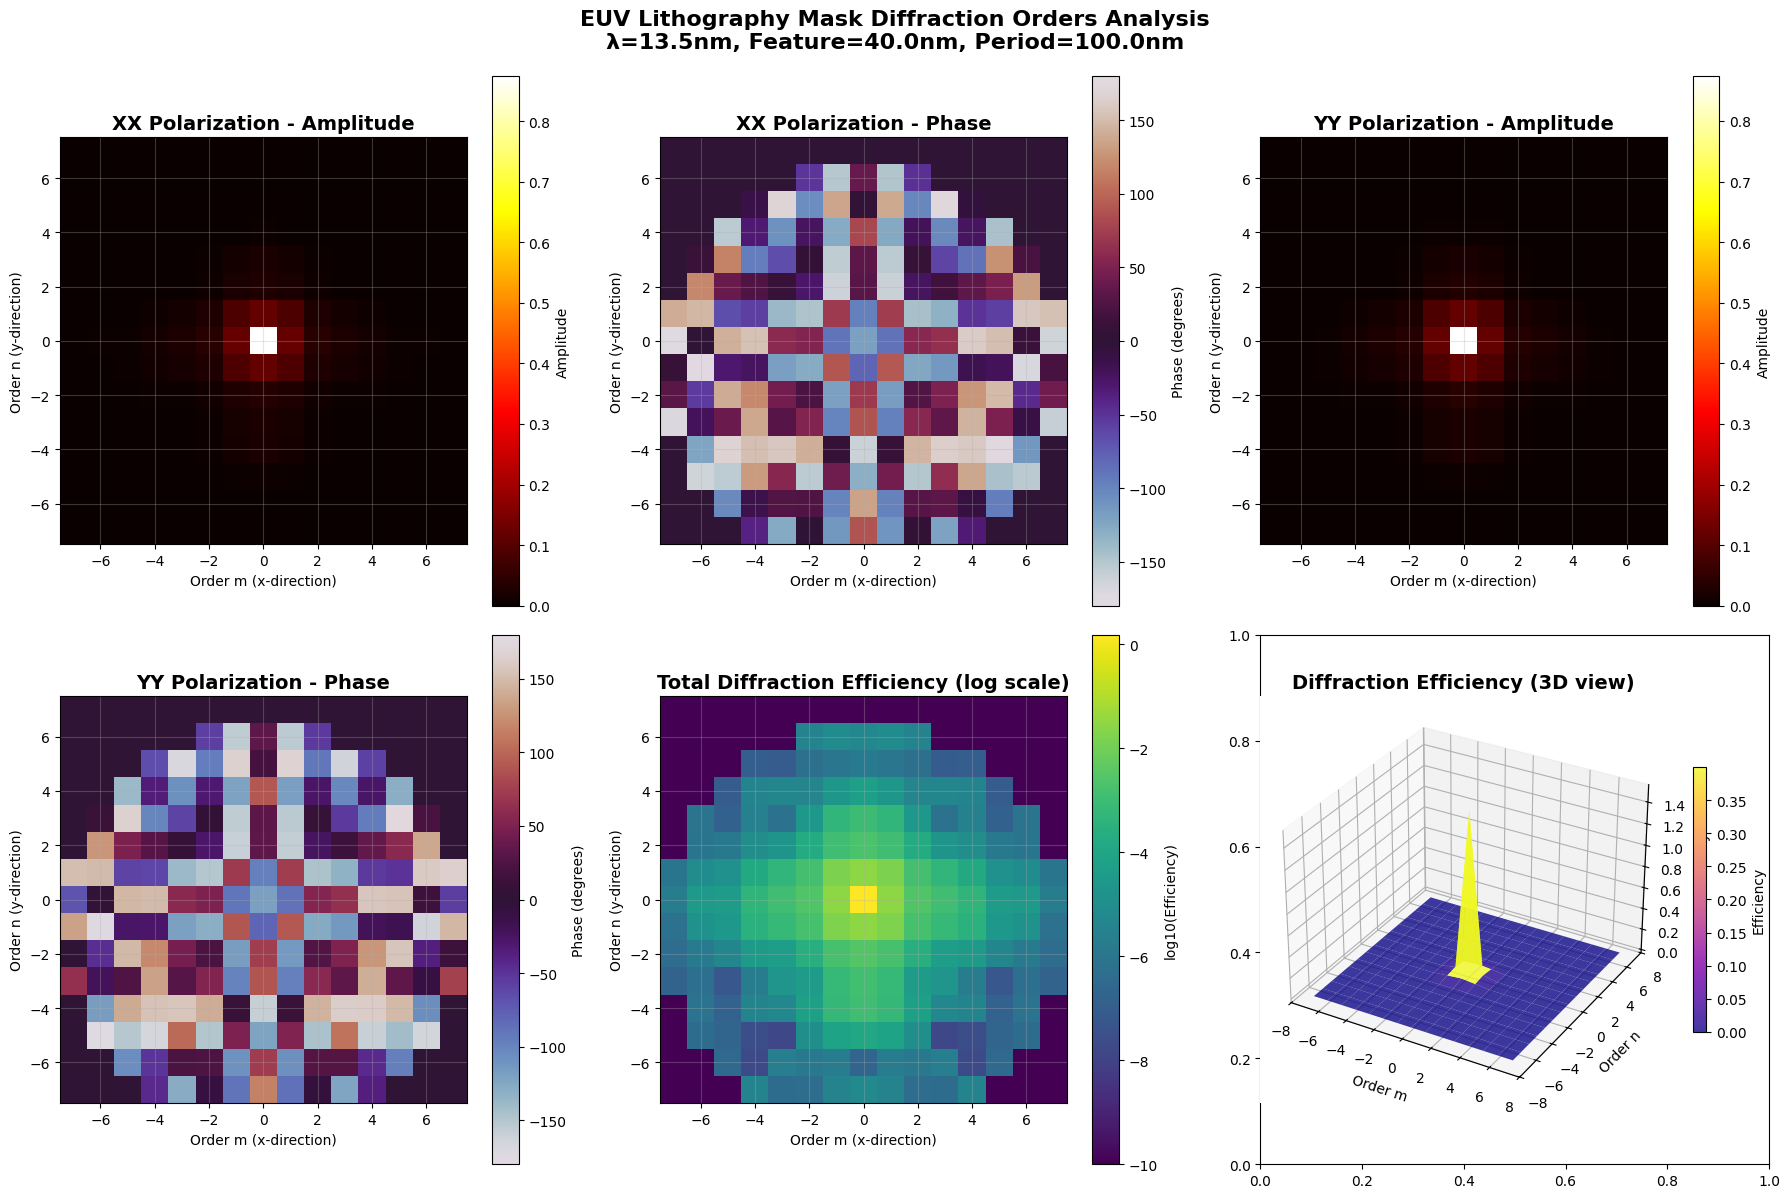


圖表已儲存為 'EUV_diffraction_orders.png'
完成！


In [1]:

# ==================== 匯入必要模組 ====================
import numpy as np
import torch
import matplotlib.pyplot as plt
import torcwa

# ==================== 硬體設定 ====================
# 若有GPU則使用GPU加速，否則使用CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sim_dtype = torch.complex64  # 模擬使用的複數精度
geo_dtype = torch.float32     # 幾何參數使用的浮點精度

print("Python環境檢查：")
print(f"PyTorch版本: {torch.__version__}")
print(f"使用設備: {device}")
print(f"torcwa版本: {torcwa.__version__ if hasattr(torcwa, '__version__') else '未知'}")

# ==================== EUV光源參數設定 ====================
# EUV標準波長為13.5nm
lamb0 = torch.tensor(13.5, dtype=geo_dtype, device=device)  # 波長 (nm)

# 斜入射角度（EUV系統常用6度斜入射）
inc_ang = 6.0 * (np.pi/180)   # 入射角 (轉換為弧度)
azi_ang = 0.0 * (np.pi/180)   # 方位角

# ==================== 材料光學常數設定 (13.5nm) ====================
# 真空/空氣 (入射層)
air_eps = 1.0

# TaN吸收層 (常用EUV光罩吸收材料)
n_TaN = 0.9434      # 折射率實部
k_TaN = 0.0374      # 消光係數
TaN_eps = (n_TaN + 1j*k_TaN)**2  # 介電常數

# SiO2基底
n_SiO2 = 0.9781
k_SiO2 = 0.0108
SiO2_eps = (n_SiO2 + 1j*k_SiO2)**2

# ==================== 光罩幾何結構設定 ====================
# 週期性單元尺寸
L = [100.0, 100.0]  # [Lx, Ly] 單位: nm

# 設置torcwa的幾何模組參數
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 200  # x方向網格點數
torcwa.rcwa_geo.ny = 200  # y方向網格點數
torcwa.rcwa_geo.grid()    # 生成網格
torcwa.rcwa_geo.edge_sharpness = 1000.0  # 邊緣銳利度

# 定義光罩圖形：中心的方形吸收體
feature_width = 40.0  # 特徵寬度 40nm
layer_geometry = torcwa.rcwa_geo.square(
    W=feature_width, 
    Cx=L[0]/2.0,      # 中心x座標
    Cy=L[1]/2.0       # 中心y座標
)

# 計算該層的介電常數分布
# 吸收體區域使用TaN，其餘為空氣
layer_eps = layer_geometry * TaN_eps + (1.0 - layer_geometry) * air_eps
layer_thickness = 50.0  # TaN吸收層厚度 (nm)

# ==================== 建立RCWA模擬 ====================
# 設定繞射階數範圍：[-N, +N]
order_N = 7  # 計算 -7 到 +7 階
order = [order_N, order_N]

# 創建RCWA模擬物件
sim = torcwa.rcwa(
    freq=1/lamb0,           # 頻率 = 1/波長
    order=order,            # 繞射階數範圍
    L=L,                    # 週期
    dtype=sim_dtype,
    device=device
)

# 添加入射層（基底，假設為空氣）
sim.add_input_layer(eps=air_eps)

# 設置入射角度
sim.set_incident_angle(inc_ang=inc_ang, azi_ang=azi_ang)

# 添加TaN吸收層
sim.add_layer(thickness=layer_thickness, eps=layer_eps)

# 求解全局S矩陣（散射矩陣）
sim.solve_global_smatrix()

print(f"模擬設置完成: EUV波長={lamb0.item()}nm, 階數範圍=±{order_N}")

# ==================== 提取所有繞射階的振幅與相位 ====================
# 創建階數索引陣列
orders_range = range(-order_N, order_N+1)
num_orders = len(orders_range)

# 初始化儲存陣列
amplitude_xx = np.zeros((num_orders, num_orders))  # xx極化振幅
phase_xx = np.zeros((num_orders, num_orders))      # xx極化相位
amplitude_yy = np.zeros((num_orders, num_orders))  # yy極化振幅
phase_yy = np.zeros((num_orders, num_orders))      # yy極化相位
efficiency = np.zeros((num_orders, num_orders))    # 繞射效率

# 遍歷所有繞射階，提取S參數
for i, m in enumerate(orders_range):
    for j, n in enumerate(orders_range):
        # 取得(m,n)階的透射S參數 - xx極化
        s_xx = sim.S_parameters(
            orders=[m, n],
            direction='forward',     # 透射方向
            port='transmission',     # 透射埠
            polarization='xx',       # xx極化分量
            ref_order=[0, 0]         # 參考零階
        )
        
        # 取得(m,n)階的透射S參數 - yy極化
        s_yy = sim.S_parameters(
            orders=[m, n],
            direction='forward',
            port='transmission',
            polarization='yy',
            ref_order=[0, 0]
        )
        
        # 提取振幅（模長）
        amplitude_xx[i, j] = torch.abs(s_xx).cpu().numpy()
        amplitude_yy[i, j] = torch.abs(s_yy).cpu().numpy()
        
        # 提取相位（弧度）
        phase_xx[i, j] = torch.angle(s_xx).cpu().numpy()
        phase_yy[i, j] = torch.angle(s_yy).cpu().numpy()
        
        # 計算繞射效率（功率 = |振幅|²）
        efficiency[i, j] = (amplitude_xx[i, j]**2 + amplitude_yy[i, j]**2)

# 轉換相位為角度
phase_xx_deg = np.degrees(phase_xx)
phase_yy_deg = np.degrees(phase_yy)

print(f"已計算 {num_orders}×{num_orders} = {num_orders**2} 個繞射階")
print(f"零階(0,0)效率: {efficiency[order_N, order_N]:.4f}")

# ==================== 視覺化繞射階振幅與相位分布 ====================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 創建階數標籤（用於座標軸）
extent = [orders_range[0]-0.5, orders_range[-1]+0.5, 
          orders_range[0]-0.5, orders_range[-1]+0.5]

# (1) XX極化 - 振幅分布
im1 = axes[0, 0].imshow(amplitude_xx, cmap='hot', origin='lower', 
                         extent=extent, interpolation='nearest')
axes[0, 0].set_title('XX Polarization - Amplitude', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Order m (x-direction)')
axes[0, 0].set_ylabel('Order n (y-direction)')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(im1, ax=axes[0, 0], label='Amplitude')

# (2) XX極化 - 相位分布
im2 = axes[0, 1].imshow(phase_xx_deg, cmap='twilight', origin='lower',
                         extent=extent, interpolation='nearest', 
                         vmin=-180, vmax=180)
axes[0, 1].set_title('XX Polarization - Phase', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Order m (x-direction)')
axes[0, 1].set_ylabel('Order n (y-direction)')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(im2, ax=axes[0, 1], label='Phase (degrees)')

# (3) YY極化 - 振幅分布
im3 = axes[0, 2].imshow(amplitude_yy, cmap='hot', origin='lower',
                         extent=extent, interpolation='nearest')
axes[0, 2].set_title('YY Polarization - Amplitude', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Order m (x-direction)')
axes[0, 2].set_ylabel('Order n (y-direction)')
axes[0, 2].grid(True, alpha=0.3)
plt.colorbar(im3, ax=axes[0, 2], label='Amplitude')

# (4) YY極化 - 相位分布
im4 = axes[1, 0].imshow(phase_yy_deg, cmap='twilight', origin='lower',
                         extent=extent, interpolation='nearest',
                         vmin=-180, vmax=180)
axes[1, 0].set_title('YY Polarization - Phase', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Order m (x-direction)')
axes[1, 0].set_ylabel('Order n (y-direction)')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(im4, ax=axes[1, 0], label='Phase (degrees)')

# (5) 總繞射效率分布（對數刻度）
im5 = axes[1, 1].imshow(np.log10(efficiency + 1e-10), cmap='viridis', 
                         origin='lower', extent=extent, interpolation='nearest')
axes[1, 1].set_title('Total Diffraction Efficiency (log scale)', 
                     fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Order m (x-direction)')
axes[1, 1].set_ylabel('Order n (y-direction)')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(im5, ax=axes[1, 1], label='log10(Efficiency)')

# (6) 3D視圖 - 繞射效率
ax_3d = fig.add_subplot(2, 3, 6, projection='3d')
X, Y = np.meshgrid(range(num_orders), range(num_orders))
surf = ax_3d.plot_surface(X-order_N, Y-order_N, efficiency, 
                          cmap='plasma', alpha=0.8)
ax_3d.set_title('Diffraction Efficiency (3D view)', fontsize=14, fontweight='bold')
ax_3d.set_xlabel('Order m')
ax_3d.set_ylabel('Order n')
ax_3d.set_zlabel('Efficiency')
plt.colorbar(surf, ax=ax_3d, shrink=0.5, label='Efficiency')

plt.suptitle(f'EUV Lithography Mask Diffraction Orders Analysis\n' + 
             f'λ={lamb0.item()}nm, Feature={feature_width}nm, Period={L[0]}nm',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('EUV_diffraction_orders.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n圖表已儲存為 'EUV_diffraction_orders.png'")
print("完成！")


使用裝置: cpu

DUV波長: 193.0 nm
入射角度: 0.0° (垂直入射)
鉻 (Cr) 光學常數: n=0.842, k=1.647
二氧化矽 (SiO2) 光學常數: n=1.563, k=0.000

=== 結構設定 ===
Unit cell 尺寸: 200.0 nm × 200.0 nm
 鉻層厚度: 70.0 nm (左半側: Cr, 右半側: 空氣)
 輸出層: 空氣


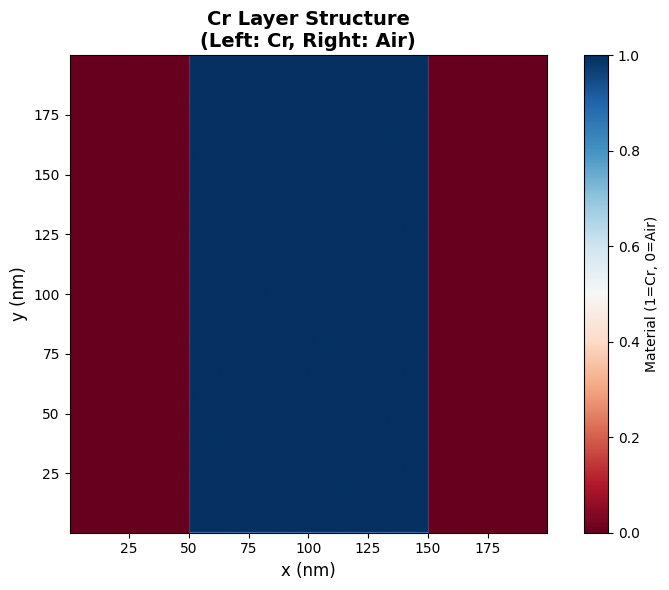


模擬設置完成
繞射階數範圍: -3 到 +3

開始提取 7 個一維繞射階 (m, n=0) 的資料...
階數 m=-3: |Sxx|=0.0000, ∠Sxx=  +0.00°, |Syy|=0.0000, ∠Syy=  +0.00°, η=0.0000
階數 m=-2: |Sxx|=0.0000, ∠Sxx=  +0.00°, |Syy|=0.0000, ∠Syy=  +0.00°, η=0.0000
階數 m=-1: |Sxx|=0.1967, ∠Sxx=+137.81°, |Syy|=0.1960, ∠Syy= +76.43°, η=0.0771
階數 m=+0: |Sxx|=0.3940, ∠Sxx=+121.49°, |Syy|=0.5437, ∠Syy=+101.15°, η=0.4509
階數 m=+1: |Sxx|=0.1967, ∠Sxx=+138.26°, |Syy|=0.1960, ∠Syy= +76.88°, η=0.0771
階數 m=+2: |Sxx|=0.0000, ∠Sxx=  +0.00°, |Syy|=0.0000, ∠Syy=  +0.00°, η=0.0000
階數 m=+3: |Sxx|=0.0000, ∠Sxx=  +0.00°, |Syy|=0.0000, ∠Syy=  +0.00°, η=0.0000


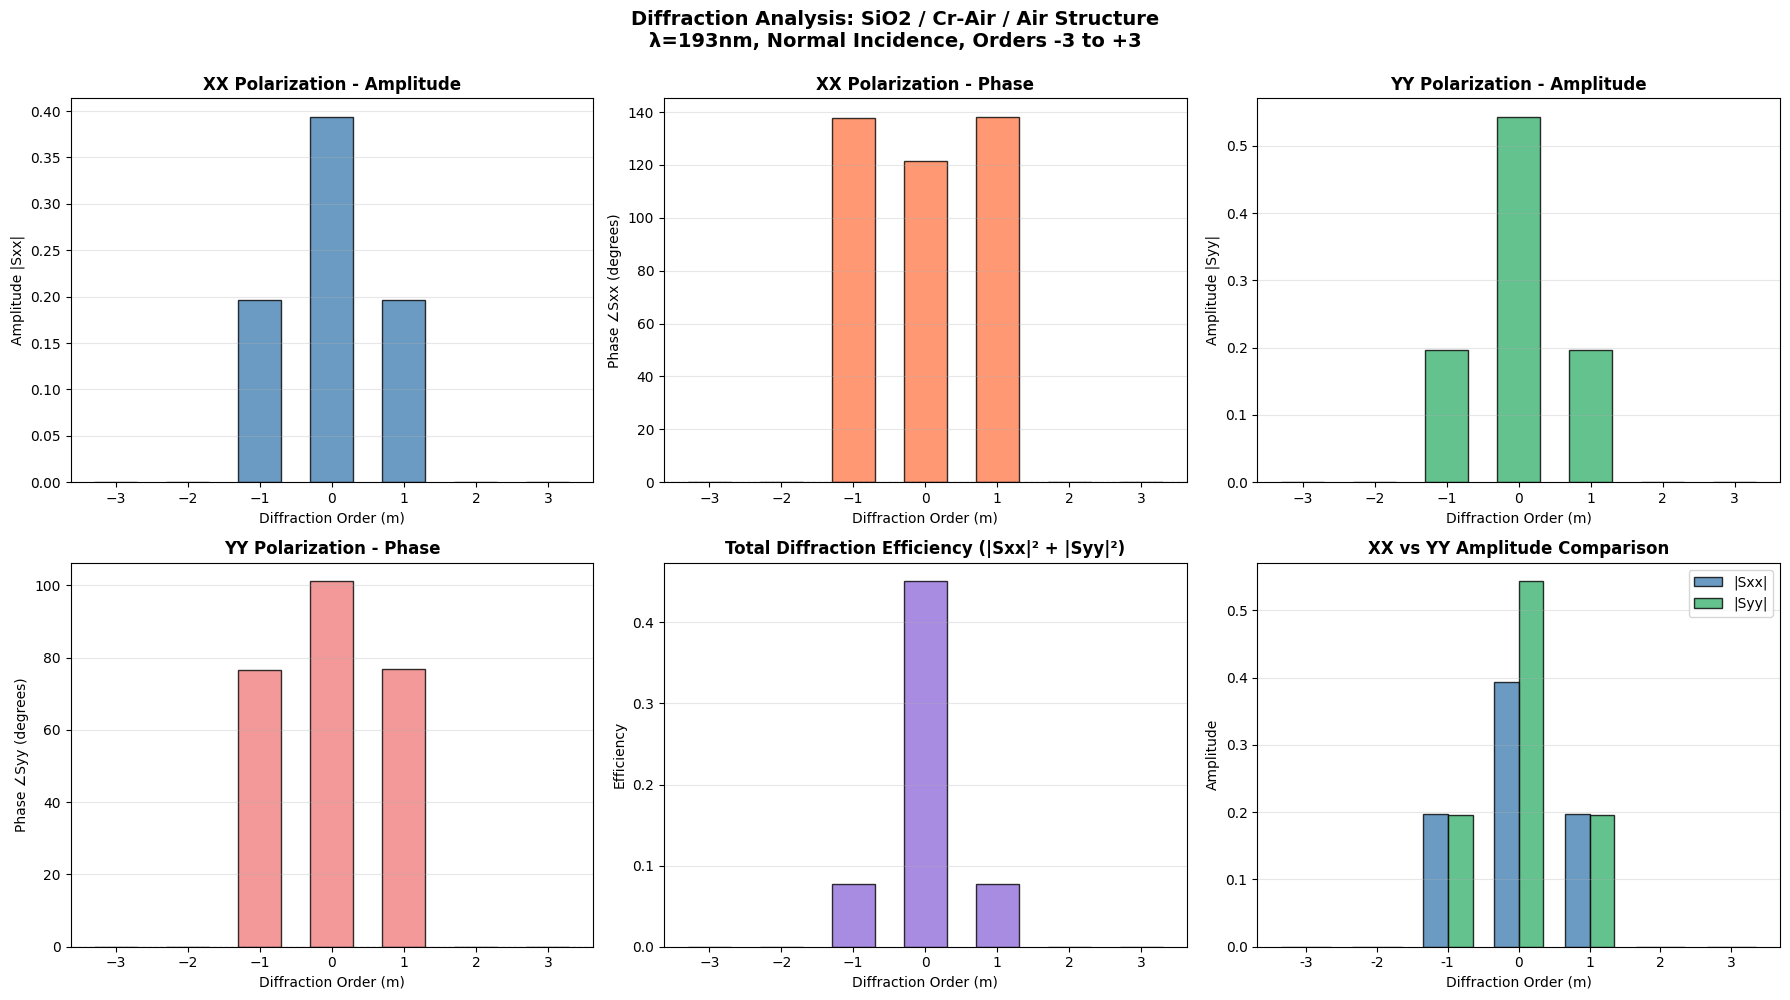


繞射階數據摘要 (Diffraction Orders Summary)
   階數    |    XX振幅    |    XX相位(°)     |    YY振幅    |    YY相位(°)     |     效率    
------------------------------------------------------------------------------------------
   -3    |   0.0000   |      0.00      |   0.0000   |      0.00      |   0.0000  
   -2    |   0.0000   |      0.00      |   0.0000   |      0.00      |   0.0000  
   -1    |   0.1967   |     137.81     |   0.1960   |     76.43      |   0.0771  
   0     |   0.3940   |     121.49     |   0.5437   |     101.15     |   0.4509  
   1     |   0.1967   |     138.26     |   0.1960   |     76.88      |   0.0771  
   2     |   0.0000   |      0.00      |   0.0000   |      0.00      |   0.0000  
   3     |   0.0000   |      0.00      |   0.0000   |      0.00      |   0.0000  

總效率 (能量守恆檢查): 0.6051
零階效率佔比: 74.51%

模擬完成！


In [13]:
'''
DUV光學微影系統模擬 - 實際光罩結構
波長: 193nm, 垂直入射, 分析-3到+3階繞射
結構: SiO2基板 / Cr-空氣半半層 / 空氣
'''

# ==================== 匯入必要模組 ====================
import numpy as np
import torch
import matplotlib.pyplot as plt
import torcwa

# ==================== 硬體設定 ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sim_dtype = torch.complex64
geo_dtype = torch.float32

print(f"使用裝置: {device}")

# ==================== 光源參數設定 (DUV) ====================
lamb0 = torch.tensor(193.0, dtype=geo_dtype, device=device)  # 波長 193nm (DUV)

# 垂直入射 (入射角 = 0度)
inc_ang = 0.0 * (np.pi/180)   # 入射角 0度
azi_ang = 0.0 * (np.pi/180)   # 方位角 0度

# ==================== 材料光學常數設定 (193nm) ====================
# 空氣/真空
air_eps = 1.0

# 鉻 (Chromium) @ 193nm
n_Cr = 0.842
k_Cr = 1.647
Cr_eps = (n_Cr + 1j*k_Cr)**2

# 二氧化矽 (SiO2) @ 193nm
n_SiO2 = 1.563
k_SiO2 = 0.0
SiO2_eps = (n_SiO2 + 1j*k_SiO2)**2

print(f"\nDUV波長: {lamb0.item()} nm")
print(f"入射角度: {inc_ang*180/np.pi:.1f}° (垂直入射)")
print(f"鉻 (Cr) 光學常數: n={n_Cr:.3f}, k={k_Cr:.3f}")
print(f"二氧化矽 (SiO2) 光學常數: n={n_SiO2:.3f}, k={k_SiO2:.3f}")

# ==================== 光罩幾何結構設定 ====================
# Unit cell 寬度 400nm × 400nm
L = [200.0, 200.0]  # [Lx, Ly] 單位: nm

# 設置torcwa的幾何模組參數
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800  # x方向網格點數
torcwa.rcwa_geo.ny = 800  # y方向網格點數
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.0

# 定義鉻層圖形 (寬200nm × 高400nm)
left_rectangle = torcwa.rcwa_geo.rectangle(
    Wx=L[0]/2,           # 寬度 200nm
    Wy=L[1],             # 高度 400nm
    Cx=L[0]/2,          # 中心位置在 200nm (中心)
    Cy=L[1]/2           # y方向中心在 200nm
)

# 鉻層的介電常數分布
# 左半側矩形(left_rectangle=1)使用Cr，右半側使用空氣
Cr_layer_eps = left_rectangle * Cr_eps + (1.0 - left_rectangle) * air_eps
Cr_layer_thickness = 70.0  # 鉻層厚度 70nm

print(f"\n=== 結構設定 ===")
print(f"Unit cell 尺寸: {L[0]} nm × {L[1]} nm")
print(f" 鉻層厚度: {Cr_layer_thickness} nm (左半側: Cr, 右半側: 空氣)")
print(f" 輸出層: 空氣")

# ==================== 視覺化結構 ====================
# ==================== 視覺化結構 ====================
x_axis = torcwa.rcwa_geo.x.cpu().numpy()
y_axis = torcwa.rcwa_geo.y.cpu().numpy()

plt.figure(figsize=(8, 6))
im = plt.imshow(torch.transpose(left_rectangle, -2, -1).cpu().numpy(), 
                cmap='RdBu', origin='lower',
                extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]])
plt.title('Cr Layer Structure\n(Left: Cr, Right: Air)', fontsize=14, fontweight='bold')
plt.xlabel('x (nm)', fontsize=12)
plt.ylabel('y (nm)', fontsize=12)
plt.colorbar(im, label='Material (1=Cr, 0=Air)')
plt.tight_layout()
plt.show()


# ==================== 建立RCWA模擬 ====================
# 設定繞射階數範圍：-3 到 +3
order_N = 3
order = [order_N, order_N]

# 創建RCWA模擬物件
sim = torcwa.rcwa(
    freq=1/lamb0,
    order=order,
    L=L,
    dtype=sim_dtype,
    device=device
)

# 添加入射層（SiO2基板）
sim.add_input_layer(eps=SiO2_eps,mu=1.)

# 設置入射角度（垂直入射）
sim.set_incident_angle(inc_ang=inc_ang, azi_ang=azi_ang)

# 添加 Cr/空氣混合層
sim.add_layer(thickness=Cr_layer_thickness, eps=Cr_layer_eps)

# 求解全局S矩陣
sim.solve_global_smatrix()

print(f"\n模擬設置完成")
print(f"繞射階數範圍: -{order_N} 到 +{order_N}")

# ==================== 提取繞射階的振幅與相位 ====================
orders_range = range(-order_N, order_N+1)  # -3 to +3
num_orders = len(orders_range)

# 儲存結果的字典
results = {}

print(f"\n開始提取 {num_orders} 個一維繞射階 (m, n=0) 的資料...")

for m in orders_range:
    # 只考慮 n=0 的一維繞射 (因為結構在y方向均勻)
    n = 0
    
    # 取得xx極化
    s_xx = sim.S_parameters(
        orders=[m, n],
        direction='forward',
        port='transmission',
        polarization='xx',
        ref_order=[0, 0]
    )
    
    # 取得yy極化
    s_yy = sim.S_parameters(
        orders=[m, n],
        direction='forward',
        port='transmission',
        polarization='yy',
        ref_order=[0, 0]
    )
    
    # 提取振幅和相位
    amp_xx = torch.abs(s_xx).cpu().item()
    phase_xx = torch.angle(s_xx).cpu().item()
    amp_yy = torch.abs(s_yy).cpu().item()
    phase_yy = torch.angle(s_yy).cpu().item()
    
    # 計算總效率
    efficiency = amp_xx**2 + amp_yy**2
    
    results[m] = {
        'amp_xx': amp_xx,
        'phase_xx': phase_xx,
        'amp_yy': amp_yy,
        'phase_yy': phase_yy,
        'efficiency': efficiency
    }
    
    print(f"階數 m={m:+2d}: |Sxx|={amp_xx:.4f}, ∠Sxx={np.degrees(phase_xx):+7.2f}°, "
          f"|Syy|={amp_yy:.4f}, ∠Syy={np.degrees(phase_yy):+7.2f}°, η={efficiency:.4f}")

# ==================== 視覺化結果：長條圖 ====================
orders_list = list(orders_range)
amp_xx_list = [results[m]['amp_xx'] for m in orders_list]
amp_yy_list = [results[m]['amp_yy'] for m in orders_list]
phase_xx_list = [np.degrees(results[m]['phase_xx']) for m in orders_list]
phase_yy_list = [np.degrees(results[m]['phase_yy']) for m in orders_list]
efficiency_list = [results[m]['efficiency'] for m in orders_list]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) XX極化振幅
axes[0, 0].bar(orders_list, amp_xx_list, color='steelblue', alpha=0.8, edgecolor='black', width=0.6)
axes[0, 0].set_title('XX Polarization - Amplitude', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Diffraction Order (m)')
axes[0, 0].set_ylabel('Amplitude |Sxx|')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_xticks(orders_list)

# (2) XX極化相位
axes[0, 1].bar(orders_list, phase_xx_list, color='coral', alpha=0.8, edgecolor='black', width=0.6)
axes[0, 1].set_title('XX Polarization - Phase', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Diffraction Order (m)')
axes[0, 1].set_ylabel('Phase ∠Sxx (degrees)')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_xticks(orders_list)
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)

# (3) YY極化振幅
axes[0, 2].bar(orders_list, amp_yy_list, color='mediumseagreen', alpha=0.8, edgecolor='black', width=0.6)
axes[0, 2].set_title('YY Polarization - Amplitude', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Diffraction Order (m)')
axes[0, 2].set_ylabel('Amplitude |Syy|')
axes[0, 2].grid(axis='y', alpha=0.3)
axes[0, 2].set_xticks(orders_list)

# (4) YY極化相位
axes[1, 0].bar(orders_list, phase_yy_list, color='lightcoral', alpha=0.8, edgecolor='black', width=0.6)
axes[1, 0].set_title('YY Polarization - Phase', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Diffraction Order (m)')
axes[1, 0].set_ylabel('Phase ∠Syy (degrees)')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_xticks(orders_list)
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)

# (5) 繞射效率
axes[1, 1].bar(orders_list, efficiency_list, color='mediumpurple', alpha=0.8, edgecolor='black', width=0.6)
axes[1, 1].set_title('Total Diffraction Efficiency (|Sxx|² + |Syy|²)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Diffraction Order (m)')
axes[1, 1].set_ylabel('Efficiency')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_xticks(orders_list)

# (6) XX 與 YY 振幅對比
x_pos = np.arange(len(orders_list))
width = 0.35
axes[1, 2].bar(x_pos - width/2, amp_xx_list, width, label='|Sxx|', color='steelblue', alpha=0.8, edgecolor='black')
axes[1, 2].bar(x_pos + width/2, amp_yy_list, width, label='|Syy|', color='mediumseagreen', alpha=0.8, edgecolor='black')
axes[1, 2].set_title('XX vs YY Amplitude Comparison', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Diffraction Order (m)')
axes[1, 2].set_ylabel('Amplitude')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(orders_list)
axes[1, 2].legend()
axes[1, 2].grid(axis='y', alpha=0.3)

plt.suptitle(f'Diffraction Analysis: SiO2 / Cr-Air / Air Structure\n' + 
             f'λ={lamb0.item():.0f}nm, Normal Incidence, Orders -3 to +3',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ==================== 數據摘要 ====================
print("\n" + "="*90)
print("繞射階數據摘要 (Diffraction Orders Summary)")
print("="*90)
print(f"{'階數':^8} | {'XX振幅':^10} | {'XX相位(°)':^14} | {'YY振幅':^10} | {'YY相位(°)':^14} | {'效率':^10}")
print("-"*90)
for m in orders_list:
    print(f"{m:^8d} | {results[m]['amp_xx']:^10.4f} | "
          f"{np.degrees(results[m]['phase_xx']):^14.2f} | "
          f"{results[m]['amp_yy']:^10.4f} | "
          f"{np.degrees(results[m]['phase_yy']):^14.2f} | "
          f"{results[m]['efficiency']:^10.4f}")
print("="*90)

# 能量守恆檢查
total_efficiency = sum(efficiency_list)
print(f"\n總效率 (能量守恆檢查): {total_efficiency:.4f}")
if results[0]['efficiency'] > 0:
    print(f"零階效率佔比: {results[0]['efficiency']/total_efficiency*100:.2f}%")

print("\n模擬完成！")


In [22]:
order_N = 3
orders_range = range(-order_N, order_N+1)

s_params_xx = {}
s_params_yy = {}

for m in orders_range:
    n = 0  # 僅考慮 y方向均勻，故 n=0
    s_xx = sim.S_parameters(
        orders=[m, n],
        direction='forward',
        port='transmission',
        polarization='xx',
        ref_order=[0, 0]
    )
    s_yy = sim.S_parameters(
        orders=[m, n],
        direction='forward',
        port='transmission',
        polarization='yy',
        ref_order=[0, 0]
    )
    s_params_xx[m] = s_xx.cpu().numpy()
    s_params_yy[m] = s_yy.cpu().numpy()

for m in orders_range:
    print(f"m={m}: Sxx = {s_params_xx[m]}, Syy = {s_params_yy[m]}")


m=-3: Sxx = [0.+0.j], Syy = [0.+0.j]
m=-2: Sxx = [-0.02033207+0.05412251j], Syy = [-0.0236113+0.06084589j]
m=-1: Sxx = [-0.16216959+0.2239165j], Syy = [-0.15875286+0.26644355j]
m=0: Sxx = [-0.24810643+0.3533169j], Syy = [-0.24670409+0.39599937j]
m=1: Sxx = [-0.16392313+0.2226358j], Syy = [-0.16084044+0.2651883j]
m=2: Sxx = [-0.02117986+0.05379625j], Syy = [-0.02456417+0.06046744j]
m=3: Sxx = [0.+0.j], Syy = [0.+0.j]


In [12]:
import numpy as np

lamb = 13.5
d = 200
n_out = 1.0  # 假設輸出是空氣

print("=== 繞射階物理可行性分析 ===\n")
for m in range(-3, 4):
    # 計算出射角（假設垂直入射）
    sin_theta = m * lamb / d
    
    print(f"階數 m = {m:+2d}:")
    print(f"  sin(θ) = {sin_theta:+.4f}", end="")
    
    if abs(sin_theta) > 1.0:
        # 衰減波：計算衰減係數
        kappa = np.sqrt(sin_theta**2 - 1)
        print(f" → 衰減波 (κ={kappa:.4f})")
    else:
        theta = np.degrees(np.arcsin(sin_theta))
        print(f" → 傳播波 (θ={theta:.1f}°)")
    print()


=== 繞射階物理可行性分析 ===

階數 m = -3:
  sin(θ) = -0.2025 → 傳播波 (θ=-11.7°)

階數 m = -2:
  sin(θ) = -0.1350 → 傳播波 (θ=-7.8°)

階數 m = -1:
  sin(θ) = -0.0675 → 傳播波 (θ=-3.9°)

階數 m = +0:
  sin(θ) = +0.0000 → 傳播波 (θ=0.0°)

階數 m = +1:
  sin(θ) = +0.0675 → 傳播波 (θ=3.9°)

階數 m = +2:
  sin(θ) = +0.1350 → 傳播波 (θ=7.8°)

階數 m = +3:
  sin(θ) = +0.2025 → 傳播波 (θ=11.7°)



In [32]:
# 檢查內部變數
print("=== 層設定檢查 ===")
print(f"入射層 eps_in: {sim.eps_in}")
print(f"入射層 mu_in: {sim.mu_in}")

# 檢查輸出層
if hasattr(sim, 'eps_out'):
    print(f"輸出層 eps_out: {sim.eps_out}")
    print(f"輸出層 mu_out: {sim.mu_out}")
else:
    print("輸出層：未明確定義，使用預設自由空間 (eps=1.0, mu=1.0)")


=== 層設定檢查 ===
入射層 eps_in: (2.4429690837860107+0j)
入射層 mu_in: (1+0j)
輸出層 eps_out: (1+0j)
輸出層 mu_out: (1+0j)


In [37]:
import numpy as np

# 測試不同厚度空氣層對相位的影響

results_by_thickness = {}

for air_thickness in [0, 100, 1000, 10000]:
    # 創建新的 sim 物件（避免重複添加層）
    order_N = 3
    order = [order_N, order_N]
    
    sim_test = torcwa.rcwa(
        freq=1/lamb0,
        order=order,
        L=L,
        dtype=sim_dtype,
        device=device
    )
    
    # 添加層
    sim_test.add_input_layer(eps=SiO2_eps)
    sim_test.set_incident_angle(inc_ang=inc_ang, azi_ang=azi_ang)
    sim_test.add_layer(thickness=Cr_layer_thickness, eps=Cr_layer_eps)
    
    # 如果空氣厚度 > 0，添加厚空氣層
    if air_thickness > 0:
        sim_test.add_layer(thickness=air_thickness, eps=1.0)
    
    sim_test.solve_global_smatrix()
    
    # 提取各階相位
    phases = {}
    orders_range = range(-order_N, order_N+1)
    
    for m in orders_range:
        n = 0
        s_xx = sim_test.S_parameters(
            orders=[m, n],
            direction='forward',
            port='transmission',
            polarization='xx',
            ref_order=[0, 0]
        )
        # ✅ 修正：用 .item() 轉換 numpy 陣列為純量
        phases[m] = np.angle(s_xx.cpu().numpy()).item()
    
    results_by_thickness[air_thickness] = phases
    
    print(f"\n=== 空氣厚度: {air_thickness} nm ===")
    for m in orders_range:
        # ✅ 修正：phases[m] 現在是純量
        print(f"m={m:+2d}: 相位 = {np.degrees(phases[m]):+7.2f}°")

# 分析相位差
print("\n" + "="*60)
print("=== 相位差異分析 ===")
print("="*60)

phases_0 = results_by_thickness[0]  # 無厚空氣層的基準

for air_thickness in [100, 1000, 10000]:
    phases_t = results_by_thickness[air_thickness]
    
    print(f"\n【空氣厚度 {air_thickness} nm 相比無厚空氣層的相位變化】")
    print(f"{'階數':^8} | {'相位差(°)':^15} | {'相位差(圓周)':^15}")
    print("-" * 45)
    
    phase_diffs = {}
    for m in orders_range:
        delta_phase_rad = phases_t[m] - phases_0[m]
        delta_phase_deg = np.degrees(delta_phase_rad)
        delta_phase_cycles = delta_phase_rad / (2*np.pi)
        
        phase_diffs[m] = delta_phase_rad
        
        print(f"{m:+8d} | {delta_phase_deg:+14.2f} | {delta_phase_cycles:+14.4f}")
    
    # 檢查梯度：相位差是否線性增加？
    print(f"\n【相位差的階次依賴性】")
    if len(list(orders_range)) > 1:
        # 計算 Δφ 與 m 的關係
        m_values = list(orders_range)
        dp_values = [phase_diffs[m] for m in m_values]
        
        # 簡單線性擬合
        coeffs = np.polyfit(m_values, dp_values, 1)
        slope = coeffs[0]
        intercept = coeffs[1]
        
        print(f"擬合: Δφ ≈ {slope:.6f} × m + {intercept:.6f}")
        print(f"斜率 ≈ {slope:.6f} rad/階")
        
        # 根據斜率反推有效厚度
        # slope = k_z * d / m （近似）
        # 對於不同的 m，k_z 不同，但如果線性擬合很好，
        # 可以估計平均效應
        if slope != 0:
            effective_thickness = abs(slope) / (2*np.pi / 193)
            print(f"對應的有效傳播 ≈ {effective_thickness:.1f} nm")

print("\n" + "="*60)
print("結論：如果各階相位差與 m 線性相關，")
print("則驗證了「厚空氣層導致的相位取決於各階的傳播方向」")
print("="*60)



=== 空氣厚度: 0 nm ===
m=-3: 相位 =   +0.00°
m=-2: 相位 = +110.59°
m=-1: 相位 = +125.91°
m=+0: 相位 = +125.08°
m=+1: 相位 = +126.36°
m=+2: 相位 = +111.49°
m=+3: 相位 =   +0.00°

=== 空氣厚度: 100 nm ===
m=-3: 相位 =   +0.00°
m=-2: 相位 = +159.51°
m=-1: 相位 =  -70.71°
m=+0: 相位 =  -48.39°
m=+1: 相位 =  -70.26°
m=+2: 相位 = +160.41°
m=+3: 相位 =   +0.00°

=== 空氣厚度: 1000 nm ===
m=-3: 相位 =   +0.00°
m=-2: 相位 = -120.24°
m=-1: 相位 =  -40.29°
m=+0: 相位 = -169.64°
m=+1: 相位 =  -39.84°
m=+2: 相位 = -119.34°
m=+3: 相位 =   +0.00°

=== 空氣厚度: 10000 nm ===
m=-3: 相位 =   +0.00°
m=-2: 相位 =  -37.70°
m=-1: 相位 =  -96.13°
m=+0: 相位 =  +57.93°
m=+1: 相位 =  -95.68°
m=+2: 相位 =  -36.80°
m=+3: 相位 =   +0.00°

=== 相位差異分析 ===

【空氣厚度 100 nm 相比無厚空氣層的相位變化】
   階數    |     相位差(°)      |     相位差(圓周)    
---------------------------------------------
      -3 |          +0.00 |        +0.0000
      -2 |         +48.92 |        +0.1359
      -1 |        -196.62 |        -0.5462
      +0 |        -173.47 |        -0.4819
      +1 |        -196.62 |        -0.5462
 

使用裝置: cpu

DUV波長: 193.0 nm
入射角度: 0.0° (垂直入射)
鉻 (Cr) 光學常數: n=0.842, k=1.647
二氧化矽 (SiO2) 光學常數: n=1.563, k=0.000

=== 結構設定 ===
Unit cell 尺寸: 400.0 nm × 400.0 nm
 鉻層厚度: 70.0 nm (左半側: Cr, 右半側: 空氣)
 輸出層: 空氣


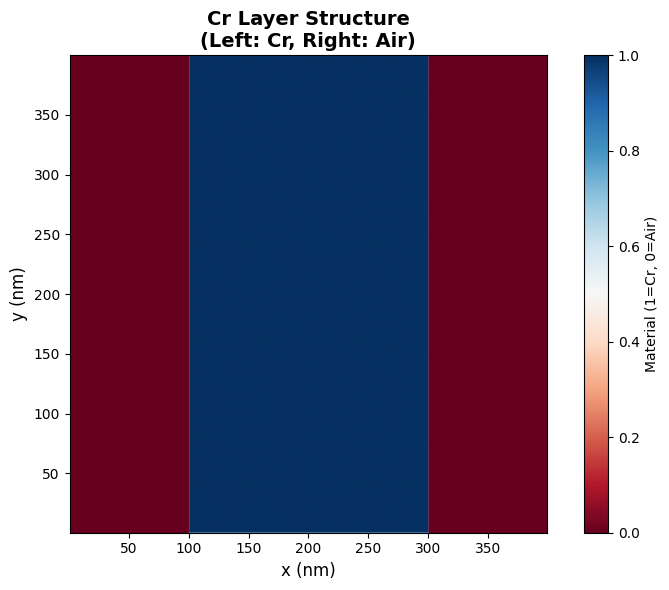


模擬設置完成
繞射階數範圍: -3 到 +3

開始提取 7 個一維繞射階 (m, n=0) 的資料...
階數 m=-3: |Sxx|=0.0000, ∠Sxx=  +0.00°, |Syy|=0.0000, ∠Syy=  +0.00°, η=0.0000
階數 m=-2: |Sxx|=0.0578, ∠Sxx=+110.59°, |Syy|=0.0653, ∠Syy=+111.21°, η=0.0076
階數 m=-1: |Sxx|=0.2765, ∠Sxx=+125.91°, |Syy|=0.3102, ∠Syy=+120.79°, η=0.1726
階數 m=+0: |Sxx|=0.4317, ∠Sxx=+125.08°, |Syy|=0.4666, ∠Syy=+121.92°, η=0.4041
階數 m=+1: |Sxx|=0.2765, ∠Sxx=+126.36°, |Syy|=0.3102, ∠Syy=+121.24°, η=0.1726
階數 m=+2: |Sxx|=0.0578, ∠Sxx=+111.49°, |Syy|=0.0653, ∠Syy=+112.11°, η=0.0076
階數 m=+3: |Sxx|=0.0000, ∠Sxx=  +0.00°, |Syy|=0.0000, ∠Syy=  +0.00°, η=0.0000


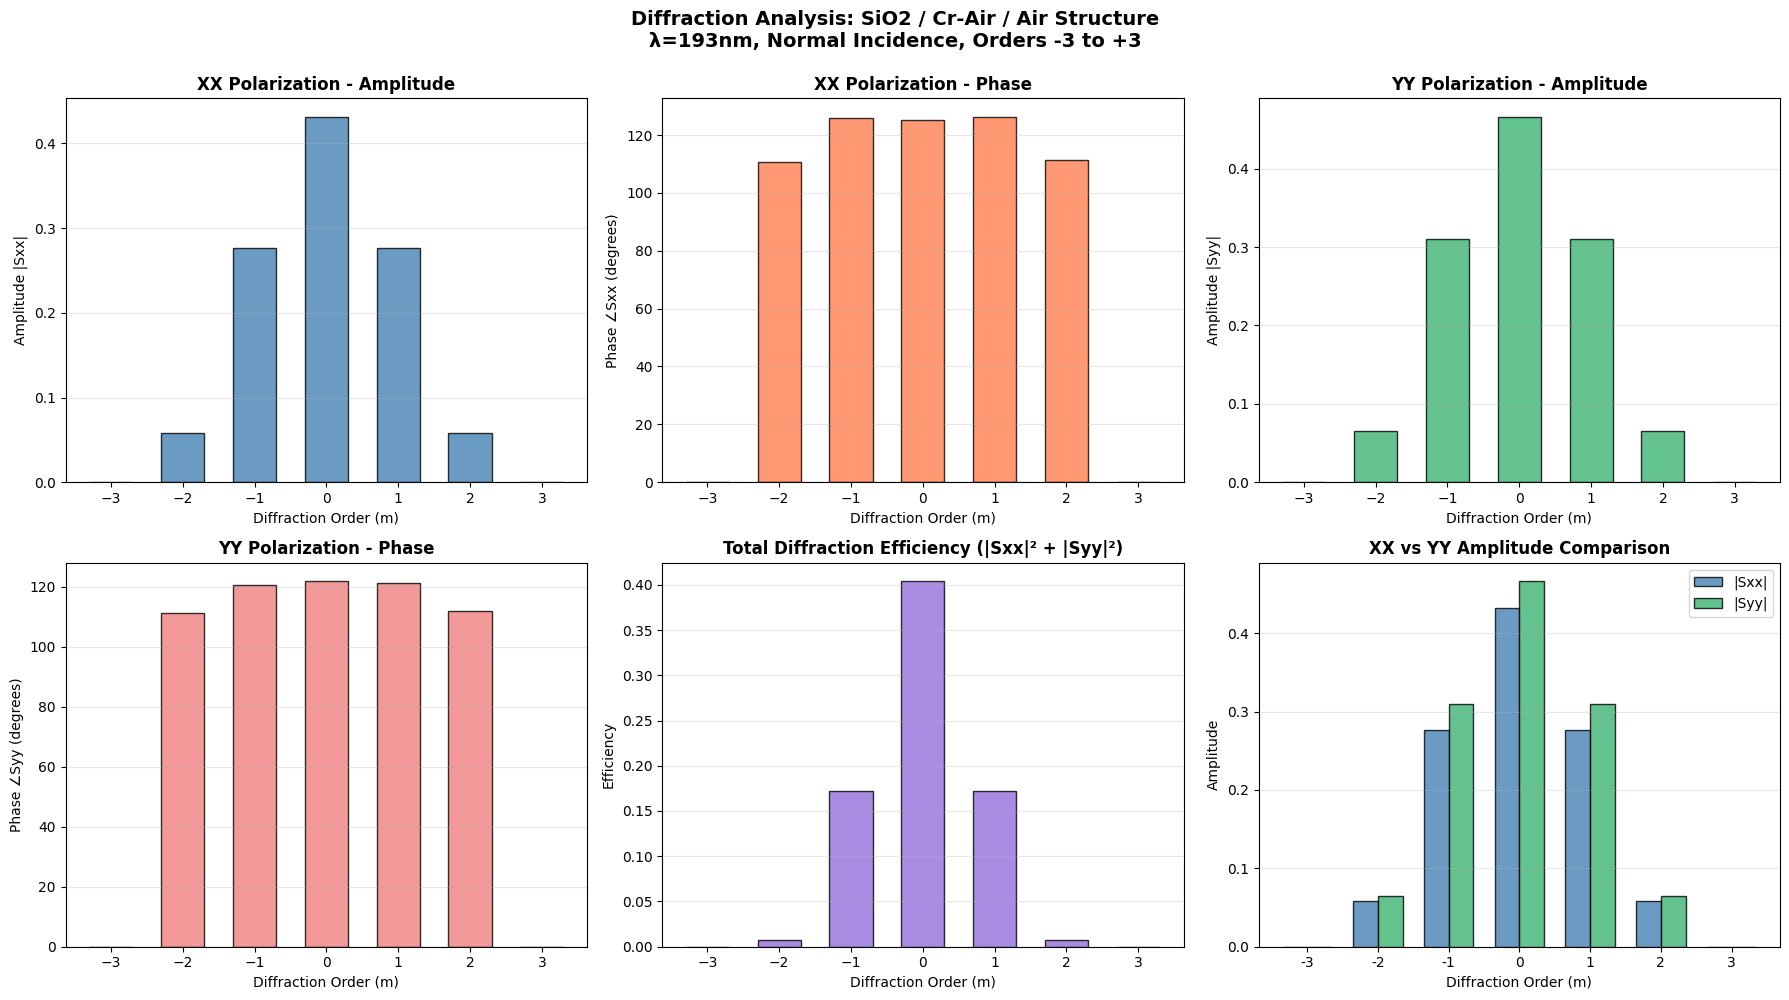


繞射階數據摘要 (Diffraction Orders Summary)
   階數    |    XX振幅    |    XX相位(°)     |    YY振幅    |    YY相位(°)     |     效率    
------------------------------------------------------------------------------------------
   -3    |   0.0000   |      0.00      |   0.0000   |      0.00      |   0.0000  
   -2    |   0.0578   |     110.59     |   0.0653   |     111.21     |   0.0076  
   -1    |   0.2765   |     125.91     |   0.3102   |     120.79     |   0.1726  
   0     |   0.4317   |     125.08     |   0.4666   |     121.92     |   0.4041  
   1     |   0.2765   |     126.36     |   0.3102   |     121.24     |   0.1726  
   2     |   0.0578   |     111.49     |   0.0653   |     112.11     |   0.0076  
   3     |   0.0000   |      0.00      |   0.0000   |      0.00      |   0.0000  

總效率 (能量守恆檢查): 0.7645
零階效率佔比: 52.85%

模擬完成！
True
<class 'method'>


In [3]:

import types
import torch
import numpy as np
import warnings
import torcwa  

def S_parameters_with_evanescent(self, orders, *, 
                                   direction='forward', 
                                   port='transmission', 
                                   polarization='xx', 
                                   ref_order=[0,0], 
                                   power_norm=False,
                                   return_evanescent_info=False):
    '''
    Return S-parameters including evanescent waves (not set to zero).
    
    與原始 S_parameters() 的主要差異：
    1. 衰減波不會被設為零
    2. power_norm 預設為 False（避免除以零的問題）
    3. 可選擇返回衰減波的判定資訊
    
    Parameters
    - orders: selected orders (Recommended shape: Nx2)
    - direction: 'f'/'forward' or 'b'/'backward'
    - port: 't'/'transmission' or 'r'/'reflection'
    - polarization: 'xx'/'yx'/'xy'/'yy' or 'pp'/'sp'/'ps'/'ss'
    - ref_order: reference order (Recommended shape: Nx2)
    - power_norm: if True, apply power normalization (WARNING: may cause issues for evanescent waves)
    - return_evanescent_info: if True, return (S, is_evanescent_mask) tuple
    
    Return
    - S-parameters (torch.Tensor) - 包含衰減波的完整複數值
    - (optional) is_evanescent mask indicating which orders are evanescent
    '''
    
    orders = torch.as_tensor(orders, dtype=torch.int64, device=self._device).reshape([-1,2])
    
    # Direction validation
    if direction in ['f', 'forward']:
        direction = 'forward'
    elif direction in ['b', 'backward']:
        direction = 'backward'
    else:
        warnings.warn('Invalid propagation direction. Set as forward.', UserWarning)
        direction = 'forward'
    
    # Port validation
    if port in ['t', 'transmission']:
        port = 'transmission'
    elif port in ['r', 'reflection']:
        port = 'reflection'
    else:
        warnings.warn('Invalid port. Set as transmission.', UserWarning)
        port = 'transmission'
    
    # Polarization validation
    if polarization not in ['xx', 'yx', 'xy', 'yy', 'pp', 'sp', 'ps', 'ss']:
        warnings.warn('Invalid polarization. Set as xx.', UserWarning)
        polarization = 'xx'
    
    ref_order = torch.as_tensor(ref_order, dtype=torch.int64, device=self._device).reshape([1,2])
    
    # Matching order indices
    order_indices = self._matching_indices(orders)
    ref_order_index = self._matching_indices(ref_order)
    
    # ========== XY Polarization ==========
    if polarization in ['xx', 'yx', 'xy', 'yy']:
        # Matching order indices with polarization
        if polarization == 'yx' or polarization == 'yy':
            order_indices = order_indices + self.order_N
        if polarization == 'xy' or polarization == 'yy':
            ref_order_index = ref_order_index + self.order_N
        
        # 計算 Kz（不過濾衰減波）
        Kz_norm_dn_in_complex = torch.sqrt(self.eps_in*self.mu_in - self.Kx_norm_dn**2 - self.Ky_norm_dn**2)
        Kz_norm_dn_out_complex = torch.sqrt(self.eps_out*self.mu_out - self.Kx_norm_dn**2 - self.Ky_norm_dn**2)
        
        # 判定衰減波（但不設為零）
        evanscent_threshold = 1e-3
        is_evanescent_in = torch.abs(torch.real(Kz_norm_dn_in_complex) / (torch.imag(Kz_norm_dn_in_complex) + 1e-12)) < evanscent_threshold
        is_evanescent_out = torch.abs(torch.real(Kz_norm_dn_out_complex) / (torch.imag(Kz_norm_dn_out_complex) + 1e-12)) < evanscent_threshold
        
        # Power normalization (optional, 但對衰減波可能有問題)
        if power_norm:
            warnings.warn('power_norm=True may cause numerical issues for evanescent waves. Consider using power_norm=False.', UserWarning)
            
            # 使用完整的複數 Kz（不設為零）
            Kz_norm_dn_in = Kz_norm_dn_in_complex
            Kz_norm_dn_out = Kz_norm_dn_out_complex
            Kz_norm_dn_in = torch.hstack((Kz_norm_dn_in, Kz_norm_dn_in))
            Kz_norm_dn_out = torch.hstack((Kz_norm_dn_out, Kz_norm_dn_out))
            
            Kx_norm_dn = torch.hstack((self.Kx_norm_dn, self.Kx_norm_dn))
            Ky_norm_dn = torch.hstack((self.Ky_norm_dn, self.Ky_norm_dn))
            
            if polarization == 'xx':
                numerator_pol, denominator_pol = Kx_norm_dn, Kx_norm_dn
            elif polarization == 'xy':
                numerator_pol, denominator_pol = Kx_norm_dn, Ky_norm_dn
            elif polarization == 'yx':
                numerator_pol, denominator_pol = Ky_norm_dn, Kx_norm_dn
            elif polarization == 'yy':
                numerator_pol, denominator_pol = Ky_norm_dn, Ky_norm_dn
            
            if direction == 'forward' and port == 'transmission':
                numerator_kz = Kz_norm_dn_out
                denominator_kz = Kz_norm_dn_in
            elif direction == 'forward' and port == 'reflection':
                numerator_kz = Kz_norm_dn_in
                denominator_kz = Kz_norm_dn_in
            elif direction == 'backward' and port == 'reflection':
                numerator_kz = Kz_norm_dn_out
                denominator_kz = Kz_norm_dn_out
            elif direction == 'backward' and port == 'transmission':
                numerator_kz = Kz_norm_dn_in
                denominator_kz = Kz_norm_dn_out
            
            normalization = torch.sqrt((1+(numerator_pol[order_indices]/numerator_kz[order_indices])**2) / 
                                      (1+(denominator_pol[ref_order_index]/denominator_kz[ref_order_index])**2))
            normalization = normalization * torch.sqrt(numerator_kz[order_indices] / denominator_kz[ref_order_index])
        else:
            normalization = 1.
        
        # Get S-parameters (不過濾衰減波)
        if direction == 'forward' and port == 'transmission':
            S = self.S[0][order_indices, ref_order_index] * normalization
        elif direction == 'forward' and port == 'reflection':
            S = self.S[1][order_indices, ref_order_index] * normalization
        elif direction == 'backward' and port == 'reflection':
            S = self.S[2][order_indices, ref_order_index] * normalization
        elif direction == 'backward' and port == 'transmission':
            S = self.S[3][order_indices, ref_order_index] * normalization
        
        # 只處理 inf/nan，不將衰減波設為零
        S = torch.where(torch.isinf(S), torch.zeros_like(S), S)
        S = torch.where(torch.isnan(S), torch.zeros_like(S), S)
        
        # 創建衰減波標記
        if direction == 'forward' and port == 'transmission':
            is_evanescent_mask = is_evanescent_out[order_indices]
        elif direction == 'forward' and port == 'reflection':
            is_evanescent_mask = is_evanescent_in[order_indices]
        elif direction == 'backward' and port == 'reflection':
            is_evanescent_mask = is_evanescent_out[order_indices]
        elif direction == 'backward' and port == 'transmission':
            is_evanescent_mask = is_evanescent_in[order_indices]
        
        if return_evanescent_info:
            return S, is_evanescent_mask
        else:
            return S
    
    # ========== PP/SS/SP/PS Polarization ==========
    elif polarization in ['pp', 'sp', 'ps', 'ss']:
        if direction == 'forward' and port == 'transmission':
            idx = 0
            order_sign, ref_sign = 1, 1
            order_k0_norm2 = self.eps_out * self.mu_out
            ref_k0_norm2 = self.eps_in * self.mu_in
        elif direction == 'forward' and port == 'reflection':
            idx = 1
            order_sign, ref_sign = -1, 1
            order_k0_norm2 = self.eps_in * self.mu_in
            ref_k0_norm2 = self.eps_in * self.mu_in
        elif direction == 'backward' and port == 'reflection':
            idx = 2
            order_sign, ref_sign = 1, -1
            order_k0_norm2 = self.eps_out * self.mu_out
            ref_k0_norm2 = self.eps_out * self.mu_out
        elif direction == 'backward' and port == 'transmission':
            idx = 3
            order_sign, ref_sign = -1, -1
            order_k0_norm2 = self.eps_in * self.mu_in
            ref_k0_norm2 = self.eps_out * self.mu_out
        
        order_Kx_norm_dn = self.Kx_norm_dn[order_indices]
        order_Ky_norm_dn = self.Ky_norm_dn[order_indices]
        order_Kt_norm_dn = torch.sqrt(order_Kx_norm_dn**2 + order_Ky_norm_dn**2)
        
        # 計算完整的複數 Kz（不過濾）
        order_Kz_norm_dn_complex = torch.sqrt(order_k0_norm2 - order_Kx_norm_dn**2 - order_Ky_norm_dn**2)
        ref_Kz_norm_dn_complex = torch.sqrt(ref_k0_norm2 - self.Kx_norm_dn[ref_order_index]**2 - self.Ky_norm_dn[ref_order_index]**2)
        
        # 判定衰減波
        evanscent_threshold = 1e-3
        order_is_evanescent = torch.abs(torch.real(order_Kz_norm_dn_complex) / (torch.imag(order_Kz_norm_dn_complex) + 1e-12)) < evanscent_threshold
        ref_is_evanescent = torch.abs(torch.real(ref_Kz_norm_dn_complex) / (torch.imag(ref_Kz_norm_dn_complex) + 1e-12)) < evanscent_threshold
        
        # 使用完整複數計算角度（即使對衰減波）
        order_Kz_norm_dn = order_sign * order_Kz_norm_dn_complex
        ref_Kz_norm_dn = ref_sign * ref_Kz_norm_dn_complex
        
        order_inc_angle = torch.atan2(torch.real(order_Kt_norm_dn), torch.real(order_Kz_norm_dn))
        order_azi_angle = torch.atan2(torch.real(order_Ky_norm_dn), torch.real(order_Kx_norm_dn))
        ref_inc_angle = torch.atan2(torch.real(torch.sqrt(self.Kx_norm_dn[ref_order_index]**2 + self.Ky_norm_dn[ref_order_index]**2)), torch.real(ref_Kz_norm_dn))
        ref_azi_angle = torch.atan2(torch.real(self.Ky_norm_dn[ref_order_index]), torch.real(self.Kx_norm_dn[ref_order_index]))
        
        # 獲取原始 S 參數（不過濾）
        xx = self.S[idx][order_indices, ref_order_index]
        xy = self.S[idx][order_indices, ref_order_index + self.order_N]
        yx = self.S[idx][order_indices + self.order_N, ref_order_index]
        yy = self.S[idx][order_indices + self.order_N, ref_order_index + self.order_N]
        
        # *** 關鍵修改：不將衰減波設為零 ***
        # 參考階如果是衰減波，給出警告但不設為零
        if ref_is_evanescent.item():
            warnings.warn(f'Reference order {ref_order.tolist()} is evanescent. Results may be physically questionable.', UserWarning)
        
        # 轉換到 pp/ss/sp/ps 基底
        if polarization == 'pp':
            S = torch.cos(order_azi_angle)/torch.cos(order_inc_angle) * torch.cos(ref_inc_angle)*torch.cos(ref_azi_angle) * xx +\
                torch.sin(order_azi_angle)/torch.cos(order_inc_angle) * torch.cos(ref_inc_angle)*torch.cos(ref_azi_angle) * yx +\
                torch.cos(order_azi_angle)/torch.cos(order_inc_angle) * torch.cos(ref_inc_angle)*torch.sin(ref_azi_angle) * xy +\
                torch.sin(order_azi_angle)/torch.cos(order_inc_angle) * torch.cos(ref_inc_angle)*torch.sin(ref_azi_angle) * yy
        elif polarization == 'ps':
            S = torch.cos(order_azi_angle)/torch.cos(order_inc_angle) * (-1)*torch.sin(ref_azi_angle) * xx +\
                torch.sin(order_azi_angle)/torch.cos(order_inc_angle) * (-1)*torch.sin(ref_azi_angle) * yx +\
                torch.cos(order_azi_angle)/torch.cos(order_inc_angle) * torch.cos(ref_azi_angle) * xy +\
                torch.sin(order_azi_angle)/torch.cos(order_inc_angle) * torch.cos(ref_azi_angle) * yy
        elif polarization == 'sp':
            S = -torch.sin(order_azi_angle) * torch.cos(ref_inc_angle)*torch.cos(ref_azi_angle) * xx +\
                torch.cos(order_azi_angle) * torch.cos(ref_inc_angle)*torch.cos(ref_azi_angle) * yx +\
                -torch.sin(order_azi_angle) * torch.cos(ref_inc_angle)*torch.sin(ref_azi_angle) * xy +\
                torch.cos(order_azi_angle) * torch.cos(ref_inc_angle)*torch.sin(ref_azi_angle) * yy
        elif polarization == 'ss':
            S = -torch.sin(order_azi_angle) * (-1)*torch.sin(ref_azi_angle) * xx +\
                torch.cos(order_azi_angle) * (-1)*torch.sin(ref_azi_angle) * yx +\
                -torch.sin(order_azi_angle) * torch.cos(ref_azi_angle) * xy +\
                torch.cos(order_azi_angle) * torch.cos(ref_azi_angle) * yy
        
        # Power normalization (optional)
        if power_norm:
            warnings.warn('power_norm=True may cause numerical issues for evanescent waves.', UserWarning)
            
            Kz_norm_dn_in_complex = torch.sqrt(self.eps_in*self.mu_in - self.Kx_norm_dn**2 - self.Ky_norm_dn**2)
            Kz_norm_dn_out_complex = torch.sqrt(self.eps_out*self.mu_out - self.Kx_norm_dn**2 - self.Ky_norm_dn**2)
            
            Kz_norm_dn_in = torch.hstack((Kz_norm_dn_in_complex, Kz_norm_dn_in_complex))
            Kz_norm_dn_out = torch.hstack((Kz_norm_dn_out_complex, Kz_norm_dn_out_complex))
            
            if direction == 'forward' and port == 'transmission':
                numerator_kz = Kz_norm_dn_out
                denominator_kz = Kz_norm_dn_in
            elif direction == 'forward' and port == 'reflection':
                numerator_kz = Kz_norm_dn_in
                denominator_kz = Kz_norm_dn_in
            elif direction == 'backward' and port == 'reflection':
                numerator_kz = Kz_norm_dn_out
                denominator_kz = Kz_norm_dn_out
            elif direction == 'backward' and port == 'transmission':
                numerator_kz = Kz_norm_dn_in
                denominator_kz = Kz_norm_dn_out
            
            normalization = torch.sqrt(numerator_kz[order_indices] / denominator_kz[ref_order_index])
        else:
            normalization = 1.
        
        S = torch.where(torch.isinf(S), torch.zeros_like(S), S)
        S = torch.where(torch.isnan(S), torch.zeros_like(S), S)
        
        if return_evanescent_info:
            return S * normalization, order_is_evanescent
        else:
            return S * normalization
    
    else:
        return None

import types
torcwa.rcwa.S_parameters_with_evanescent = S_parameters_with_evanescent

# ==================== 硬體設定 ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sim_dtype = torch.complex64
geo_dtype = torch.float32

print(f"使用裝置: {device}")

# ==================== 光源參數設定 (DUV) ====================
lamb0 = torch.tensor(193.0, dtype=geo_dtype, device=device)  # 波長 193nm (DUV)

# 垂直入射 (入射角 = 0度)
inc_ang = 0.0 * (np.pi/180)   # 入射角 0度
azi_ang = 0.0 * (np.pi/180)   # 方位角 0度

# ==================== 材料光學常數設定 (193nm) ====================
# 空氣/真空
air_eps = 1.0

# 鉻 (Chromium) @ 193nm
n_Cr = 0.842
k_Cr = 1.647
Cr_eps = (n_Cr + 1j*k_Cr)**2

# 二氧化矽 (SiO2) @ 193nm
n_SiO2 = 1.563
k_SiO2 = 0.0
SiO2_eps = (n_SiO2 + 1j*k_SiO2)**2

print(f"\nDUV波長: {lamb0.item()} nm")
print(f"入射角度: {inc_ang*180/np.pi:.1f}° (垂直入射)")
print(f"鉻 (Cr) 光學常數: n={n_Cr:.3f}, k={k_Cr:.3f}")
print(f"二氧化矽 (SiO2) 光學常數: n={n_SiO2:.3f}, k={k_SiO2:.3f}")

# ==================== 光罩幾何結構設定 ====================
# Unit cell 寬度 400nm × 400nm
L = [400.0, 400.0]  # [Lx, Ly] 單位: nm

# 設置torcwa的幾何模組參數
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800  # x方向網格點數
torcwa.rcwa_geo.ny = 800  # y方向網格點數
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.0

# 定義鉻層圖形 (寬200nm × 高400nm)
left_rectangle = torcwa.rcwa_geo.rectangle(
    Wx=L[0]/2,           # 寬度 200nm
    Wy=L[1],             # 高度 400nm
    Cx=L[0]/2,          # 中心位置在 200nm (中心)
    Cy=L[1]/2           # y方向中心在 200nm
)

# 鉻層的介電常數分布
# 左半側矩形(left_rectangle=1)使用Cr，右半側使用空氣
Cr_layer_eps = left_rectangle * Cr_eps + (1.0 - left_rectangle) * air_eps
Cr_layer_thickness = 70.0  # 鉻層厚度 70nm

print(f"\n=== 結構設定 ===")
print(f"Unit cell 尺寸: {L[0]} nm × {L[1]} nm")
print(f" 鉻層厚度: {Cr_layer_thickness} nm (左半側: Cr, 右半側: 空氣)")
print(f" 輸出層: 空氣")

# ==================== 視覺化結構 ====================
# ==================== 視覺化結構 ====================
x_axis = torcwa.rcwa_geo.x.cpu().numpy()
y_axis = torcwa.rcwa_geo.y.cpu().numpy()

plt.figure(figsize=(8, 6))
im = plt.imshow(torch.transpose(left_rectangle, -2, -1).cpu().numpy(), 
                cmap='RdBu', origin='lower',
                extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]])
plt.title('Cr Layer Structure\n(Left: Cr, Right: Air)', fontsize=14, fontweight='bold')
plt.xlabel('x (nm)', fontsize=12)
plt.ylabel('y (nm)', fontsize=12)
plt.colorbar(im, label='Material (1=Cr, 0=Air)')
plt.tight_layout()
plt.show()


# ==================== 建立RCWA模擬 ====================
# 設定繞射階數範圍：-3 到 +3
order_N = 3
order = [order_N, order_N]

# 創建RCWA模擬物件
sim = torcwa.rcwa(
    freq=1/lamb0,
    order=order,
    L=L,
    dtype=sim_dtype,
    device=device
)

# 添加入射層（SiO2基板）
sim.add_input_layer(eps=SiO2_eps,mu=1.)

# 設置入射角度（垂直入射）
sim.set_incident_angle(inc_ang=inc_ang, azi_ang=azi_ang)

# 添加 Cr/空氣混合層
sim.add_layer(thickness=Cr_layer_thickness, eps=Cr_layer_eps)

# 求解全局S矩陣
sim.solve_global_smatrix()

print(f"\n模擬設置完成")
print(f"繞射階數範圍: -{order_N} 到 +{order_N}")

# ==================== 提取繞射階的振幅與相位 ====================
orders_range = range(-order_N, order_N+1)  # -3 to +3
num_orders = len(orders_range)

# 儲存結果的字典
results = {}

print(f"\n開始提取 {num_orders} 個一維繞射階 (m, n=0) 的資料...")

for m in orders_range:
    # 只考慮 n=0 的一維繞射 (因為結構在y方向均勻)
    n = 0
    
    # 取得xx極化
    s_xx = sim.S_parameters(
        orders=[m, n],
        direction='forward',
        port='transmission',
        polarization='xx',
        ref_order=[0, 0]
    )
    
    # 取得yy極化
    s_yy = sim.S_parameters(
        orders=[m, n],
        direction='forward',
        port='transmission',
        polarization='yy',
        ref_order=[0, 0]
    )
    
    # 提取振幅和相位
    amp_xx = torch.abs(s_xx).cpu().item()
    phase_xx = torch.angle(s_xx).cpu().item()
    amp_yy = torch.abs(s_yy).cpu().item()
    phase_yy = torch.angle(s_yy).cpu().item()
    
    # 計算總效率
    efficiency = amp_xx**2 + amp_yy**2
    
    results[m] = {
        'amp_xx': amp_xx,
        'phase_xx': phase_xx,
        'amp_yy': amp_yy,
        'phase_yy': phase_yy,
        'efficiency': efficiency
    }
    
    print(f"階數 m={m:+2d}: |Sxx|={amp_xx:.4f}, ∠Sxx={np.degrees(phase_xx):+7.2f}°, "
          f"|Syy|={amp_yy:.4f}, ∠Syy={np.degrees(phase_yy):+7.2f}°, η={efficiency:.4f}")

# ==================== 視覺化結果：長條圖 ====================
orders_list = list(orders_range)
amp_xx_list = [results[m]['amp_xx'] for m in orders_list]
amp_yy_list = [results[m]['amp_yy'] for m in orders_list]
phase_xx_list = [np.degrees(results[m]['phase_xx']) for m in orders_list]
phase_yy_list = [np.degrees(results[m]['phase_yy']) for m in orders_list]
efficiency_list = [results[m]['efficiency'] for m in orders_list]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) XX極化振幅
axes[0, 0].bar(orders_list, amp_xx_list, color='steelblue', alpha=0.8, edgecolor='black', width=0.6)
axes[0, 0].set_title('XX Polarization - Amplitude', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Diffraction Order (m)')
axes[0, 0].set_ylabel('Amplitude |Sxx|')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_xticks(orders_list)

# (2) XX極化相位
axes[0, 1].bar(orders_list, phase_xx_list, color='coral', alpha=0.8, edgecolor='black', width=0.6)
axes[0, 1].set_title('XX Polarization - Phase', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Diffraction Order (m)')
axes[0, 1].set_ylabel('Phase ∠Sxx (degrees)')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_xticks(orders_list)
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)

# (3) YY極化振幅
axes[0, 2].bar(orders_list, amp_yy_list, color='mediumseagreen', alpha=0.8, edgecolor='black', width=0.6)
axes[0, 2].set_title('YY Polarization - Amplitude', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Diffraction Order (m)')
axes[0, 2].set_ylabel('Amplitude |Syy|')
axes[0, 2].grid(axis='y', alpha=0.3)
axes[0, 2].set_xticks(orders_list)

# (4) YY極化相位
axes[1, 0].bar(orders_list, phase_yy_list, color='lightcoral', alpha=0.8, edgecolor='black', width=0.6)
axes[1, 0].set_title('YY Polarization - Phase', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Diffraction Order (m)')
axes[1, 0].set_ylabel('Phase ∠Syy (degrees)')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_xticks(orders_list)
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)

# (5) 繞射效率
axes[1, 1].bar(orders_list, efficiency_list, color='mediumpurple', alpha=0.8, edgecolor='black', width=0.6)
axes[1, 1].set_title('Total Diffraction Efficiency (|Sxx|² + |Syy|²)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Diffraction Order (m)')
axes[1, 1].set_ylabel('Efficiency')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_xticks(orders_list)

# (6) XX 與 YY 振幅對比
x_pos = np.arange(len(orders_list))
width = 0.35
axes[1, 2].bar(x_pos - width/2, amp_xx_list, width, label='|Sxx|', color='steelblue', alpha=0.8, edgecolor='black')
axes[1, 2].bar(x_pos + width/2, amp_yy_list, width, label='|Syy|', color='mediumseagreen', alpha=0.8, edgecolor='black')
axes[1, 2].set_title('XX vs YY Amplitude Comparison', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Diffraction Order (m)')
axes[1, 2].set_ylabel('Amplitude')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(orders_list)
axes[1, 2].legend()
axes[1, 2].grid(axis='y', alpha=0.3)

plt.suptitle(f'Diffraction Analysis: SiO2 / Cr-Air / Air Structure\n' + 
             f'λ={lamb0.item():.0f}nm, Normal Incidence, Orders -3 to +3',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ==================== 數據摘要 ====================
print("\n" + "="*90)
print("繞射階數據摘要 (Diffraction Orders Summary)")
print("="*90)
print(f"{'階數':^8} | {'XX振幅':^10} | {'XX相位(°)':^14} | {'YY振幅':^10} | {'YY相位(°)':^14} | {'效率':^10}")
print("-"*90)
for m in orders_list:
    print(f"{m:^8d} | {results[m]['amp_xx']:^10.4f} | "
          f"{np.degrees(results[m]['phase_xx']):^14.2f} | "
          f"{results[m]['amp_yy']:^10.4f} | "
          f"{np.degrees(results[m]['phase_yy']):^14.2f} | "
          f"{results[m]['efficiency']:^10.4f}")
print("="*90)

# 能量守恆檢查
total_efficiency = sum(efficiency_list)
print(f"\n總效率 (能量守恆檢查): {total_efficiency:.4f}")
if results[0]['efficiency'] > 0:
    print(f"零階效率佔比: {results[0]['efficiency']/total_efficiency*100:.2f}%")

print("\n模擬完成！")

# 檢查函式是否已添加到類別
print(hasattr(sim, 'S_parameters_with_evanescent'))  # 應顯示 True
print(type(sim.S_parameters_with_evanescent))  # 應顯示 <class 'method'>


使用裝置: cpu
✓ 衰減波函式已綁定

DUV波長: 193.0 nm
入射角度: 0.0° (垂直入射)
鉻 (Cr) 光學常數: n=0.842, k=1.647
二氧化矽 (SiO2) 光學常數: n=1.563, k=0.000

=== 結構設定 ===
Unit cell 尺寸: 400.0 nm × 400.0 nm
鉻層厚度: 70.0 nm (左半側: Cr, 右半側: 空氣)
輸出層: 空氣


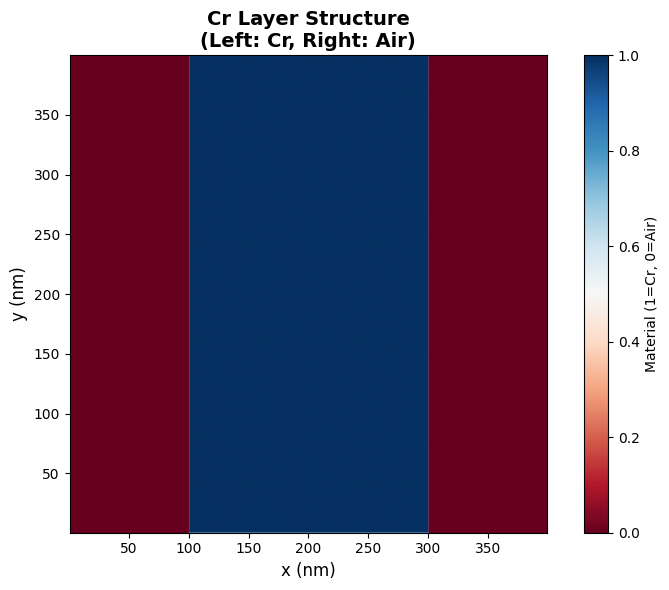


模擬設置完成
繞射階數範圍: -3 到 +3

開始提取 7 個一維繞射階 (m, n=0) 的資料（含衰減波）...
階數 m=-3: |Sxx|=0.1278(✓衰減波  ), ∠Sxx= +19.30° | |Syy|=0.0158(✓衰減波  ), ∠Syy=-168.08° | η=0.0166
階數 m=-2: |Sxx|=0.0370(傳播波   ), ∠Sxx=+110.59° | |Syy|=0.1593(傳播波   ), ∠Syy=+111.21° | η=0.0268
階數 m=-1: |Sxx|=0.3235(傳播波   ), ∠Sxx=+125.91° | |Syy|=0.4143(傳播波   ), ∠Syy=+120.79° | η=0.2763
階數 m=+0: |Sxx|=0.5397(傳播波   ), ∠Sxx=+125.08° | |Syy|=0.5833(傳播波   ), ∠Syy=+121.92° | η=0.6316
階數 m=+1: |Sxx|=0.3235(傳播波   ), ∠Sxx=+126.36° | |Syy|=0.4143(傳播波   ), ∠Syy=+121.24° | η=0.2763
階數 m=+2: |Sxx|=0.0370(傳播波   ), ∠Sxx=+111.49° | |Syy|=0.1593(傳播波   ), ∠Syy=+112.11° | η=0.0268
階數 m=+3: |Sxx|=0.1278(✓衰減波  ), ∠Sxx= +20.65° | |Syy|=0.0158(✓衰減波  ), ∠Syy=-166.73° | η=0.0166


C:\Users\USER\AppData\Local\Temp\ipykernel_17640\2320431195.py:404: UserWarning: Glyph 34928 (\N{CJK UNIFIED IDEOGRAPH-8870}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17640\2320431195.py:404: UserWarning: Glyph 28187 (\N{CJK UNIFIED IDEOGRAPH-6E1B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17640\2320431195.py:404: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34928 (\N{CJK UNIFIED IDEOGRAPH-8870}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28187 (\N{CJK UNIFIED IDEOGRAPH-6E1B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figu

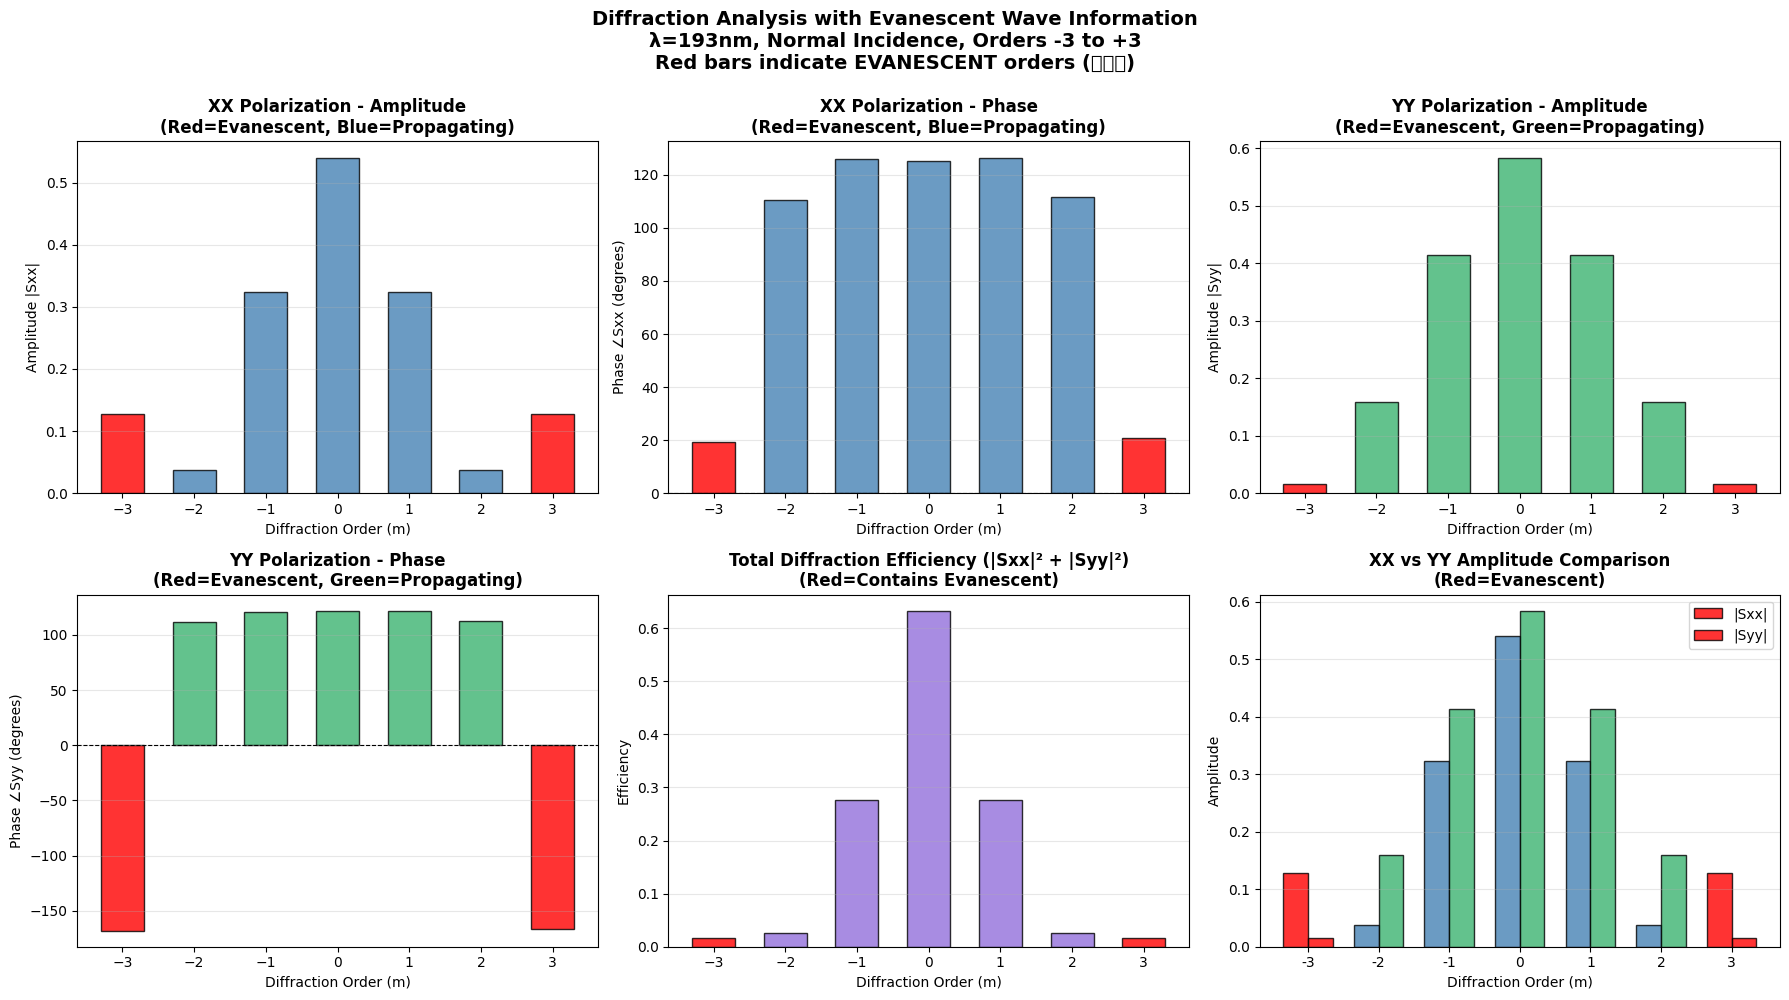


詳細數據摘要 (Detailed Diffraction Analysis - Including Evanescent Waves)
   階數    |    XX振幅    |     XX類型     |    XX相位(°)     |    YY振幅    |     YY類型     |    YY相位(°)     |     效率    
------------------------------------------------------------------------------------------------------------------------
   -3    |   0.1278   |     ✓衰減波     |     19.30      |   0.0158   |     ✓衰減波     |    -168.08     |   0.0166  
   -2    |   0.0370   |     傳播波      |     110.59     |   0.1593   |     傳播波      |     111.21     |   0.0268  
   -1    |   0.3235   |     傳播波      |     125.91     |   0.4143   |     傳播波      |     120.79     |   0.2763  
   0     |   0.5397   |     傳播波      |     125.08     |   0.5833   |     傳播波      |     121.92     |   0.6316  
   1     |   0.3235   |     傳播波      |     126.36     |   0.4143   |     傳播波      |     121.24     |   0.2763  
   2     |   0.0370   |     傳播波      |     111.49     |   0.1593   |     傳播波      |     112.11     |   0.0268  
   3     |   0.1278   |   

In [6]:
'''
DUV光學微影系統模擬 - 實際光罩結構（含衰減波分析）
波長: 193nm, 垂直入射, 分析-3到+3階繞射
結構: SiO2基板 / Cr-空氣半半層 / 空氣
新增: 衰減波資訊提取與視覺化（完全修正版）
'''

# ==================== 匯入必要模組 ====================
import numpy as np
import torch
import matplotlib.pyplot as plt
import warnings
import torcwa

# ==================== 硬體設定 ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sim_dtype = torch.complex64
geo_dtype = torch.float32

print(f"使用裝置: {device}")

# ==================== 定義新函式：包含衰減波資訊 ====================
def S_parameters_with_evanescent(self, orders, *, 
                                   direction='forward', 
                                   port='transmission', 
                                   polarization='xx', 
                                   ref_order=[0,0], 
                                   power_norm=False,
                                   return_evanescent_info=False):
    
    orders = torch.as_tensor(orders, dtype=torch.int64, device=self._device).reshape([-1,2])
    
    # Direction validation
    if direction in ['f', 'forward']:
        direction = 'forward'
    elif direction in ['b', 'backward']:
        direction = 'backward'
    else:
        warnings.warn('Invalid propagation direction. Set as forward.', UserWarning)
        direction = 'forward'
    
    # Port validation
    if port in ['t', 'transmission']:
        port = 'transmission'
    elif port in ['r', 'reflection']:
        port = 'reflection'
    else:
        warnings.warn('Invalid port. Set as transmission.', UserWarning)
        port = 'transmission'
    
    # Polarization validation
    if polarization not in ['xx', 'yx', 'xy', 'yy', 'pp', 'sp', 'ps', 'ss']:
        warnings.warn('Invalid polarization. Set as xx.', UserWarning)
        polarization = 'xx'
    
    ref_order = torch.as_tensor(ref_order, dtype=torch.int64, device=self._device).reshape([1,2])
    
    # Matching order indices
    order_indices = self._matching_indices(orders)
    ref_order_index = self._matching_indices(ref_order)
    
    # 將索引轉換為 Python 標量值
    order_indices_scalar = order_indices.item() if order_indices.numel() == 1 else order_indices
    
    # ========== XY Polarization ==========
    if polarization in ['xx', 'yx', 'xy', 'yy']:
        # 計算 Kz
        Kz_norm_dn_in_complex = torch.sqrt(self.eps_in*self.mu_in - self.Kx_norm_dn**2 - self.Ky_norm_dn**2)
        Kz_norm_dn_out_complex = torch.sqrt(self.eps_out*self.mu_out - self.Kx_norm_dn**2 - self.Ky_norm_dn**2)
        
        # 判定衰減波（但不設為零）
        evanscent_threshold = 1e-3
        is_evanescent_in = torch.abs(torch.real(Kz_norm_dn_in_complex) / (torch.imag(Kz_norm_dn_in_complex) + 1e-12)) < evanscent_threshold
        is_evanescent_out = torch.abs(torch.real(Kz_norm_dn_out_complex) / (torch.imag(Kz_norm_dn_out_complex) + 1e-12)) < evanscent_threshold
        
        # ===== 修正：先獲取衰減波標記（在調整前）=====
        if direction == 'forward' and port == 'transmission':
            is_evanescent_mask_raw = is_evanescent_out
        elif direction == 'forward' and port == 'reflection':
            is_evanescent_mask_raw = is_evanescent_in
        elif direction == 'backward' and port == 'reflection':
            is_evanescent_mask_raw = is_evanescent_out
        elif direction == 'backward' and port == 'transmission':
            is_evanescent_mask_raw = is_evanescent_in
        
        # 先保存原始 order_indices
        order_indices_for_evanescent = order_indices.clone()
        
        # 進行 polarization 調整
        if polarization == 'yx' or polarization == 'yy':
            order_indices = order_indices + self.order_N
        if polarization == 'xy' or polarization == 'yy':
            ref_order_index = ref_order_index + self.order_N
        
        # 提取調整後的衰減波標記（使用原始索引）
        if order_indices_for_evanescent.numel() == 1:
            is_evanescent_mask = is_evanescent_mask_raw[order_indices_for_evanescent.item()]
        else:
            is_evanescent_mask = is_evanescent_mask_raw[order_indices_for_evanescent]
        
        # Power normalization (optional)
        if power_norm:
            warnings.warn('power_norm=True may cause numerical issues for evanescent waves.', UserWarning)
            
            Kz_norm_dn_in = Kz_norm_dn_in_complex
            Kz_norm_dn_out = Kz_norm_dn_out_complex
            Kz_norm_dn_in = torch.hstack((Kz_norm_dn_in, Kz_norm_dn_in))
            Kz_norm_dn_out = torch.hstack((Kz_norm_dn_out, Kz_norm_dn_out))
            
            Kx_norm_dn = torch.hstack((self.Kx_norm_dn, self.Kx_norm_dn))
            Ky_norm_dn = torch.hstack((self.Ky_norm_dn, self.Ky_norm_dn))
            
            if polarization == 'xx':
                numerator_pol, denominator_pol = Kx_norm_dn, Kx_norm_dn
            elif polarization == 'xy':
                numerator_pol, denominator_pol = Kx_norm_dn, Ky_norm_dn
            elif polarization == 'yx':
                numerator_pol, denominator_pol = Ky_norm_dn, Kx_norm_dn
            elif polarization == 'yy':
                numerator_pol, denominator_pol = Ky_norm_dn, Ky_norm_dn
            
            if direction == 'forward' and port == 'transmission':
                numerator_kz = Kz_norm_dn_out
                denominator_kz = Kz_norm_dn_in
            elif direction == 'forward' and port == 'reflection':
                numerator_kz = Kz_norm_dn_in
                denominator_kz = Kz_norm_dn_in
            elif direction == 'backward' and port == 'reflection':
                numerator_kz = Kz_norm_dn_out
                denominator_kz = Kz_norm_dn_out
            elif direction == 'backward' and port == 'transmission':
                numerator_kz = Kz_norm_dn_in
                denominator_kz = Kz_norm_dn_out
            
            normalization = torch.sqrt((1+(numerator_pol[order_indices]/numerator_kz[order_indices])**2) / 
                                      (1+(denominator_pol[ref_order_index]/denominator_kz[ref_order_index])**2))
            normalization = normalization * torch.sqrt(numerator_kz[order_indices] / denominator_kz[ref_order_index])
        else:
            normalization = 1.
        
        # Get S-parameters (不過濾衰減波)
        if direction == 'forward' and port == 'transmission':
            S = self.S[0][order_indices, ref_order_index] * normalization
        elif direction == 'forward' and port == 'reflection':
            S = self.S[1][order_indices, ref_order_index] * normalization
        elif direction == 'backward' and port == 'reflection':
            S = self.S[2][order_indices, ref_order_index] * normalization
        elif direction == 'backward' and port == 'transmission':
            S = self.S[3][order_indices, ref_order_index] * normalization
        
        # 只處理 inf/nan，不將衰減波設為零
        S = torch.where(torch.isinf(S), torch.zeros_like(S), S)
        S = torch.where(torch.isnan(S), torch.zeros_like(S), S)
        
        if return_evanescent_info:
            return S, is_evanescent_mask
        else:
            return S
    
    else:
        return None


# 將函式綁定到類別
torcwa.rcwa.S_parameters_with_evanescent = S_parameters_with_evanescent
print("✓ 衰減波函式已綁定")

# ==================== 光源參數設定 (DUV) ====================
lamb0 = torch.tensor(193.0, dtype=geo_dtype, device=device)
inc_ang = 0.0 * (np.pi/180)
azi_ang = 0.0 * (np.pi/180)

# ==================== 材料光學常數設定 (193nm) ====================
air_eps = 1.0
n_Cr = 0.842
k_Cr = 1.647
Cr_eps = (n_Cr + 1j*k_Cr)**2
n_SiO2 = 1.563
k_SiO2 = 0.0
SiO2_eps = (n_SiO2 + 1j*k_SiO2)**2

print(f"\nDUV波長: {lamb0.item()} nm")
print(f"入射角度: {inc_ang*180/np.pi:.1f}° (垂直入射)")
print(f"鉻 (Cr) 光學常數: n={n_Cr:.3f}, k={k_Cr:.3f}")
print(f"二氧化矽 (SiO2) 光學常數: n={n_SiO2:.3f}, k={k_SiO2:.3f}")

# ==================== 光罩幾何結構設定 ====================
L = [400.0, 400.0]

torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800
torcwa.rcwa_geo.ny = 800
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.0

# 定義鉻層圖形
left_rectangle = torcwa.rcwa_geo.rectangle(
    Wx=L[0]/2,
    Wy=L[1],
    Cx=L[0]/2,
    Cy=L[1]/2
)

Cr_layer_eps = left_rectangle * Cr_eps + (1.0 - left_rectangle) * air_eps
Cr_layer_thickness = 70.0

print(f"\n=== 結構設定 ===")
print(f"Unit cell 尺寸: {L[0]} nm × {L[1]} nm")
print(f"鉻層厚度: {Cr_layer_thickness} nm (左半側: Cr, 右半側: 空氣)")
print(f"輸出層: 空氣")

# ==================== 視覺化結構 ====================
x_axis = torcwa.rcwa_geo.x.cpu().numpy()
y_axis = torcwa.rcwa_geo.y.cpu().numpy()

plt.figure(figsize=(8, 6))
im = plt.imshow(torch.transpose(left_rectangle, -2, -1).cpu().numpy(), 
                cmap='RdBu', origin='lower',
                extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]])
plt.title('Cr Layer Structure\n(Left: Cr, Right: Air)', fontsize=14, fontweight='bold')
plt.xlabel('x (nm)', fontsize=12)
plt.ylabel('y (nm)', fontsize=12)
plt.colorbar(im, label='Material (1=Cr, 0=Air)')
plt.tight_layout()
plt.show()

# ==================== 建立RCWA模擬 ====================
order_N = 3
order = [order_N, order_N]

sim = torcwa.rcwa(
    freq=1/lamb0,
    order=order,
    L=L,
    dtype=sim_dtype,
    device=device
)

sim.add_input_layer(eps=SiO2_eps, mu=1.)
sim.set_incident_angle(inc_ang=inc_ang, azi_ang=azi_ang)
sim.add_layer(thickness=Cr_layer_thickness, eps=Cr_layer_eps)
sim.solve_global_smatrix()

print(f"\n模擬設置完成")
print(f"繞射階數範圍: -{order_N} 到 +{order_N}")

# ==================== 提取繞射階的振幅與相位（含衰減波）====================
orders_range = range(-order_N, order_N+1)
num_orders = len(orders_range)

results = {}
evanescent_info = {}

print(f"\n開始提取 {num_orders} 個一維繞射階 (m, n=0) 的資料（含衰減波）...")
print("="*100)

for m in orders_range:
    n = 0
    
    # 使用新函式取得 XX 極化（含衰減波資訊）
    s_xx, is_evan_xx = sim.S_parameters_with_evanescent(
        orders=[m, n],
        direction='forward',
        port='transmission',
        polarization='xx',
        ref_order=[0, 0],
        return_evanescent_info=True
    )
    
    # 使用新函式取得 YY 極化（含衰減波資訊）
    s_yy, is_evan_yy = sim.S_parameters_with_evanescent(
        orders=[m, n],
        direction='forward',
        port='transmission',
        polarization='yy',
        ref_order=[0, 0],
        return_evanescent_info=True
    )
    
    # 提取振幅和相位
    amp_xx = torch.abs(s_xx).cpu().item()
    phase_xx = torch.angle(s_xx).cpu().item()
    amp_yy = torch.abs(s_yy).cpu().item()
    phase_yy = torch.angle(s_yy).cpu().item()
    
    # 計算總效率
    efficiency = amp_xx**2 + amp_yy**2
    
    # 判定衰減波狀態
    is_evanescent_xx = is_evan_xx.cpu().item() if isinstance(is_evan_xx, torch.Tensor) else is_evan_xx
    is_evanescent_yy = is_evan_yy.cpu().item() if isinstance(is_evan_yy, torch.Tensor) else is_evan_yy
    
    results[m] = {
        'amp_xx': amp_xx,
        'phase_xx': phase_xx,
        'amp_yy': amp_yy,
        'phase_yy': phase_yy,
        'efficiency': efficiency
    }
    
    evanescent_info[m] = {
        'is_evanescent_xx': is_evanescent_xx,
        'is_evanescent_yy': is_evanescent_yy
    }
    
    # 標記衰減波
    evan_marker_xx = "✓衰減波" if is_evanescent_xx else "傳播波"
    evan_marker_yy = "✓衰減波" if is_evanescent_yy else "傳播波"
    
    print(f"階數 m={m:+2d}: |Sxx|={amp_xx:.4f}({evan_marker_xx:6s}), "
          f"∠Sxx={np.degrees(phase_xx):+7.2f}° | "
          f"|Syy|={amp_yy:.4f}({evan_marker_yy:6s}), "
          f"∠Syy={np.degrees(phase_yy):+7.2f}° | η={efficiency:.4f}")

print("="*100)

# ==================== 視覺化結果：長條圖（改進版） ====================
orders_list = list(orders_range)
amp_xx_list = [results[m]['amp_xx'] for m in orders_list]
amp_yy_list = [results[m]['amp_yy'] for m in orders_list]
phase_xx_list = [np.degrees(results[m]['phase_xx']) for m in orders_list]
phase_yy_list = [np.degrees(results[m]['phase_yy']) for m in orders_list]
efficiency_list = [results[m]['efficiency'] for m in orders_list]

# 衰減波標記色彩
colors_xx = ['red' if evanescent_info[m]['is_evanescent_xx'] else 'steelblue' for m in orders_list]
colors_yy = ['red' if evanescent_info[m]['is_evanescent_yy'] else 'mediumseagreen' for m in orders_list]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) XX極化振幅
axes[0, 0].bar(orders_list, amp_xx_list, color=colors_xx, alpha=0.8, edgecolor='black', width=0.6)
axes[0, 0].set_title('XX Polarization - Amplitude\n(Red=Evanescent, Blue=Propagating)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Diffraction Order (m)')
axes[0, 0].set_ylabel('Amplitude |Sxx|')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_xticks(orders_list)

# (2) XX極化相位
axes[0, 1].bar(orders_list, phase_xx_list, color=colors_xx, alpha=0.8, edgecolor='black', width=0.6)
axes[0, 1].set_title('XX Polarization - Phase\n(Red=Evanescent, Blue=Propagating)', 
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Diffraction Order (m)')
axes[0, 1].set_ylabel('Phase ∠Sxx (degrees)')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_xticks(orders_list)
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)

# (3) YY極化振幅
axes[0, 2].bar(orders_list, amp_yy_list, color=colors_yy, alpha=0.8, edgecolor='black', width=0.6)
axes[0, 2].set_title('YY Polarization - Amplitude\n(Red=Evanescent, Green=Propagating)', 
                     fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Diffraction Order (m)')
axes[0, 2].set_ylabel('Amplitude |Syy|')
axes[0, 2].grid(axis='y', alpha=0.3)
axes[0, 2].set_xticks(orders_list)

# (4) YY極化相位
axes[1, 0].bar(orders_list, phase_yy_list, color=colors_yy, alpha=0.8, edgecolor='black', width=0.6)
axes[1, 0].set_title('YY Polarization - Phase\n(Red=Evanescent, Green=Propagating)', 
                     fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Diffraction Order (m)')
axes[1, 0].set_ylabel('Phase ∠Syy (degrees)')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_xticks(orders_list)
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)

# (5) 繞射效率
colors_eff = ['red' if (evanescent_info[m]['is_evanescent_xx'] or evanescent_info[m]['is_evanescent_yy']) 
              else 'mediumpurple' for m in orders_list]
axes[1, 1].bar(orders_list, efficiency_list, color=colors_eff, alpha=0.8, edgecolor='black', width=0.6)
axes[1, 1].set_title('Total Diffraction Efficiency (|Sxx|² + |Syy|²)\n(Red=Contains Evanescent)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Diffraction Order (m)')
axes[1, 1].set_ylabel('Efficiency')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_xticks(orders_list)

# (6) XX 與 YY 振幅對比
x_pos = np.arange(len(orders_list))
width = 0.35
axes[1, 2].bar(x_pos - width/2, amp_xx_list, width, label='|Sxx|', 
               color=['red' if evanescent_info[m]['is_evanescent_xx'] else 'steelblue' for m in orders_list],
               alpha=0.8, edgecolor='black')
axes[1, 2].bar(x_pos + width/2, amp_yy_list, width, label='|Syy|', 
               color=['red' if evanescent_info[m]['is_evanescent_yy'] else 'mediumseagreen' for m in orders_list],
               alpha=0.8, edgecolor='black')
axes[1, 2].set_title('XX vs YY Amplitude Comparison\n(Red=Evanescent)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Diffraction Order (m)')
axes[1, 2].set_ylabel('Amplitude')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(orders_list)
axes[1, 2].legend()
axes[1, 2].grid(axis='y', alpha=0.3)

plt.suptitle(f'Diffraction Analysis with Evanescent Wave Information\n' + 
             f'λ={lamb0.item():.0f}nm, Normal Incidence, Orders -3 to +3\n' +
             f'Red bars indicate EVANESCENT orders (衰減波)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ==================== 數據摘要表 ====================
print("\n" + "="*120)
print("詳細數據摘要 (Detailed Diffraction Analysis - Including Evanescent Waves)")
print("="*120)
print(f"{'階數':^8} | {'XX振幅':^10} | {'XX類型':^12} | {'XX相位(°)':^14} | "
      f"{'YY振幅':^10} | {'YY類型':^12} | {'YY相位(°)':^14} | {'效率':^10}")
print("-"*120)
for m in orders_list:
    type_xx = "✓衰減波" if evanescent_info[m]['is_evanescent_xx'] else "傳播波"
    type_yy = "✓衰減波" if evanescent_info[m]['is_evanescent_yy'] else "傳播波"
    print(f"{m:^8d} | {results[m]['amp_xx']:^10.4f} | {type_xx:^12s} | "
          f"{np.degrees(results[m]['phase_xx']):^14.2f} | "
          f"{results[m]['amp_yy']:^10.4f} | {type_yy:^12s} | "
          f"{np.degrees(results[m]['phase_yy']):^14.2f} | "
          f"{results[m]['efficiency']:^10.4f}")
print("="*120)

# 衰減波分析
print("\n【衰減波分析摘要】")
evanescent_orders = [m for m in orders_list if evanescent_info[m]['is_evanescent_xx'] or evanescent_info[m]['is_evanescent_yy']]
if evanescent_orders:
    print(f"✓ 檢測到衰減波：階數 {evanescent_orders}")
    for m in evanescent_orders:
        if evanescent_info[m]['is_evanescent_xx']:
            print(f"  - m={m:+2d} (XX): 振幅={results[m]['amp_xx']:.4f}, 相位={np.degrees(results[m]['phase_xx']):+.2f}°")
        if evanescent_info[m]['is_evanescent_yy']:
            print(f"  - m={m:+2d} (YY): 振幅={results[m]['amp_yy']:.4f}, 相位={np.degrees(results[m]['phase_yy']):+.2f}°")
else:
    print("✗ 沒有檢測到衰減波（所有階都是傳播波）")

# 能量守恆檢查
total_efficiency = sum(efficiency_list)
print(f"\n【能量守恆檢查】")
print(f"總效率: {total_efficiency:.4f}")
if results[0]['efficiency'] > 0:
    print(f"零階效率佔比: {results[0]['efficiency']/total_efficiency*100:.2f}%")

print("\n✓ 模擬完成！")



正在提取 -3 到 +3 階的複數場資訊以進行空間重建...


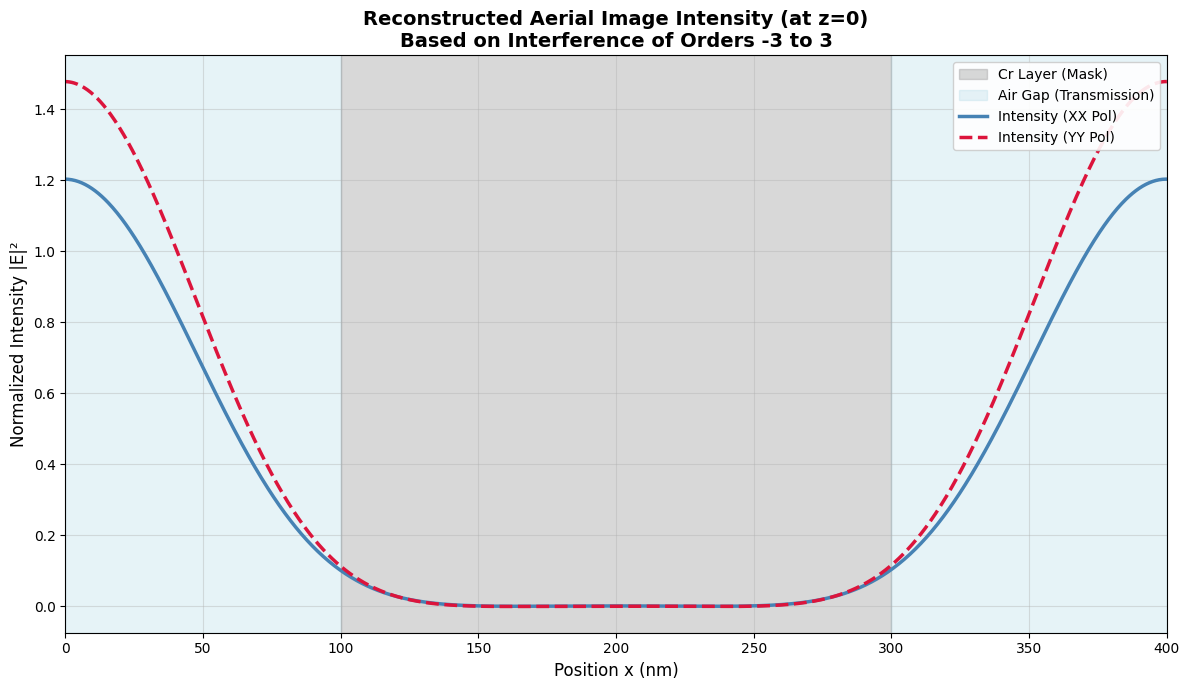

模擬結果分析
最大強度 (XX): 1.2032
最小強度 (XX): 0.0006
對比度 (Michelson Contrast): 0.9990


In [ ]:
'''
DUV光學微影系統模擬 - 空間強度分佈重建
波長: 193nm, 垂直入射, 分析-3到+3階繞射
結構: SiO2基板 / Cr-空氣半半層 / 空氣
功能: 計算Unit Cell內的強度分佈
'''

import numpy as np
import torch
import matplotlib.pyplot as plt
import torcwa

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sim_dtype = torch.complex64
geo_dtype = torch.float32

lamb0 = torch.tensor(193.0, dtype=geo_dtype, device=device)
inc_ang = 0.0 

# 材料設定
air_eps = 1.0
Cr_eps = (0.842 + 1j*1.647)**2
SiO2_eps = (1.563 + 1j*0.0)**2

# ==================== 幾何結構設定 ====================
L = [400.0, 400.0] # Period: 400nm

# 初始化 torcwa 幾何
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800
torcwa.rcwa_geo.ny = 800
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.0


Cr_rectangle = torcwa.rcwa_geo.rectangle(
    Wx=L[0]/2, Wy=L[1], Cx=L[0]/2, Cy=L[1]/2
)
Cr_layer_eps = left_rectangle * Cr_eps + (1.0 - Cr_rectangle) * air_eps
Cr_layer_thickness = 70.0

# ==================== RCWA 模擬核心 ====================
order_N = 3
sim = torcwa.rcwa(
    freq=1/lamb0,
    order=[order_N, order_N],
    L=L,
    dtype=sim_dtype,
    device=device
)
sim.add_input_layer(eps=SiO2_eps, mu=1.)
sim.set_incident_angle(inc_ang=inc_ang, azi_ang=0.0)
sim.add_layer(thickness=Cr_layer_thickness, eps=Cr_layer_eps)
sim.solve_global_smatrix()

# ==================== 提取複數 S 參數 ====================
orders_range = range(-order_N, order_N+1)
complex_S_xx = {} # 儲存 XX 極化的複數傳輸係數
complex_S_yy = {} # 儲存 YY 極化的複數傳輸係數

print(f"\n正在提取 -{order_N} 到 +{order_N} 階的複數場資訊以進行空間重建...")

for m in orders_range:
    # 取得原始的複數 tensor (S-matrix element)
    # Transmission, forward
    s_xx_tensor = sim.S_parameters(orders=[m, 0], direction='forward', port='transmission', polarization='xx', ref_order=[0, 0])
    s_yy_tensor = sim.S_parameters(orders=[m, 0], direction='forward', port='transmission', polarization='yy', ref_order=[0, 0])
    
    # 轉為 Python complex number 儲存
    complex_S_xx[m] = s_xx_tensor.cpu().item()
    complex_S_yy[m] = s_yy_tensor.cpu().item()

# ==================== 核心邏輯：空間強度重建 (基於圖片原理) ====================
# 1. 定義空間座標 x (在一個 Unit Cell 內: 0 到 400nm)
x_grid = np.linspace(0, L[0], 1000) 

# 2. 初始化總電場 (Complex Field)
E_total_xx = np.zeros_like(x_grid, dtype=np.complex128)
E_total_yy = np.zeros_like(x_grid, dtype=np.complex128)

# 3. 疊加所有繞射階 (Superposition Principle)# 公式: E(x) = sum( S_m * exp(i * k_xm * x) )# k_xm = m * (2*pi / Period)
grating_k = 2 * np.pi / L[0]

for m in orders_range:
    # 計算該階數對應的相位項 exp(i * k_x * x)
    phase_term = np.exp(1j * m * grating_k * x_grid)
    
    # 線性疊加
    E_total_xx += complex_S_xx[m] * phase_term
    E_total_yy += complex_S_yy[m] * phase_term

# 4. 計算強度 I = |E|^2 
I_xx = np.abs(E_total_xx)**2
I_yy = np.abs(E_total_yy)**2
I_total = I_xx + I_yy 

# ==================== 視覺化：強度分佈圖 ====================
plt.figure(figsize=(12, 7))

# 繪製結構背景 (遮罩陰影區)
plt.axvspan(0, 100, color='lightblue', alpha=0.3)
plt.axvspan(100, 300, color='gray', alpha=0.3, label='Cr Layer (Mask)')
plt.axvspan(300, 400, color='lightblue', alpha=0.3, label='Air Gap (Transmission)')

# 繪製強度曲線
plt.plot(x_grid, I_xx, label='Intensity (XX Pol)', color='steelblue', linewidth=2.5)
plt.plot(x_grid, I_yy, label='Intensity (YY Pol)', color='crimson', linewidth=2.5, linestyle='--')

plt.title(f'Reconstructed Aerial Image Intensity (at z=0)\nBased on Interference of Orders {orders_range[0]} to {orders_range[-1]}', fontsize=14, fontweight='bold')
plt.xlabel('Position x (nm)', fontsize=12)
plt.ylabel('Normalized Intensity |E|²', fontsize=12)
plt.xlim(0, L[0])
plt.grid(True, alpha=0.4)
plt.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

# ==================== 數據驗證與解釋 ====================
print("="*80)
print("模擬結果分析")
print("="*80)
print(f"最大強度 (XX): {np.max(I_xx):.4f}")
print(f"最小強度 (XX): {np.min(I_xx):.4f}")
print(f"對比度 (Michelson Contrast): {(np.max(I_xx)-np.min(I_xx))/(np.max(I_xx)+np.min(I_xx)):.4f}")



正在提取 0 級與 +1 級的複數參數...
結構分佈: Air(0-100) -- Cr(100-300) -- Air(300-400)
0 級: 振幅=0.4317, 相位=125.08°
1 級: 振幅=0.2765, 相位=126.36°
模擬結果分析
最大強度 (XX): 0.5015
最小強度 (XX): 0.0241
對比度 (Michelson Contrast): 0.9083


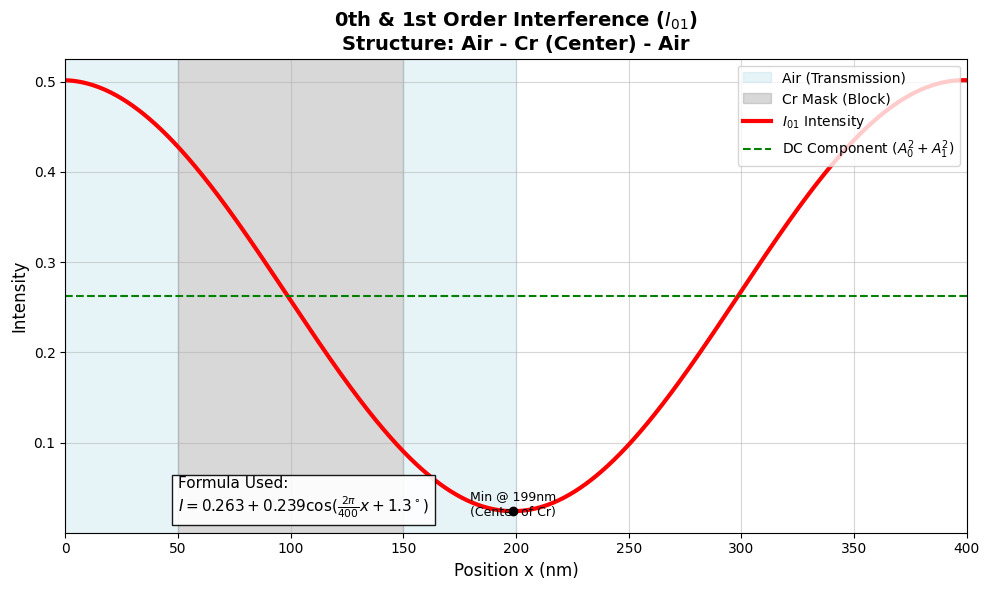

--------------------------------------------------
強度最小值位置: 198.6 nm 
強度最大值位置: 398.4 nm 
--------------------------------------------------


In [2]:
'''
DUV光學微影系統 - 雙光束干涉 (I_01) 
波長: 193nm, 垂直入射
結構: Air(0-100nm) - Cr(100-300nm) - Air(300-400nm)
'''

# ==================== 匯入與設定 ====================
import numpy as np
import torch
import matplotlib.pyplot as plt
import torcwa

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype_c = torch.complex64
dtype_r = torch.float32

# 參數設定
lamb0 = torch.tensor(193.0, dtype=dtype_r, device=device)
L = [400.0, 400.0] 
grating_period = L[0]

# 幾何與材料
torcwa.rcwa_geo.dtype = dtype_r
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800
torcwa.rcwa_geo.ny = 800
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.0


center_cr_block = torcwa.rcwa_geo.rectangle(Wx=L[0]/2, Wy=L[1], Cx=L[0]/2, Cy=L[1]/2)

Cr_eps = (0.842 + 1j*1.647)**2
air_eps = 1.0
SiO2_eps = (1.563 + 1j*0.0)**2

Cr_layer_eps = center_cr_block * Cr_eps + (1.0 - center_cr_block) * air_eps

# ==================== RCWA 模擬 ====================
sim = torcwa.rcwa(freq=1/lamb0, order=[3, 3], L=L, dtype=dtype_c, device=device)
sim.add_input_layer(eps=SiO2_eps, mu=1.)
sim.set_incident_angle(inc_ang=0.0, azi_ang=0.0)
sim.add_layer(thickness=70.0, eps=Cr_layer_eps)
sim.solve_global_smatrix()

# ==================== 提取 S 參數並代入公式 ====================
print("\n正在提取 0 級與 +1 級的複數參數...")

n_order = 0  # 0級
m_order = 1  # 1級

# 提取 S 參數
S_n = sim.S_parameters(orders=[n_order, 0], direction='forward', port='transmission', polarization='xx', ref_order=[0,0]).cpu().item()
S_m = sim.S_parameters(orders=[m_order, 0], direction='forward', port='transmission', polarization='xx', ref_order=[0,0]).cpu().item()

# 取得振幅與相位
A_n = abs(S_n) 
A_m = abs(S_m) 
phi_n = np.angle(S_n) 
phi_m = np.angle(S_m) 

print(f"結構分佈: Air(0-100) -- Cr(100-300) -- Air(300-400)")
print(f"0 級: 振幅={A_n:.4f}, 相位={np.degrees(phi_n):.2f}°")
print(f"1 級: 振幅={A_m:.4f}, 相位={np.degrees(phi_m):.2f}°")

# ==================== 套用圖片公式 I_nm ====================
x = np.linspace(0, grating_period, 1000)

DC_term = A_n**2 + A_m**2             
AC_term_coeff = 2 * A_n * A_m         
spatial_freq = (m_order - n_order) * 2 * np.pi / grating_period
phase_diff = phi_m - phi_n            

# 計算強度
I_01 = DC_term + AC_term_coeff * np.cos(spatial_freq * x + phase_diff)

# ==================== 視覺化結果 (修正背景) ====================
plt.figure(figsize=(10, 6))

# 0-100nm: Air
plt.axvspan(0, 50, color='lightblue', alpha=0.3, label='Air (Transmission)')
# 100-300nm: Cr
plt.axvspan(50, 150, color='gray', alpha=0.3, label='Cr Mask (Block)')
# 300-400nm: Air
plt.axvspan(150, 200, color='lightblue', alpha=0.3) # 同上，不重複標籤

# 繪製計算出的 I_01
plt.plot(x, I_01, color='red', linewidth=3, label=r'$I_{01}$ Intensity')
plt.axhline(y=DC_term, color='green', linestyle='--', label='DC Component ($A_0^2+A_1^2$)')

plt.title(f'0th & 1st Order Interference ($I_{{01}}$)\nStructure: Air - Cr (Center) - Air', fontsize=14, fontweight='bold')
plt.xlabel('Position x (nm)', fontsize=12)
plt.ylabel('Intensity', fontsize=12)
plt.xlim(0, 400)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.5)

# 標註波峰波谷對應
min_idx = np.argmin(I_01)
max_idx = np.argmax(I_01)
plt.plot(x[min_idx], I_01[min_idx], 'ko')
plt.text(x[min_idx], I_01[min_idx]*0.8, f'Min @ {x[min_idx]:.0f}nm\n(Center of Cr)', ha='center', fontsize=9) 

print("="*80)
print("模擬結果分析")
print("="*80)
print(f"最大強度 (XX): {np.max(I_01):.4f}")
print(f"最小強度 (XX): {np.min(I_01):.4f}")
print(f"對比度 (Michelson Contrast): {(np.max(I_01)-np.min(I_01))/(np.max(I_01)+np.min(I_01)):.4f}")

plt.text(50, np.min(I_01), 
         f"Formula Used:\n$I = {A_n**2 + A_m**2:.3f} + {2*A_n*A_m:.3f}\cos(\\frac{{2\pi}}{{400}}x + {np.degrees(phase_diff):.1f}^\circ)$", 
         fontsize=11, bbox=dict(facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()


# 簡單驗證
print("-" * 50)
print(f"強度最小值位置: {x[min_idx]:.1f} nm ")
print(f"強度最大值位置: {x[max_idx]:.1f} nm ")
print("-" * 50)

True
<class 'method'>


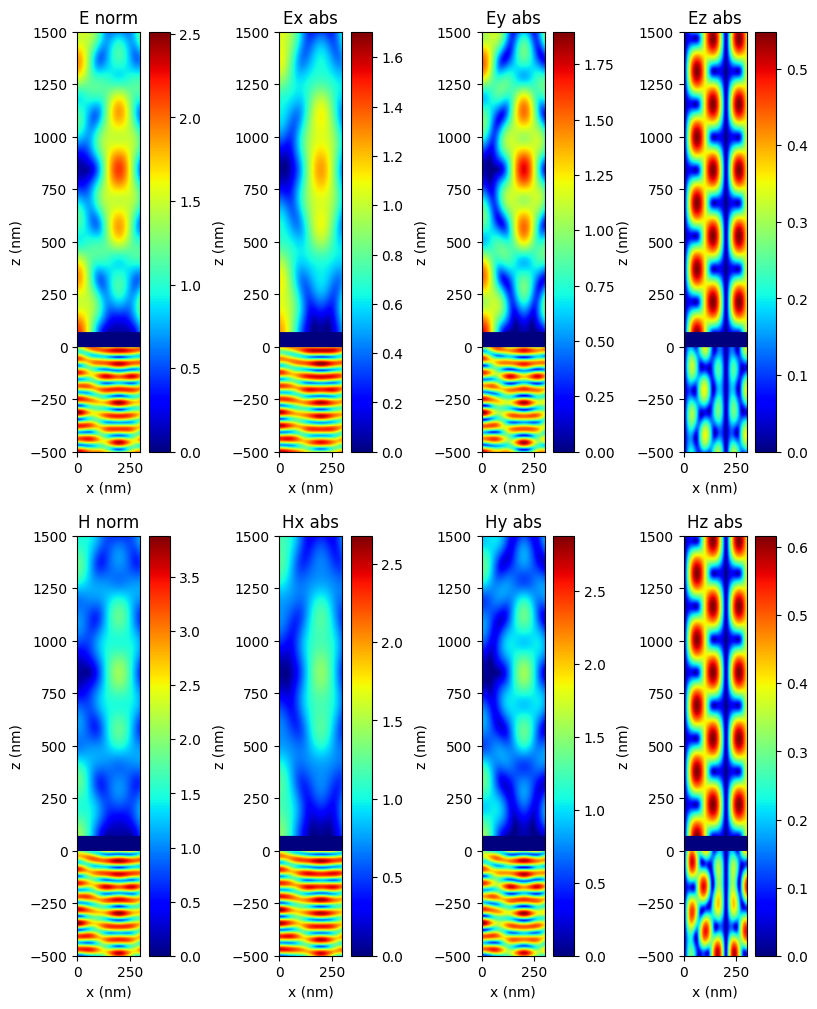

In [9]:
import torch
import warnings
import torcwa 

# 定義新函式
def field_xz_propagating_only(self, x_axis, z_axis, y):
    '''
    XZ-plane field distribution (Propagating Waves ONLY).
    Dynamically added to torcwa class.
    '''
    
    if type(x_axis) != torch.Tensor or type(z_axis) != torch.Tensor:
        warnings.warn('x and z axis must be torch.Tensor type. Return None.', UserWarning)
        return None

    # 閾值設定
    EVANESCENT_TOL = 1e-5

    x_axis = x_axis.reshape([-1,1,1])

    Kx_norm, Ky_norm = self.Kx_norm, self.Ky_norm

    Ex_split, Ey_split, Ez_split = [], [], []
    Hx_split, Hy_split, Hz_split = [], [], []

    # layer number calculation
    zp = torch.zeros(len(self.thickness), device=self._device)
    zm = torch.zeros(len(self.thickness), device=self._device)
    layer_num = torch.zeros([len(z_axis)], dtype=torch.int64, device=self._device)
    layer_num[z_axis < 0.] = -1

    for ti in range(len(self.thickness)):
        zp[ti:] += self.thickness[ti]
    zm[1:] = zp[0:-1]

    for bi in range(len(zp)):
        layer_num[z_axis > zp[bi]] += 1

    prev_layer_num = -2
    for zi in range(len(z_axis)):
        # --- Homogeneous Layers ---
        if layer_num[zi] == -1 or layer_num[zi] == self.layer_N:
            Kx_norm_dn = self.Kx_norm_dn
            Ky_norm_dn = self.Ky_norm_dn

            if layer_num[zi] == -1:
                z_prop = z_axis[zi] if z_axis[zi] <= 0. else 0.
                if layer_num[zi] != prev_layer_num:
                    eps = self.eps_in if hasattr(self,'eps_in') else 1.
                    mu = self.mu_in if hasattr(self,'mu_in') else 1.
                    Vi = self.Vi if hasattr(self,'Vi') else self.Vf
                    Kz_norm_dn = torch.sqrt(eps*mu - Kx_norm_dn**2 - Ky_norm_dn**2)
                    Kz_norm_dn = torch.where(torch.imag(Kz_norm_dn)>0,torch.conj(Kz_norm_dn),Kz_norm_dn).reshape([-1,1])
                    Kz_norm_dn = torch.vstack((Kz_norm_dn,Kz_norm_dn))
            elif layer_num[zi] == self.layer_N:
                if len(zp) == 0:
                    z_prop = z_axis[zi]
                else:
                    z_prop = z_axis[zi]-zp[-1] if z_axis[zi]-zp[-1] >= 0. else 0.
                if layer_num[zi] != prev_layer_num:
                    eps = self.eps_out if hasattr(self,'eps_in') else 1.
                    mu = self.mu_out if hasattr(self,'mu_in') else 1.        
                    Vo = self.Vo if hasattr(self,'Vo') else self.Vf
                    Kz_norm_dn = torch.sqrt(eps*mu - Kx_norm_dn**2 - Ky_norm_dn**2)
                    Kz_norm_dn = torch.where(torch.imag(Kz_norm_dn)<0,torch.conj(Kz_norm_dn),Kz_norm_dn).reshape([-1,1])
                    Kz_norm_dn = torch.vstack((Kz_norm_dn,Kz_norm_dn))

            # [FILTER]
            is_propagating = (torch.abs(torch.imag(Kz_norm_dn)) < EVANESCENT_TOL).float()
            z_phase = torch.exp(1.j*self.omega*Kz_norm_dn*z_prop) * is_propagating

            if layer_num[zi] == -1 and self.source_direction == 'forward':
                Exy_p = self.E_i*z_phase
                Hxy_p = torch.matmul(Vi,Exy_p)
                Exy_m = torch.matmul(self.S[1],self.E_i)*torch.conj(z_phase)
                Hxy_m = torch.matmul(-Vi,Exy_m)
            elif layer_num[zi] == -1 and self.source_direction == 'backward':
                Exy_p = torch.zeros_like(self.E_i)
                Hxy_p = torch.zeros_like(self.E_i)
                Exy_m = torch.matmul(self.S[3],self.E_i)*torch.conj(z_phase)
                Hxy_m = torch.matmul(-Vi,Exy_m)
            elif layer_num[zi] == self.layer_N and self.source_direction == 'forward':
                Exy_p = torch.matmul(self.S[0],self.E_i)*z_phase
                Hxy_p = torch.matmul(Vo,Exy_p)
                Exy_m = torch.zeros_like(self.E_i)
                Hxy_m = torch.zeros_like(self.E_i)
            elif layer_num[zi] == self.layer_N and self.source_direction == 'backward':
                Exy_p = torch.matmul(self.S[2],self.E_i)*z_phase
                Hxy_p = torch.matmul(Vo,Exy_p)
                Exy_m = self.E_i*torch.conj(z_phase)
                Hxy_m = torch.matmul(-Vo,Exy_m)

            Ex_mn = Exy_p[:self.order_N] + Exy_m[:self.order_N]
            Ey_mn = Exy_p[self.order_N:] + Exy_m[self.order_N:]
            Hz_mn = torch.matmul(Kx_norm,Ey_mn)/mu - torch.matmul(Ky_norm,Ex_mn)/mu
            Hx_mn = Hxy_p[:self.order_N] + Hxy_m[:self.order_N]
            Hy_mn = Hxy_p[self.order_N:] + Hxy_m[self.order_N:]
            Ez_mn = torch.matmul(Ky_norm,Hx_mn)/eps - torch.matmul(Kx_norm,Hy_mn)/eps

            xy_phase = torch.exp(1.j * self.omega * (self.Kx_norm_dn*x_axis + self.Ky_norm_dn*y))
            Ex_split.append(torch.sum(Ex_mn.reshape(1,1,-1)*xy_phase,dim=2))
            Ey_split.append(torch.sum(Ey_mn.reshape(1,1,-1)*xy_phase,dim=2))
            Ez_split.append(torch.sum(Ez_mn.reshape(1,1,-1)*xy_phase,dim=2))
            Hx_split.append(torch.sum(Hx_mn.reshape(1,1,-1)*xy_phase,dim=2))
            Hy_split.append(torch.sum(Hy_mn.reshape(1,1,-1)*xy_phase,dim=2))
            Hz_split.append(torch.sum(Hz_mn.reshape(1,1,-1)*xy_phase,dim=2))

        # --- Internal Layers ---
        else:
            z_prop = z_axis[zi] - zm[layer_num[zi]]
            
            if layer_num[zi] != prev_layer_num:
                if self.source_direction == 'forward':
                    C = torch.matmul(self.C[0][layer_num[zi]],self.E_i)
                elif self.source_direction == 'backward':
                    C = torch.matmul(self.C[1][layer_num[zi]],self.E_i)

                kz_norm = self.kz_norm[layer_num[zi]]
                E_eigvec = self.E_eigvec[layer_num[zi]]
                H_eigvec = self.H_eigvec[layer_num[zi]]

                Cp = torch.diag(C[:2*self.order_N,0])
                Cm = torch.diag(C[2*self.order_N:,0])

                eps_conv_inv = torch.linalg.inv(self.eps_conv[layer_num[zi]])
                mu_conv_inv = torch.linalg.inv(self.mu_conv[layer_num[zi]])

            # [FILTER]
            is_prop_mode = (torch.abs(torch.imag(kz_norm)) < EVANESCENT_TOL).float()
            z_phase_p = torch.diag(torch.exp(1.j*self.omega*kz_norm*z_prop) * is_prop_mode)
            z_phase_m = torch.diag(torch.exp(1.j*self.omega*kz_norm*(self.thickness[layer_num[zi]]-z_prop)) * is_prop_mode)

            Exy_p = torch.matmul(E_eigvec,z_phase_p)
            Ex_p = Exy_p[:self.order_N,:]
            Ey_p = Exy_p[self.order_N:,:]
            Hz_p = torch.matmul(mu_conv_inv,torch.matmul(Kx_norm,Ey_p)) - torch.matmul(mu_conv_inv,torch.matmul(Ky_norm,Ex_p))
            Exy_m = torch.matmul(E_eigvec,z_phase_m)
            Ex_m = Exy_m[:self.order_N,:]
            Ey_m = Exy_m[self.order_N:,:]
            Hz_m = torch.matmul(mu_conv_inv,torch.matmul(Kx_norm,Ey_m)) - torch.matmul(mu_conv_inv,torch.matmul(Ky_norm,Ex_m))
            Hxy_p = torch.matmul(H_eigvec,z_phase_p)
            Hx_p = Hxy_p[:self.order_N,:]
            Hy_p = Hxy_p[self.order_N:,:]
            Ez_p = torch.matmul(eps_conv_inv,torch.matmul(Ky_norm,Hx_p)) - torch.matmul(eps_conv_inv,torch.matmul(Kx_norm,Hy_p))
            Hxy_m = torch.matmul(-H_eigvec,z_phase_m)
            Hx_m = Hxy_m[:self.order_N,:]
            Hy_m = Hxy_m[self.order_N:,:]
            Ez_m = torch.matmul(eps_conv_inv,torch.matmul(Ky_norm,Hx_m)) - torch.matmul(eps_conv_inv,torch.matmul(Kx_norm,Hy_m))
            
            Ex_mn = torch.sum(torch.matmul(Ex_p,Cp) + torch.matmul(Ex_m,Cm),dim=1)
            Ey_mn = torch.sum(torch.matmul(Ey_p,Cp) + torch.matmul(Ey_m,Cm),dim=1)
            Ez_mn = torch.sum(torch.matmul(Ez_p,Cp) + torch.matmul(Ez_m,Cm),dim=1)
            Hx_mn = torch.sum(torch.matmul(Hx_p,Cp) + torch.matmul(Hx_m,Cm),dim=1)
            Hy_mn = torch.sum(torch.matmul(Hy_p,Cp) + torch.matmul(Hy_m,Cm),dim=1)
            Hz_mn = torch.sum(torch.matmul(Hz_p,Cp) + torch.matmul(Hz_m,Cm),dim=1)

            xy_phase = torch.exp(1.j * self.omega * (self.Kx_norm_dn*x_axis + self.Ky_norm_dn*y))
            Ex_split.append(torch.sum(Ex_mn.reshape(1,1,-1)*xy_phase,dim=2))
            Ey_split.append(torch.sum(Ey_mn.reshape(1,1,-1)*xy_phase,dim=2))
            Ez_split.append(torch.sum(Ez_mn.reshape(1,1,-1)*xy_phase,dim=2))
            Hx_split.append(torch.sum(Hx_mn.reshape(1,1,-1)*xy_phase,dim=2))
            Hy_split.append(torch.sum(Hy_mn.reshape(1,1,-1)*xy_phase,dim=2))
            Hz_split.append(torch.sum(Hz_mn.reshape(1,1,-1)*xy_phase,dim=2))

        prev_layer_num = layer_num[zi]

    Ex = torch.cat(Ex_split,dim=1)
    Ey = torch.cat(Ey_split,dim=1)
    Ez = torch.cat(Ez_split,dim=1)
    Hx = torch.cat(Hx_split,dim=1)
    Hy = torch.cat(Hy_split,dim=1)
    Hz = torch.cat(Hz_split,dim=1)

    return [Ex, Ey, Ez], [Hx, Hy, Hz]

# 動態加入新方法到 torcwa.rcwa 類別
torcwa.rcwa.field_xz_propagating_only = field_xz_propagating_only

#檢查
print(hasattr(sim, 'field_xz_propagating_only'))  # 應顯示 True
print(type(sim.field_xz_propagating_only))  # 應顯示 <class 'method'>

#test new function

L = [300., 300.]            # nm / nm
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 300
torcwa.rcwa_geo.ny = 300
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.
z = torch.linspace(-500,1500,501,device=device)

x_axis = torcwa.rcwa_geo.x.cpu()
y_axis = torcwa.rcwa_geo.y.cpu()
z_axis = z.cpu()

sim.source_planewave(amplitude=[1.,1.j],direction='forward')

[Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz_propagating_only(torcwa.rcwa_geo.x,z,L[1]/2)
Enorm = torch.sqrt(torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2)
Hnorm = torch.sqrt(torch.abs(Hx)**2 + torch.abs(Hy)**2 + torch.abs(Hz)**2)

fig, axes = plt.subplots(figsize=(10,12),nrows=2,ncols=4)
im0 = axes[0,0].imshow(torch.transpose(Enorm,-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_axis[0],x_axis[-1],z_axis[0],z_axis[-1]])
axes[0,0].set(title='E norm',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_axis[0],z_axis[-1]),ylabel='z (nm)')
im1 = axes[0,1].imshow(torch.transpose(torch.abs(Ex),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_axis[0],x_axis[-1],z_axis[0],z_axis[-1]])
axes[0,1].set(title='Ex abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_axis[0],z_axis[-1]),ylabel='z (nm)')
im2 = axes[0,2].imshow(torch.transpose(torch.abs(Ey),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_axis[0],x_axis[-1],z_axis[0],z_axis[-1]])
axes[0,2].set(title='Ey abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_axis[0],z_axis[-1]),ylabel='z (nm)')
im3 = axes[0,3].imshow(torch.transpose(torch.abs(Ez),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_axis[0],x_axis[-1],z_axis[0],z_axis[-1]])
axes[0,3].set(title='Ez abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_axis[0],z_axis[-1]),ylabel='z (nm)')
im4 = axes[1,0].imshow(torch.transpose(Hnorm,-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_axis[0],x_axis[-1],z_axis[0],z_axis[-1]])
axes[1,0].set(title='H norm',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_axis[0],z_axis[-1]),ylabel='z (nm)')
im5 = axes[1,1].imshow(torch.transpose(torch.abs(Hx),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_axis[0],x_axis[-1],z_axis[0],z_axis[-1]])
axes[1,1].set(title='Hx abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_axis[0],z_axis[-1]),ylabel='z (nm)')
im6 = axes[1,2].imshow(torch.transpose(torch.abs(Hy),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_axis[0],x_axis[-1],z_axis[0],z_axis[-1]])
axes[1,2].set(title='Hy abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_axis[0],z_axis[-1]),ylabel='z (nm)')
im7 = axes[1,3].imshow(torch.transpose(torch.abs(Hz),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_axis[0],x_axis[-1],z_axis[0],z_axis[-1]])
axes[1,3].set(title='Hz abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_axis[0],z_axis[-1]),ylabel='z (nm)')
fig.colorbar(im0,ax=axes[0,0])
fig.colorbar(im1,ax=axes[0,1])
fig.colorbar(im2,ax=axes[0,2])
fig.colorbar(im3,ax=axes[0,3])
fig.colorbar(im4,ax=axes[1,0])
fig.colorbar(im5,ax=axes[1,1])
fig.colorbar(im6,ax=axes[1,2])
fig.colorbar(im7,ax=axes[1,3])

正在計算 2D 場分佈...


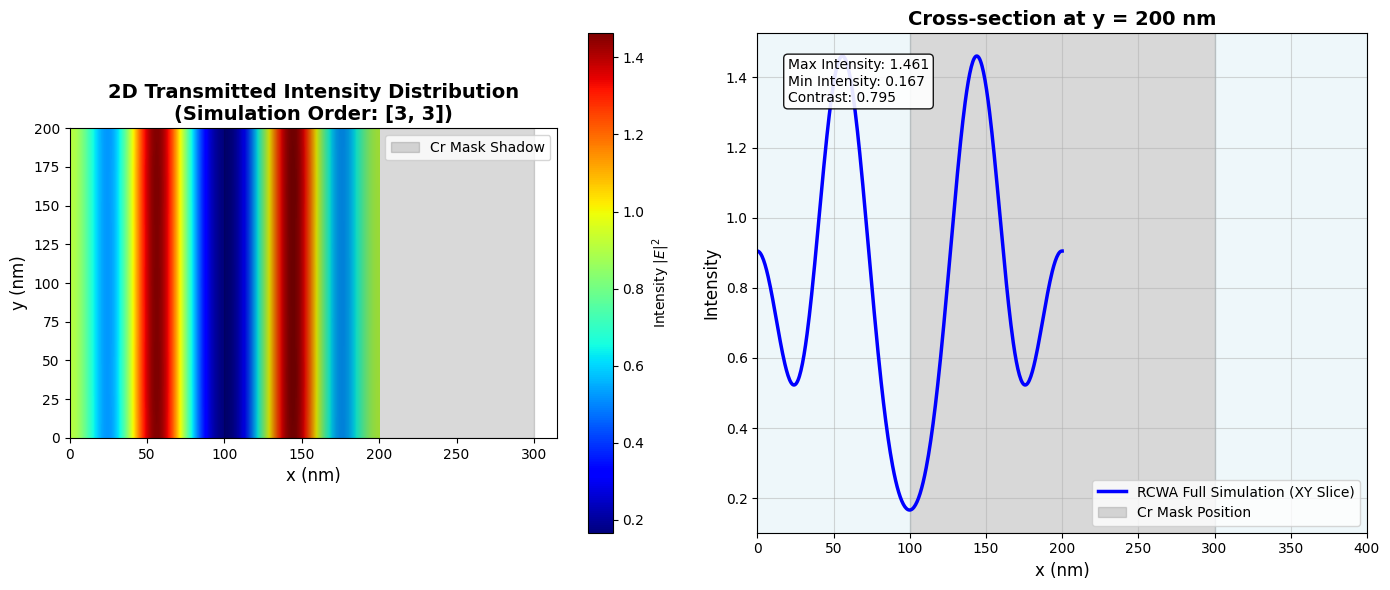

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torcwa

# ==================== 1. 基礎設定與幾何定義 ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype_c = torch.complex64
dtype_r = torch.float32

# 物理參數
lamb0 = torch.tensor(193.0, dtype=dtype_r, device=device)
L = [400.0, 400.0]  # Unit Cell 大小 (nm)
grating_period = L[0]

# 設定 Torcwa 幾何
torcwa.rcwa_geo.dtype = dtype_r
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800
torcwa.rcwa_geo.ny = 800
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.0

# 定義結構: 中間是 Cr (遮光), 兩側是 Air (透光)
# Air(0-100) - Cr(100-300) - Air(300-400)
# 對應中心位置為 200nm, 寬度 200nm 的 Cr Block
center_cr_block = torcwa.rcwa_geo.rectangle(Wx=L[0]/2, Wy=L[1], Cx=L[0]/2, Cy=L[1]/2)

# 材料介電常數
Cr_eps = (0.842 + 1j*1.647)**2
air_eps = 1.0 + 0j
SiO2_eps = (1.563 + 1j*0.0)**2

# 建構層介電常數分佈
Cr_layer_eps = center_cr_block * Cr_eps + (1.0 - center_cr_block) * air_eps

# ==================== 2. RCWA 模擬求解 ====================
# order=[3,3] 表示我們會計算 -3 到 +3 的繞射級數，比單純 I01 更精確
sim = torcwa.rcwa(freq=1/lamb0, order=[3, 3], L=L, dtype=dtype_c, device=device)
sim.add_input_layer(eps=SiO2_eps, mu=1.)
sim.set_incident_angle(inc_ang=0.0, azi_ang=0.0) # 垂直入射
sim.add_layer(thickness=70.0, eps=Cr_layer_eps) # Cr Mask 層

sim.solve_global_smatrix()

# 設定光源 (X偏振平面波)
sim.source_planewave(amplitude=[1., 0.], direction='forward')

# ==================== 3. 計算 2D XY 平面場分佈 (核心函式) ====================

def calculate_2d_field_xy(sim, x_points, y_points):
    """
    根據 RCWA 求解的 S 矩陣，重建透射側 (Transmission) 的 2D 光場。
    原理：將所有透射繞射級數 (Plane waves) 在空間中疊加。
    """
    # 1. 取得透射係數 (Transmission Coefficients)
    # sim.S[0] 是全域 S 矩陣中的透射部分 (Source -> Transmission)
    # E_trans_coeffs = S_trans @ E_inc
    E_trans_coeffs = torch.matmul(sim.S[0], sim.E_i)
    
    # 2. 準備空間網格
    X, Y = torch.meshgrid(x_points, y_points, indexing='xy')
    
    # 3. 初始化場分量
    Ex_field = torch.zeros_like(X, dtype=torch.complex64)
    Ey_field = torch.zeros_like(X, dtype=torch.complex64)
    Ez_field = torch.zeros_like(X, dtype=torch.complex64)
    
    # 4. 取得輸出層的折射率與 Kz (用於計算 Ez)
    eps_out = sim.eps_out if hasattr(sim, 'eps_out') else 1.0
    mu_out = sim.mu_out if hasattr(sim, 'mu_out') else 1.0
    
    # 5. 疊加所有繞射級數 (Summation of Plane Waves)
    # E(x,y) = sum( C_mn * exp(i(kx*x + ky*y)) )
    
    order_N = sim.order_N # 總級數數量
    
    # E_trans_coeffs 是一個向量，前 order_N 個是 Ex 分量，後 order_N 個是 Ey 分量
    Ex_coeffs = E_trans_coeffs[:order_N, 0]
    Ey_coeffs = E_trans_coeffs[order_N:, 0]
    
    for i in range(order_N):
        # 取得該級數的 Kx, Ky (normalized)
        kx_norm = sim.Kx_norm[i, i]
        ky_norm = sim.Ky_norm[i, i]
        
        # 計算實際波向量 k = k_norm * k0
        k0 = 2 * np.pi * sim.freq
        kx = kx_norm * k0
        ky = ky_norm * k0
        
        # 計算平面波相位因子
        phase_factor = torch.exp(1j * (kx * X + ky * Y))
        
        # 疊加 Ex, Ey
        Ex_field += Ex_coeffs[i] * phase_factor
        Ey_field += Ey_coeffs[i] * phase_factor
        
        # 計算 Ez (根據散度條件 div(E)=0 => kx*Ex + ky*Ey + kz*Ez = 0)
        # kz_norm = sqrt(eps*mu - kx^2 - ky^2)
        kz_sq = eps_out * mu_out - kx_norm**2 - ky_norm**2
        # 注意：若為衰減波，kz 為虛數，這裡我們取透射側傳播的主分量
        kz_norm = torch.sqrt(kz_sq) 
        if kz_sq.real < 0: # 修正虛部符號
             kz_norm = 1j * torch.sqrt(-kz_sq)

        # 避免除以零 (當 kz=0)
        if torch.abs(kz_norm) > 1e-6:
             Ez_val = -(kx_norm * Ex_coeffs[i] + ky_norm * Ey_coeffs[i]) / kz_norm
             Ez_field += Ez_val * phase_factor

    return Ex_field, Ey_field, Ez_field

print("正在計算 2D 場分佈...")
# 定義高解析度網格用於繪圖
x_vis = torch.linspace(0, L[0], 400, device=device)
y_vis = torch.linspace(0, L[1], 400, device=device)

Ex, Ey, Ez = calculate_2d_field_xy(sim, x_vis, y_vis)

# 計算總光強 Intensity = |Ex|^2 + |Ey|^2 + |Ez|^2
Intensity_2D = (torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2).cpu().numpy()
X_vis = x_vis.cpu().numpy()
Y_vis = y_vis.cpu().numpy()

# ==================== 4. 視覺化結果 ====================
fig = plt.figure(figsize=(14, 6))

# --- Plot 1: 2D Intensity Map (Heatmap) ---
ax1 = fig.add_subplot(1, 2, 1)
extent = [0, L[0], 0, L[1]]
im = ax1.imshow(Intensity_2D, extent=extent, origin='lower', cmap='jet', aspect='equal')
ax1.set_title(f'2D Transmitted Intensity Distribution\n(Simulation Order: {sim.order})', fontsize=14, fontweight='bold')
ax1.set_xlabel('x (nm)', fontsize=12)
ax1.set_ylabel('y (nm)', fontsize=12)

# 疊加結構示意 (半透明)
# Cr 區域在 x=[100, 300]
ax1.axvspan(100, 300, color='black', alpha=0.15, label='Cr Mask Shadow')
ax1.legend(loc='upper right')
fig.colorbar(im, ax=ax1, label='Intensity $|E|^2$')


# --- Plot 2: Cross-section Comparison (1D Slice) ---
# 取 y = L/2 處的切片，這應該要跟上一題的一維公式結果非常接近
mid_y_idx = int(len(y_vis)/2)
I_slice = Intensity_2D[mid_y_idx, :]

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(X_vis, I_slice, 'b-', linewidth=2.5, label='RCWA Full Simulation (XY Slice)')

# 繪製遮罩區域提示
ax2.axvspan(100, 300, color='gray', alpha=0.3, label='Cr Mask Position')
ax2.axvspan(0, 100, color='lightblue', alpha=0.2)
ax2.axvspan(300, 400, color='lightblue', alpha=0.2)

# 標註極值
max_I = np.max(I_slice)
min_I = np.min(I_slice)
contrast = (max_I - min_I) / (max_I + min_I)

ax2.set_title('Cross-section at y = 200 nm', fontsize=14, fontweight='bold')
ax2.set_xlabel('x (nm)', fontsize=12)
ax2.set_ylabel('Intensity', fontsize=12)
ax2.set_xlim(0, 400)
ax2.grid(True, alpha=0.5)

# 顯示統計數據
info_text = (
    f"Max Intensity: {max_I:.3f}\n"
    f"Min Intensity: {min_I:.3f}\n"
    f"Contrast: {contrast:.3f}"
)
ax2.text(0.05, 0.95, info_text, transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

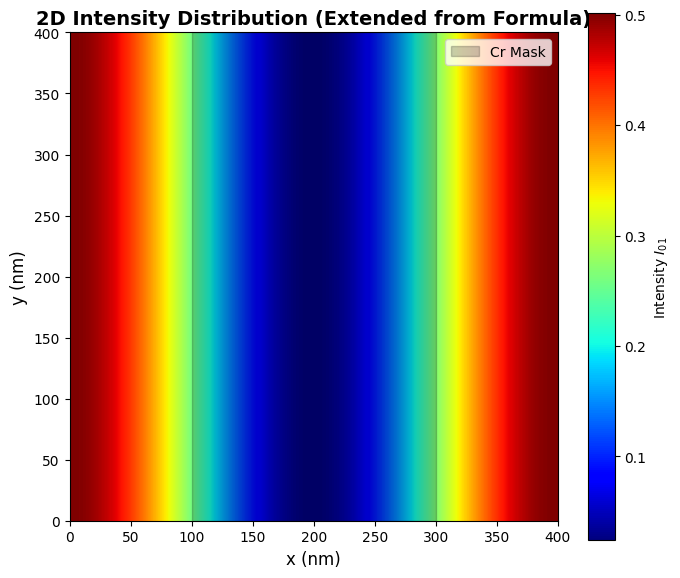

In [63]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torcwa

# ==================== 1. 模擬設定 (保持原本設定) ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype_r = torch.float32
dtype_c = torch.complex64

lamb0 = torch.tensor(193.0, dtype=dtype_r, device=device)
L = [400.0, 400.0] 
grating_period = L[0]

# 幾何
torcwa.rcwa_geo.dtype = dtype_r
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800
torcwa.rcwa_geo.ny = 800
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.0

center_cr_block = torcwa.rcwa_geo.rectangle(Wx=L[0]/2, Wy=L[1], Cx=L[0]/2, Cy=L[1]/2)
Cr_eps = (0.842 + 1j*1.647)**2
air_eps = 1.0
SiO2_eps = (1.563 + 1j*0.0)**2
Cr_layer_eps = center_cr_block * Cr_eps + (1.0 - center_cr_block) * air_eps

# RCWA 求解
sim = torcwa.rcwa(freq=1/lamb0, order=[3, 3], L=L, dtype=dtype_c, device=device)
sim.add_input_layer(eps=SiO2_eps, mu=1.)
sim.set_incident_angle(inc_ang=0.0, azi_ang=0.0)
sim.add_layer(thickness=70.0, eps=Cr_layer_eps)
sim.solve_global_smatrix()

# ==================== 2. 提取參數 (完全沿用您的公式邏輯) ====================
# 提取 S 參數
S_n = sim.S_parameters(orders=[0, 0], direction='forward', port='transmission', polarization='xx', ref_order=[0,0]).cpu().item()
S_m = sim.S_parameters(orders=[1, 0], direction='forward', port='transmission', polarization='xx', ref_order=[0,0]).cpu().item()

A_n = abs(S_n) 
A_m = abs(S_m) 
phi_n = np.angle(S_n) 
phi_m = np.angle(S_m) 

# ==================== 3. 拓展至 2D 平面 (關鍵步驟) ====================

# 定義 X 與 Y 的座標點
nx_plot = 500
ny_plot = 500
x = np.linspace(0, grating_period, nx_plot)
y = np.linspace(0, L[1], ny_plot)

# 計算一維強度 (I_1D)
DC_term = A_n**2 + A_m**2 
AC_term_coeff = 2 * A_n * A_m 
spatial_freq = (1 - 0) * 2 * np.pi / grating_period
phase_diff = phi_m - phi_n 
I_1D = DC_term + AC_term_coeff * np.cos(spatial_freq * x + phase_diff)

# 將 1D 數據拓展成 2D 矩陣
# np.tile(array, (Y方向重複次數, X方向重複次數))
I_2D = np.tile(I_1D, (ny_plot, 1))

# ==================== 4. 視覺化 ====================
plt.figure(figsize=(7, 6))

# 使用 imshow 繪製熱圖
# extent=[x_min, x_max, y_min, y_max] 確保座標軸數值正確
plt.imshow(I_2D, extent=[0, L[0], 0, L[1]], origin='lower', cmap='jet', aspect='equal')

plt.title('2D Intensity Distribution (Extended from Formula)', fontsize=14, fontweight='bold')
plt.xlabel('x (nm)', fontsize=12)
plt.ylabel('y (nm)', fontsize=12)
plt.colorbar(label='Intensity $I_{01}$')

# 標示結構位置 (半透明遮罩)
plt.axvspan(100,300, color='black', alpha=0.2, label='Cr Mask')
plt.legend(loc='upper right')
plt.xlim(0, 400)
plt.tight_layout()
plt.show()



In [7]:
import torch
import warnings
import torcwa # 確保有匯入 torcwa

def field_xy_propagating_only(self, layer_num, x_axis, y_axis, z_prop=0.):
    '''
    XY-plane field distribution at the selected layer (Propagating Waves ONLY).
    Filters out evanescent waves/modes by checking the imaginary part of kz.
    Dynamically added to torcwa class.
    '''

    if type(layer_num) != int:
        warnings.warn('Parameter "layer_num" must be int type. Return None.',UserWarning)
        return None

    if layer_num < -1 or layer_num > self.layer_N:
        warnings.warn('Layer number is out of range. Return None.',UserWarning)
        return None

    if type(x_axis) != torch.Tensor or type(y_axis) != torch.Tensor:
        warnings.warn('x and y axis must be torch.Tensor type. Return None.',UserWarning)
        return None
    
    # 定義判定衰減波的閾值
    EVANESCENT_TOL = 1e-5
    
    # [x, y, diffraction order]
    x_axis = x_axis.reshape([-1,1,1])
    y_axis = y_axis.reshape([1,-1,1])

    Kx_norm, Ky_norm = self.Kx_norm, self.Ky_norm

    # --- Case 1: Input and Output Layers (Homogeneous) ---
    if layer_num == -1 or layer_num == self.layer_N:
        Kx_norm_dn, Ky_norm_dn = self.Kx_norm_dn, self.Ky_norm_dn

        if layer_num == -1:
            z_prop = z_prop if z_prop <= 0. else 0.
            eps = self.eps_in if hasattr(self,'eps_in') else 1.
            mu = self.mu_in if hasattr(self,'mu_in') else 1.
            Vi = self.Vi if hasattr(self,'Vi') else self.Vf
            Kz_norm_dn = torch.sqrt(eps*mu - Kx_norm_dn**2 - Ky_norm_dn**2)
            Kz_norm_dn = torch.where(torch.imag(Kz_norm_dn)>0,torch.conj(Kz_norm_dn),Kz_norm_dn).reshape([-1,1])
        elif layer_num == self.layer_N:
            z_prop = z_prop if z_prop >= 0. else 0.
            eps = self.eps_out if hasattr(self,'eps_in') else 1.
            mu = self.mu_out if hasattr(self,'mu_in') else 1.        
            Vo = self.Vo if hasattr(self,'Vo') else self.Vf
            Kz_norm_dn = torch.sqrt(eps*mu - Kx_norm_dn**2 - Ky_norm_dn**2)
            Kz_norm_dn = torch.where(torch.imag(Kz_norm_dn)<0,torch.conj(Kz_norm_dn),Kz_norm_dn).reshape([-1,1])

        # Phase Calculation with Filter
        Kz_norm_dn = torch.vstack((Kz_norm_dn,Kz_norm_dn))
        
        # [FILTER]: 建立傳播波遮罩 (Homogeneous Mask)
        # 檢查 Kz 的虛部，若接近 0 則視為傳播波 (mask=1)，否則為衰減波 (mask=0)
        is_propagating = (torch.abs(torch.imag(Kz_norm_dn)) < EVANESCENT_TOL).float()
        
        # 將遮罩應用於相位因子
        z_phase = torch.exp(1.j*self.omega*Kz_norm_dn*z_prop) * is_propagating
        
        # Fourier domain fields
        # [diffraction order, diffraction order]
        if layer_num == -1 and self.source_direction == 'forward':
            Exy_p = self.E_i*z_phase
            Hxy_p = torch.matmul(Vi,Exy_p)
            Exy_m = torch.matmul(self.S[1],self.E_i)*torch.conj(z_phase)
            Hxy_m = torch.matmul(-Vi,Exy_m)
        elif layer_num == -1 and self.source_direction == 'backward':
            Exy_p = torch.zeros_like(self.E_i)
            Hxy_p = torch.zeros_like(self.E_i)
            Exy_m = torch.matmul(self.S[3],self.E_i)*torch.conj(z_phase)
            Hxy_m = torch.matmul(-Vi,Exy_m)
        elif layer_num == self.layer_N and self.source_direction == 'forward':
            Exy_p = torch.matmul(self.S[0],self.E_i)*z_phase
            Hxy_p = torch.matmul(Vo,Exy_p)
            Exy_m = torch.zeros_like(self.E_i)
            Hxy_m = torch.zeros_like(self.E_i)
        elif layer_num == self.layer_N and self.source_direction == 'backward':
            Exy_p = torch.matmul(self.S[2],self.E_i)*z_phase
            Hxy_p = torch.matmul(Vo,Exy_p)
            Exy_m = self.E_i*torch.conj(z_phase)
            Hxy_m = torch.matmul(-Vo,Exy_m)

        Ex_mn = Exy_p[:self.order_N] + Exy_m[:self.order_N]
        Ey_mn = Exy_p[self.order_N:] + Exy_m[self.order_N:]
        Hz_mn = torch.matmul(Kx_norm,Ey_mn)/mu - torch.matmul(Ky_norm,Ex_mn)/mu
        Hx_mn = Hxy_p[:self.order_N] + Hxy_m[:self.order_N]
        Hy_mn = Hxy_p[self.order_N:] + Hxy_m[self.order_N:]
        Ez_mn = torch.matmul(Ky_norm,Hx_mn)/eps - torch.matmul(Kx_norm,Hy_mn)/eps

        # Spatial domain fields
        xy_phase = torch.exp(1.j * self.omega * (self.Kx_norm_dn*x_axis + self.Ky_norm_dn*y_axis))
        Ex = torch.sum(Ex_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Ey = torch.sum(Ey_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Ez = torch.sum(Ez_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Hx = torch.sum(Hx_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Hy = torch.sum(Hy_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Hz = torch.sum(Hz_mn.reshape(1,1,-1)*xy_phase,dim=2)

    # --- Case 2: Internal Layers (Grating) ---
    else:
        if self.source_direction == 'forward':
            C = torch.matmul(self.C[0][layer_num],self.E_i)
        elif self.source_direction == 'backward':
            C = torch.matmul(self.C[1][layer_num],self.E_i)

        kz_norm = self.kz_norm[layer_num]
        E_eigvec = self.E_eigvec[layer_num]
        H_eigvec = self.H_eigvec[layer_num]

        Cp = torch.diag(C[:2*self.order_N,0])
        Cm = torch.diag(C[2*self.order_N:,0])

        eps_conv_inv = torch.linalg.inv(self.eps_conv[layer_num])
        mu_conv_inv = torch.linalg.inv(self.mu_conv[layer_num])

        # [FILTER]: 建立模態傳播遮罩 (Modal Mask)
        # 檢查該層特徵值 (Eigenvalues) 的虛部
        is_prop_mode = (torch.abs(torch.imag(kz_norm)) < EVANESCENT_TOL).float()

        # Phase Calculation with Filter
        # 將遮罩應用於對角矩陣生成過程中，過濾掉衰減模態
        z_phase_p = torch.diag(torch.exp(1.j*self.omega*kz_norm*z_prop) * is_prop_mode)
        z_phase_m = torch.diag(torch.exp(1.j*self.omega*kz_norm*(self.thickness[layer_num]-z_prop)) * is_prop_mode)

        # Fourier domain fields
        # [diffraction order, eigenmode number]
        Exy_p = torch.matmul(E_eigvec,z_phase_p)
        Ex_p = Exy_p[:self.order_N,:]
        Ey_p = Exy_p[self.order_N:,:]
        Hz_p = torch.matmul(mu_conv_inv,torch.matmul(Kx_norm,Ey_p)) - torch.matmul(mu_conv_inv,torch.matmul(Ky_norm,Ex_p))
        Exy_m = torch.matmul(E_eigvec,z_phase_m)
        Ex_m = Exy_m[:self.order_N,:]
        Ey_m = Exy_m[self.order_N:,:]
        Hz_m = torch.matmul(mu_conv_inv,torch.matmul(Kx_norm,Ey_m)) - torch.matmul(mu_conv_inv,torch.matmul(Ky_norm,Ex_m))
        Hxy_p = torch.matmul(H_eigvec,z_phase_p)
        Hx_p = Hxy_p[:self.order_N,:]
        Hy_p = Hxy_p[self.order_N:,:]
        Ez_p = torch.matmul(eps_conv_inv,torch.matmul(Ky_norm,Hx_p)) - torch.matmul(eps_conv_inv,torch.matmul(Kx_norm,Hy_p))
        Hxy_m = torch.matmul(-H_eigvec,z_phase_m)
        Hx_m = Hxy_m[:self.order_N,:]
        Hy_m = Hxy_m[self.order_N:,:]
        Ez_m = torch.matmul(eps_conv_inv,torch.matmul(Ky_norm,Hx_m)) - torch.matmul(eps_conv_inv,torch.matmul(Kx_norm,Hy_m))
        
        Ex_mn = torch.sum(torch.matmul(Ex_p,Cp) + torch.matmul(Ex_m,Cm),dim=1)
        Ey_mn = torch.sum(torch.matmul(Ey_p,Cp) + torch.matmul(Ey_m,Cm),dim=1)
        Ez_mn = torch.sum(torch.matmul(Ez_p,Cp) + torch.matmul(Ez_m,Cm),dim=1)
        Hx_mn = torch.sum(torch.matmul(Hx_p,Cp) + torch.matmul(Hx_m,Cm),dim=1)
        Hy_mn = torch.sum(torch.matmul(Hy_p,Cp) + torch.matmul(Hy_m,Cm),dim=1)
        Hz_mn = torch.sum(torch.matmul(Hz_p,Cp) + torch.matmul(Hz_m,Cm),dim=1)

        # Spatial domain fields
        xy_phase = torch.exp(1.j * self.omega * (self.Kx_norm_dn*x_axis + self.Ky_norm_dn*y_axis))
        Ex = torch.sum(Ex_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Ey = torch.sum(Ey_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Ez = torch.sum(Ez_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Hx = torch.sum(Hx_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Hy = torch.sum(Hy_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Hz = torch.sum(Hz_mn.reshape(1,1,-1)*xy_phase,dim=2)

    return [Ex, Ey, Ez], [Hx, Hy, Hz]

# ==========================================
# 步驟：將新函式掛載到 torcwa.rcwa 類別中
# ==========================================
torcwa.rcwa.field_xy_propagating_only = field_xy_propagating_only

print(hasattr(sim, 'field_xy_propagating_only'))  # 應顯示 True
print(type(sim.field_xy_propagating_only))  # 應顯示 <class 'method'>

True
<class 'method'>


已掛載新函式: field_xy_propagating_only
正在執行 RCWA 求解...
正在計算二維強度分布 (Propagating Only)...


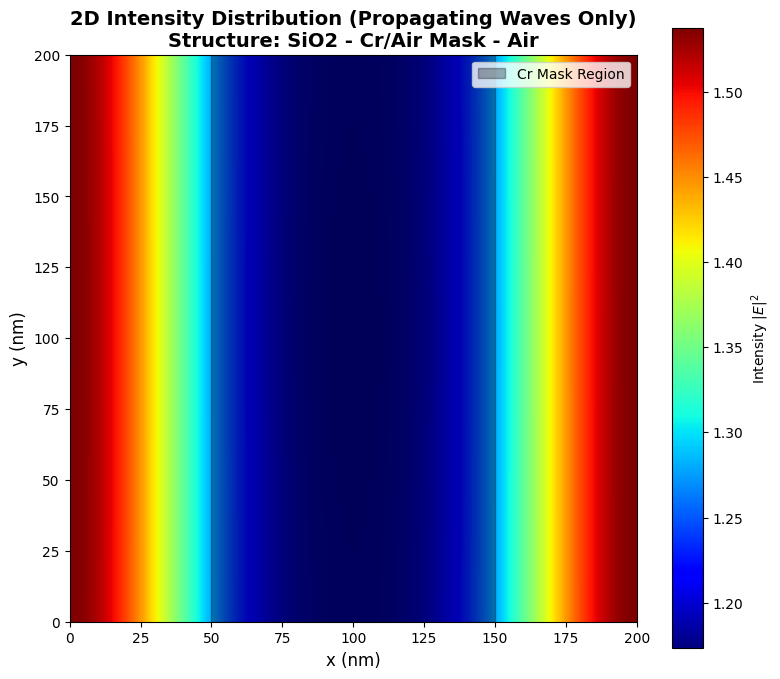

最大強度: 1.5374
最小強度: 1.1732
1


In [71]:
# ==================== 1. 匯入模組與定義新函式 ====================
import numpy as np
import torch
import matplotlib.pyplot as plt
import torcwa
import warnings

# 定義新函式：field_xy_propagating_only
# 功能：計算 XY 平面場分布，並自動過濾衰減波成分
def field_xy_propagating_only(self, layer_num, x_axis, y_axis, z_prop=0.):
    if type(layer_num) != int:
        warnings.warn('Parameter "layer_num" must be int type.', UserWarning)
        return None
    
    # 閾值：判定是否為衰減波
    EVANESCENT_TOL = 1e-5
    
    # 調整座標維度以利廣播運算
    x_axis = x_axis.reshape([-1,1,1])
    y_axis = y_axis.reshape([1,-1,1])

    Kx_norm, Ky_norm = self.Kx_norm, self.Ky_norm

    # --- 情況 A: 均勻層 (輸入/輸出層) ---
    if layer_num == -1 or layer_num == self.layer_N:
        Kx_norm_dn, Ky_norm_dn = self.Kx_norm_dn, self.Ky_norm_dn

        if layer_num == -1:
            z_prop = z_prop if z_prop <= 0. else 0.
            eps = self.eps_in if hasattr(self,'eps_in') else 1.
            mu = self.mu_in if hasattr(self,'mu_in') else 1.
            Vi = self.Vi if hasattr(self,'Vi') else self.Vf
            Kz_norm_dn = torch.sqrt(eps*mu - Kx_norm_dn**2 - Ky_norm_dn**2)
            Kz_norm_dn = torch.where(torch.imag(Kz_norm_dn)>0, torch.conj(Kz_norm_dn), Kz_norm_dn).reshape([-1,1])
        elif layer_num == self.layer_N:
            z_prop = z_prop if z_prop >= 0. else 0.
            eps = self.eps_out if hasattr(self,'eps_in') else 1.
            mu = self.mu_out if hasattr(self,'mu_in') else 1.        
            Vo = self.Vo if hasattr(self,'Vo') else self.Vf
            Kz_norm_dn = torch.sqrt(eps*mu - Kx_norm_dn**2 - Ky_norm_dn**2)
            Kz_norm_dn = torch.where(torch.imag(Kz_norm_dn)<0, torch.conj(Kz_norm_dn), Kz_norm_dn).reshape([-1,1])

        # [FILTER] 建立傳播波遮罩
        Kz_norm_dn = torch.vstack((Kz_norm_dn, Kz_norm_dn))
        is_propagating = (torch.abs(torch.imag(Kz_norm_dn)) < EVANESCENT_TOL).float()
        
        # 應用遮罩於相位因子
        z_phase = torch.exp(1.j*self.omega*Kz_norm_dn*z_prop) * is_propagating
        
        # 計算傅立葉域場
        if layer_num == self.layer_N and self.source_direction == 'forward':
            Exy_p = torch.matmul(self.S[0], self.E_i) * z_phase
            Hxy_p = torch.matmul(Vo, Exy_p)
            Exy_m = torch.zeros_like(self.E_i)
            Hxy_m = torch.zeros_like(self.E_i)
        elif layer_num == -1 and self.source_direction == 'forward': # 反射區
             Exy_p = self.E_i * z_phase
             Hxy_p = torch.matmul(Vi, Exy_p)
             Exy_m = torch.matmul(self.S[1], self.E_i) * torch.conj(z_phase)
             Hxy_m = torch.matmul(-Vi, Exy_m)
        else: # 其他情況簡化處理
             Exy_p = torch.zeros_like(self.E_i)
             Hxy_p = torch.zeros_like(self.E_i)
             Exy_m = torch.zeros_like(self.E_i)
             Hxy_m = torch.zeros_like(self.E_i)

        Ex_mn = Exy_p[:self.order_N] + Exy_m[:self.order_N]
        Ey_mn = Exy_p[self.order_N:] + Exy_m[self.order_N:]
        Hz_mn = torch.matmul(Kx_norm, Ey_mn)/mu - torch.matmul(Ky_norm, Ex_mn)/mu
        Hx_mn = Hxy_p[:self.order_N] + Hxy_m[:self.order_N]
        Hy_mn = Hxy_p[self.order_N:] + Hxy_m[self.order_N:]
        Ez_mn = torch.matmul(Ky_norm, Hx_mn)/eps - torch.matmul(Kx_norm, Hy_mn)/eps

        # 空間域重建
        xy_phase = torch.exp(1.j * self.omega * (self.Kx_norm_dn*x_axis + self.Ky_norm_dn*y_axis))
        Ex = torch.sum(Ex_mn.reshape(1,1,-1)*xy_phase, dim=2)
        Ey = torch.sum(Ey_mn.reshape(1,1,-1)*xy_phase, dim=2)
        Ez = torch.sum(Ez_mn.reshape(1,1,-1)*xy_phase, dim=2)
        Hx = torch.sum(Hx_mn.reshape(1,1,-1)*xy_phase, dim=2)
        Hy = torch.sum(Hy_mn.reshape(1,1,-1)*xy_phase, dim=2)
        Hz = torch.sum(Hz_mn.reshape(1,1,-1)*xy_phase, dim=2)

    # --- 情況 B: 內部光柵層 (省略以簡化，因為此模擬只看 Output) ---
    else:
        if self.source_direction == 'forward':
            C = torch.matmul(self.C[0][layer_num],self.E_i)
        elif self.source_direction == 'backward':
            C = torch.matmul(self.C[1][layer_num],self.E_i)

        kz_norm = self.kz_norm[layer_num]
        E_eigvec = self.E_eigvec[layer_num]
        H_eigvec = self.H_eigvec[layer_num]

        Cp = torch.diag(C[:2*self.order_N,0])
        Cm = torch.diag(C[2*self.order_N:,0])

        eps_conv_inv = torch.linalg.inv(self.eps_conv[layer_num])
        mu_conv_inv = torch.linalg.inv(self.mu_conv[layer_num])

        # [FILTER]: 建立模態傳播遮罩 (Modal Mask)
        # 檢查該層特徵值 (Eigenvalues) 的虛部
        is_prop_mode = (torch.abs(torch.imag(kz_norm)) < EVANESCENT_TOL).float()

        # Phase Calculation with Filter
        # 將遮罩應用於對角矩陣生成過程中，過濾掉衰減模態
        z_phase_p = torch.diag(torch.exp(1.j*self.omega*kz_norm*z_prop) * is_prop_mode)
        z_phase_m = torch.diag(torch.exp(1.j*self.omega*kz_norm*(self.thickness[layer_num]-z_prop)) * is_prop_mode)

        # Fourier domain fields
        # [diffraction order, eigenmode number]
        Exy_p = torch.matmul(E_eigvec,z_phase_p)
        Ex_p = Exy_p[:self.order_N,:]
        Ey_p = Exy_p[self.order_N:,:]
        Hz_p = torch.matmul(mu_conv_inv,torch.matmul(Kx_norm,Ey_p)) - torch.matmul(mu_conv_inv,torch.matmul(Ky_norm,Ex_p))
        Exy_m = torch.matmul(E_eigvec,z_phase_m)
        Ex_m = Exy_m[:self.order_N,:]
        Ey_m = Exy_m[self.order_N:,:]
        Hz_m = torch.matmul(mu_conv_inv,torch.matmul(Kx_norm,Ey_m)) - torch.matmul(mu_conv_inv,torch.matmul(Ky_norm,Ex_m))
        Hxy_p = torch.matmul(H_eigvec,z_phase_p)
        Hx_p = Hxy_p[:self.order_N,:]
        Hy_p = Hxy_p[self.order_N:,:]
        Ez_p = torch.matmul(eps_conv_inv,torch.matmul(Ky_norm,Hx_p)) - torch.matmul(eps_conv_inv,torch.matmul(Kx_norm,Hy_p))
        Hxy_m = torch.matmul(-H_eigvec,z_phase_m)
        Hx_m = Hxy_m[:self.order_N,:]
        Hy_m = Hxy_m[self.order_N:,:]
        Ez_m = torch.matmul(eps_conv_inv,torch.matmul(Ky_norm,Hx_m)) - torch.matmul(eps_conv_inv,torch.matmul(Kx_norm,Hy_m))
        
        Ex_mn = torch.sum(torch.matmul(Ex_p,Cp) + torch.matmul(Ex_m,Cm),dim=1)
        Ey_mn = torch.sum(torch.matmul(Ey_p,Cp) + torch.matmul(Ey_m,Cm),dim=1)
        Ez_mn = torch.sum(torch.matmul(Ez_p,Cp) + torch.matmul(Ez_m,Cm),dim=1)
        Hx_mn = torch.sum(torch.matmul(Hx_p,Cp) + torch.matmul(Hx_m,Cm),dim=1)
        Hy_mn = torch.sum(torch.matmul(Hy_p,Cp) + torch.matmul(Hy_m,Cm),dim=1)
        Hz_mn = torch.sum(torch.matmul(Hz_p,Cp) + torch.matmul(Hz_m,Cm),dim=1)

        # Spatial domain fields
        xy_phase = torch.exp(1.j * self.omega * (self.Kx_norm_dn*x_axis + self.Ky_norm_dn*y_axis))
        Ex = torch.sum(Ex_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Ey = torch.sum(Ey_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Ez = torch.sum(Ez_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Hx = torch.sum(Hx_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Hy = torch.sum(Hy_mn.reshape(1,1,-1)*xy_phase,dim=2)
        Hz = torch.sum(Hz_mn.reshape(1,1,-1)*xy_phase,dim=2)


    return [Ex, Ey, Ez], [Hx, Hy, Hz]

# 掛載新函式到 torcwa 類別
torcwa.rcwa.field_xy_propagating_only = field_xy_propagating_only
print("已掛載新函式: field_xy_propagating_only")

# ==================== 2. 模擬環境設定 (與之前一致) ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype_r = torch.float32
dtype_c = torch.complex64

# 參數
lamb0 = torch.tensor(193.0, dtype=dtype_r, device=device)
L = [200.0, 200.0]  # Unit cell
inc_ang = 0.0

# 幾何與網格
torcwa.rcwa_geo.dtype = dtype_r
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800
torcwa.rcwa_geo.ny = 800
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.0

# 結構定義 (SiO2 / Cr-Air / Air)
# 定義 Cr 區塊 (寬100nm，位於中心)
center_block = torcwa.rcwa_geo.rectangle(Wx=L[0]/2, Wy=L[1], Cx=L[0]/2, Cy=L[1]/2)
air_eps = 1.0
Cr_eps = (0.842 + 1j*1.647)**2
SiO2_eps = (1.563 + 1j*0.0)**2
Cr_layer_eps = center_block * Cr_eps + (1.0 - center_block) * air_eps

# 建立 RCWA 模擬物件
order_N = 3
sim = torcwa.rcwa(freq=1/lamb0, order=[order_N, order_N], L=L, dtype=dtype_c, device=device)
sim.add_input_layer(eps=SiO2_eps, mu=1.)
sim.set_incident_angle(inc_ang=inc_ang, azi_ang=0.0)
sim.add_layer(thickness=70.0, eps=Cr_layer_eps)


# 求解與設定光源
print("正在執行 RCWA 求解...")
sim.solve_global_smatrix()
sim.source_planewave(amplitude=[1., 0.], direction='forward') # XX 偏振

# ==================== 3. 執行新函式並視覺化 ====================
print("正在計算二維強度分布 (Propagating Only)...")

# 設定繪圖解析度
nx_vis = 500
ny_vis = 500
x_vis = torch.linspace(0, L[0], nx_vis, device=device)
y_vis = torch.linspace(0, L[1], ny_vis, device=device)

[Ex, Ey, Ez], _ = sim.field_xy_propagating_only(-1, x_vis, y_vis, z_prop=0)

# 計算強度 (Intensity)
# squeeze() 用於移除多餘的維度，使其成為 [nx, ny]0
I_2D = (torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2).squeeze().cpu().numpy()

# 轉置矩陣以符合 imshow 的繪圖座標系 (通常 imshow 預設為 [row, col] 即 [y, x])
I_2D_plot = I_2D.T

# 繪圖
plt.figure(figsize=(8, 7))

# extent 設定對應的物理範圍 [x_min, x_max, y_min, y_max]
extent = [0, L[0], 0, L[1]]

im = plt.imshow(I_2D_plot, extent=extent, origin='lower', cmap='jet', aspect='equal')
plt.colorbar(im, label='Intensity $|E|^2$')

plt.title('2D Intensity Distribution (Propagating Waves Only)\nStructure: SiO2 - Cr/Air Mask - Air', fontsize=14, fontweight='bold')
plt.xlabel('x (nm)', fontsize=12)
plt.ylabel('y (nm)', fontsize=12)

# 標示 Cr 遮罩位置 (半透明黑影)
# 根據定義 center_block: Cx=100, Wx=100 => 範圍 [50, 150]
plt.axvspan(50, 150, color='black', alpha=0.3, label='Cr Mask Region')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"最大強度: {np.max(I_2D_plot):.4f}")
print(f"最小強度: {np.min(I_2D_plot):.4f}")
print(sim.layer_N)


Extracting Diffraction Order Parameters
Order -1: Amplitude=0.2765, Phase=+125.91°
Order +0: Amplitude=0.4317, Phase=+125.08°
Order +1: Amplitude=0.2765, Phase=+126.36°

Calculating Pairwise Interference Patterns
Order -1 & +0: Contrast=0.9083, Max=0.5015, Min=0.0241
Order -1 & +1: Contrast=1.0000, Max=0.3057, Min=0.0000
Order +0 & +1: Contrast=0.9083, Max=0.5015, Min=0.0241

Calculating Total Superposition Intensity
Total Superposition Intensity: Max=0.9695, Min=0.0001
Total Contrast: 0.9999


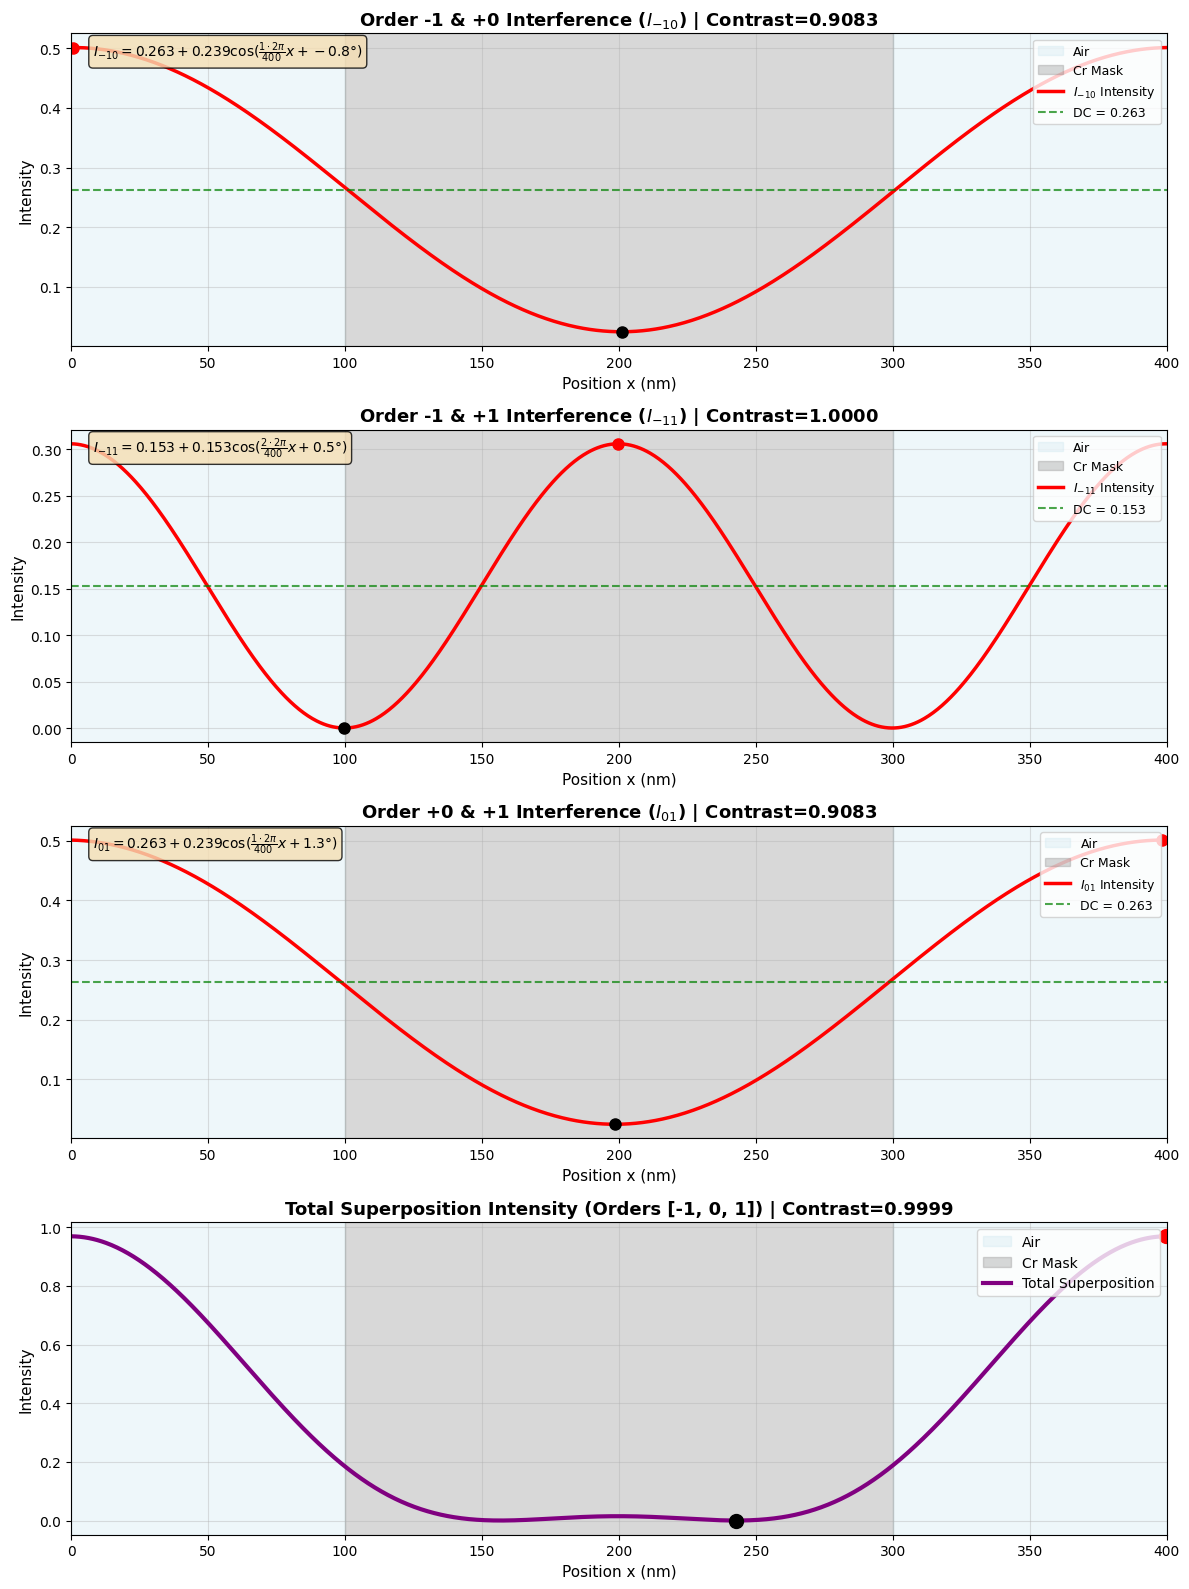


Simulation Results Statistical Summary

Order -1 & +0:
  Maximum Intensity: 0.5015
  Minimum Intensity: 0.0241
  Contrast:          0.9083
  Phase Difference:  -0.84°

Order -1 & +1:
  Maximum Intensity: 0.3057
  Minimum Intensity: 0.0000
  Contrast:          1.0000
  Phase Difference:  0.45°

Order +0 & +1:
  Maximum Intensity: 0.5015
  Minimum Intensity: 0.0241
  Contrast:          0.9083
  Phase Difference:  1.29°

Total Superposition:
  Maximum Intensity: 0.9695
  Minimum Intensity: 0.0001
  Contrast:          0.9999


In [ ]:
'''
DUV光學微影系統 - 通用雙光束干涉計算器
支援任意兩個繞射階數的干涉計算
波長: 193nm, 垂直入射
結構: Air(0-100nm) - Cr(100-300nm) - Air(300-400nm)
'''

# ==================== 匯入與設定 ====================
import numpy as np
import torch
import matplotlib.pyplot as plt
import torcwa
from itertools import combinations

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype_c = torch.complex64
dtype_r = torch.float32

# ==================== User Input ====================
# Input the list of diffraction orders to calculate
ORDER_LIST = [-1,0, 1]  # Can be modified to any orders, e.g., [0, 1, -1], [1, 2], [-2, -1, 0], etc.

# ==================== Parameter Settings ====================
lamb0 = torch.tensor(193.0, dtype=dtype_r, device=device)
L = [400.0, 400.0] 
grating_period = L[0]

# Geometry and Materials
torcwa.rcwa_geo.dtype = dtype_r
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800
torcwa.rcwa_geo.ny = 800
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.0

center_cr_block = torcwa.rcwa_geo.rectangle(Wx=L[0]/2, Wy=L[1], Cx=L[0]/2, Cy=L[1]/2)

Cr_eps = (0.842 + 1j*1.647)**2
air_eps = 1.0
SiO2_eps = (1.563 + 1j*0.0)**2

Cr_layer_eps = center_cr_block * Cr_eps + (1.0 - center_cr_block) * air_eps

# ==================== RCWA 模擬 ====================
sim = torcwa.rcwa(freq=1/lamb0, order=[3, 3], L=L, dtype=dtype_c, device=device)
sim.add_input_layer(eps=SiO2_eps, mu=1.)
sim.set_incident_angle(inc_ang=0.0, azi_ang=0.0)
sim.add_layer(thickness=70.0, eps=Cr_layer_eps)
sim.solve_global_smatrix()

# ==================== 提取所有階數的 S 參數 ====================
print("\n" + "="*80)
print("Extracting Diffraction Order Parameters")
print("="*80)

# Store parameters for all orders
order_params = {}

for order in ORDER_LIST:
    S_param = sim.S_parameters(
        orders=[order, 0], 
        direction='forward', 
        port='transmission', 
        polarization='xx', 
        ref_order=[0,0]
    ).cpu().item()
    
    A = abs(S_param)
    phi = np.angle(S_param)
    
    order_params[order] = {
        'S': S_param,
        'A': A,
        'phi': phi
    }
    
    print(f"Order {order:+2d}: Amplitude={A:.4f}, Phase={np.degrees(phi):+7.2f}°")

# ==================== 計算所有兩兩配對的干涉 ====================
print("\n" + "="*80)
print("Calculating Pairwise Interference Patterns")
print("="*80)

x = np.linspace(0, grating_period, 1000)
interference_patterns = {}
pair_list = list(combinations(ORDER_LIST, 2))

for n, m in pair_list:
    A_n = order_params[n]['A']
    A_m = order_params[m]['A']
    phi_n = order_params[n]['phi']
    phi_m = order_params[m]['phi']
    
    # Calculate according to formula: I_nm = A_n² + A_m² + 2*A_n*A_m*cos((m-n)*2π/p * x + Δφ)
    DC_term = A_n**2 + A_m**2
    AC_coeff = 2 * A_n * A_m
    spatial_freq = (m - n) * 2 * np.pi / grating_period
    phase_diff = phi_m - phi_n
    
    I_nm = DC_term + AC_coeff * np.cos(spatial_freq * x + phase_diff)
    
    interference_patterns[(n, m)] = {
        'intensity': I_nm,
        'DC': DC_term,
        'AC_coeff': AC_coeff,
        'phase_diff': phase_diff,
        'max': np.max(I_nm),
        'min': np.min(I_nm),
        'contrast': (np.max(I_nm) - np.min(I_nm)) / (np.max(I_nm) + np.min(I_nm))
    }
    
    print(f"Order {n:+2d} & {m:+2d}: Contrast={interference_patterns[(n,m)]['contrast']:.4f}, "
          f"Max={np.max(I_nm):.4f}, Min={np.min(I_nm):.4f}")

# ==================== 計算總疊加強度 ====================
print("\n" + "="*80)
print("Calculating Total Superposition Intensity")
print("="*80)

# Method: Sum all electric fields then take magnitude squared
# E_total = Σ A_i * exp(i*(k_i*x + φ_i))
E_total = np.zeros_like(x, dtype=complex)

for order in ORDER_LIST:
    A = order_params[order]['A']
    phi = order_params[order]['phi']
    k = order * 2 * np.pi / grating_period
    
    E_total += A * np.exp(1j * (k * x + phi))

I_total = np.abs(E_total)**2

print(f"Total Superposition Intensity: Max={np.max(I_total):.4f}, Min={np.min(I_total):.4f}")
print(f"Total Contrast: {(np.max(I_total) - np.min(I_total)) / (np.max(I_total) + np.min(I_total)):.4f}")

# ==================== Visualization ====================
num_pairs = len(pair_list)
fig, axes = plt.subplots(num_pairs + 1, 1, figsize=(12, 4*(num_pairs+1)))

if num_pairs == 0:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot each pair's interference pattern
for idx, (n, m) in enumerate(pair_list):
    ax = axes[idx]
    pattern = interference_patterns[(n, m)]
    I_nm = pattern['intensity']
    
    # Structure background
    ax.axvspan(0, 100, color='lightblue', alpha=0.2, label='Air')
    ax.axvspan(100, 300, color='gray', alpha=0.3, label='Cr Mask')
    ax.axvspan(300, 400, color='lightblue', alpha=0.2)
    
    # Plot intensity
    ax.plot(x, I_nm, color='red', linewidth=2.5, label=f'$I_{{{n}{m}}}$ Intensity')
    ax.axhline(y=pattern['DC'], color='green', linestyle='--', alpha=0.7, 
               label=f'DC = {pattern["DC"]:.3f}')
    
    # Mark extrema
    min_idx = np.argmin(I_nm)
    max_idx = np.argmax(I_nm)
    ax.plot(x[min_idx], I_nm[min_idx], 'ko', markersize=8)
    ax.plot(x[max_idx], I_nm[max_idx], 'ro', markersize=8)
    
    ax.set_title(f'Order {n:+d} & {m:+d} Interference ($I_{{{n}{m}}}$) | Contrast={pattern["contrast"]:.4f}', 
                fontsize=13, fontweight='bold')
    ax.set_xlabel('Position x (nm)', fontsize=11)
    ax.set_ylabel('Intensity', fontsize=11)
    ax.set_xlim(0, 400)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.4)
    
    # Display formula
    formula_text = (f"$I_{{{n}{m}}} = {pattern['DC']:.3f} + "
                   f"{pattern['AC_coeff']:.3f}\\cos("
                   f"\\frac{{{m-n} \\cdot 2\\pi}}{{400}}x + {np.degrees(pattern['phase_diff']):.1f}°)$")
    ax.text(0.02, 0.98, formula_text, transform=ax.transAxes, 
           fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot total superposition
ax_total = axes[-1]
ax_total.axvspan(0, 100, color='lightblue', alpha=0.2, label='Air')
ax_total.axvspan(100, 300, color='gray', alpha=0.3, label='Cr Mask')
ax_total.axvspan(300, 400, color='lightblue', alpha=0.2)

ax_total.plot(x, I_total, color='purple', linewidth=3, label='Total Superposition')

# Mark extrema
min_idx_total = np.argmin(I_total)
max_idx_total = np.argmax(I_total)
ax_total.plot(x[min_idx_total], I_total[min_idx_total], 'ko', markersize=10)
ax_total.plot(x[max_idx_total], I_total[max_idx_total], 'ro', markersize=10)

ax_total.set_title(f'Total Superposition Intensity (Orders {ORDER_LIST}) | Contrast={(np.max(I_total) - np.min(I_total)) / (np.max(I_total) + np.min(I_total)):.4f}', 
                  fontsize=13, fontweight='bold')
ax_total.set_xlabel('Position x (nm)', fontsize=11)
ax_total.set_ylabel('Intensity', fontsize=11)
ax_total.set_xlim(0, 400)
ax_total.legend(loc='upper right', fontsize=10)
ax_total.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ==================== Output Statistical Summary ====================
print("\n" + "="*80)
print("Simulation Results Statistical Summary")
print("="*80)

for n, m in pair_list:
    pattern = interference_patterns[(n, m)]
    print(f"\nOrder {n:+d} & {m:+d}:")
    print(f"  Maximum Intensity: {pattern['max']:.4f}")
    print(f"  Minimum Intensity: {pattern['min']:.4f}")
    print(f"  Contrast:          {pattern['contrast']:.4f}")
    print(f"  Phase Difference:  {np.degrees(pattern['phase_diff']):.2f}°")

print(f"\nTotal Superposition:")
print(f"  Maximum Intensity: {np.max(I_total):.4f}")
print(f"  Minimum Intensity: {np.min(I_total):.4f}")
print(f"  Contrast:          {(np.max(I_total) - np.min(I_total)) / (np.max(I_total) + np.min(I_total)):.4f}")
print("="*80)


EUV光罩多層結構模擬結果 (torcwa)
波長: 13.5 nm (EUV)
入射角: 6°
晶格常數: 60 nm
RCWA階數: [3, 3]
------------------------------------------------------------
總反射率 R: 0.602176 (60.2176%)
總透射率 T: 0.004581 (0.4581%)
吸收率 A: 0.393243 (39.3243%)


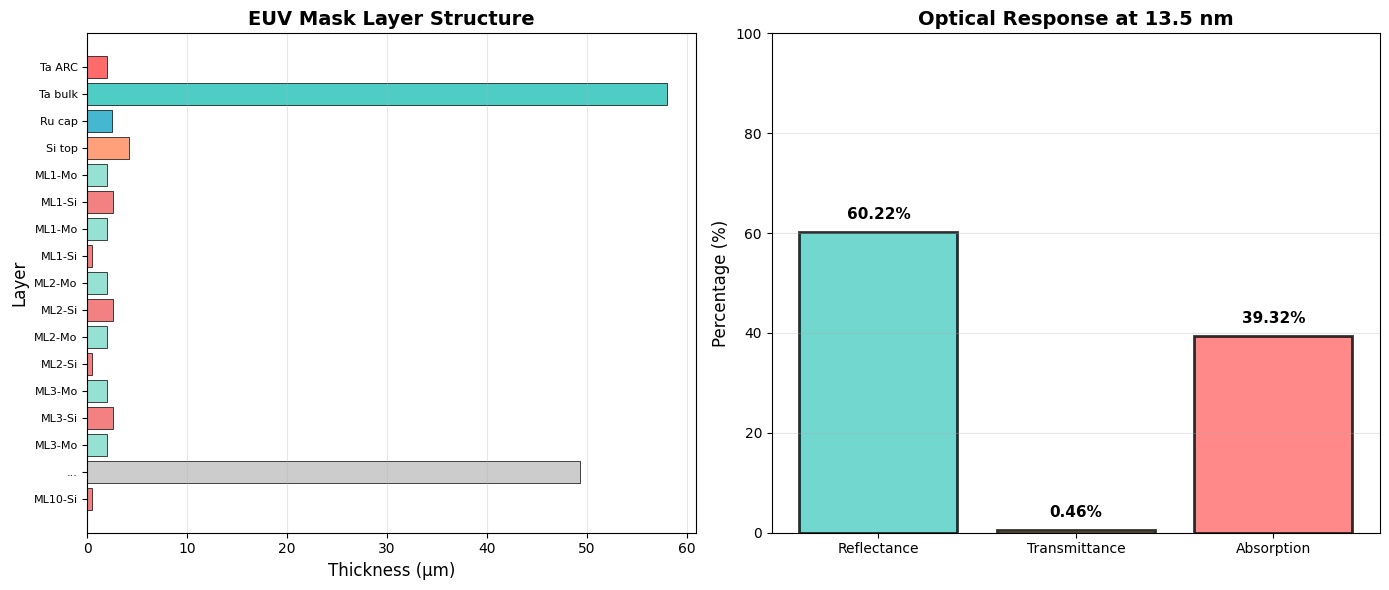


結構圖已保存為 'euv_mask_structure.png'

層結構總結:
  - 基板: 0.97646 - 0.00906i
  - 多層膜: 160層 (40週期 × 4層/週期)
  - 頂層: Si top + Ru cap + Ta bulk + Ta ARC
  - 總厚度: 137.1537 μm
164


In [15]:
import torch
import torcwa
import numpy as np
import matplotlib.pyplot as plt

# 設定設備
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sim_dtype = torch.complex128
geo_dtype = torch.float64

# 基本參數
wavelength = 13.5  # nm
lattice_constant = 60  # nm
theta = 6  # 入射角度 (degrees)
phi = 0  # 方位角

# 轉換角度為弧度
inc_ang = theta * np.pi / 180
azi_ang = phi * np.pi / 180

# 定義40層Mo/Si多層膜結構
multilayer_data = [
    {'n': 0.99932, 'k': 0.00183, 'thickness': 1.986416, 'delta': -0.00068},
    {'n': 0.9693, 'k': 0.004333, 'thickness': 2.5815, 'delta': -0.0307},
    {'n': 0.92108, 'k': 0.00644, 'thickness': 2.006752, 'delta': -0.07892},
    {'n': 0.9693, 'k': 0.00433, 'thickness': 0.473704, 'delta': -0.0307},
]

# 定義頂層結構
mask_stack = {
    'substrate': {'n': 0.97646, 'k': 0.00906, 'thickness': 0.01},  # 基板 (半無限厚)
    'Si_top': {'n': 0.99932, 'k': 0.00183, 'thickness': 4.17},   # Si top
    'Ru_cap': {'n': 0.886358, 'k': 0.0170689, 'thickness': 2.5}, # Ru cap
    'Ta_bulk': {'n': 0.951, 'k': 0.0321, 'thickness': 58},     # Ta bulk
    'Ta_ARC': {'n': 0.952, 'k': 0.0267, 'thickness': 2.0},       # Ta ARC
}


L = [lattice_constant, lattice_constant]
freq = 1 / wavelength
order = [3, 3]  # [order_x, order_y]

# 創建RCWA模擬器
sim = torcwa.rcwa(freq=freq, order=order, L=L, dtype=sim_dtype, device=device)

# 1. 添加基板層 
n_substrate = mask_stack['substrate']['n'] - 1j * mask_stack['substrate']['k']
eps_substrate = n_substrate ** 2

sim.add_output_layer(eps=eps_substrate)

sim.set_incident_angle(inc_ang=inc_ang, azi_ang=azi_ang)

n_ARC = mask_stack['Ta_ARC']['n'] - 1j * mask_stack['Ta_ARC']['k']
eps_ARC = n_ARC ** 2
sim.add_layer(thickness=mask_stack['Ta_ARC']['thickness'], eps=eps_ARC)

n_bulk = mask_stack['Ta_bulk']['n'] - 1j * mask_stack['Ta_bulk']['k']
eps_bulk = n_bulk ** 2
sim.add_layer(thickness=mask_stack['Ta_bulk']['thickness'], eps=eps_bulk)

n_Ru = mask_stack['Ru_cap']['n'] - 1j * mask_stack['Ru_cap']['k']
eps_Ru = n_Ru ** 2
sim.add_layer(thickness=mask_stack['Ru_cap']['thickness'], eps=eps_Ru)

n_Si_top = mask_stack['Si_top']['n'] - 1j * mask_stack['Si_top']['k']
eps_Si_top = n_Si_top ** 2
sim.add_layer(thickness=mask_stack['Si_top']['thickness'], eps=eps_Si_top)
# 2. 添加40層Mo/Si多層膜 (10個週期，每週期4層)
for cycle in range(40):
    for layer_data in multilayer_data:
        n_complex = layer_data['n'] - 1j * layer_data['k']
        eps = n_complex ** 2
        thickness = layer_data['thickness']
        sim.add_layer(thickness=thickness, eps=eps)

# 執行RCWA計算
sim.solve_global_smatrix()

# 獲取反射率和透射率 (0階反射和透射)
# S_parameters(orders, direction, port, polarization, ref_order)
rxx = sim.S_parameters(orders=[0,0], direction='backward', port='reflection', 
                       polarization='xx', ref_order=[0,0])
ryy = sim.S_parameters(orders=[0,0], direction='backward', port='reflection', 
                       polarization='yy', ref_order=[0,0])
txx = sim.S_parameters(orders=[0,0], direction='forward', port='transmission', 
                       polarization='xx', ref_order=[0,0])
tyy = sim.S_parameters(orders=[0,0], direction='forward', port='transmission', 
                       polarization='yy', ref_order=[0,0])

# 計算總反射率和透射率
R = (torch.abs(rxx)**2 + torch.abs(ryy)**2) / 2
T = (torch.abs(txx)**2 + torch.abs(tyy)**2) / 2
A = 1 - R.real - T.real  # 吸收率

print("=" * 60)
print("EUV光罩多層結構模擬結果 (torcwa)")
print("=" * 60)
print(f"波長: {wavelength} nm (EUV)")
print(f"入射角: {theta}°")
print(f"晶格常數: {lattice_constant} nm")
print(f"RCWA階數: {order}")
print("-" * 60)
print(f"總反射率 R: {R.item():.6f} ({R.item()*100:.4f}%)")
print(f"總透射率 T: {T.item():.6f} ({T.item()*100:.4f}%)")
print(f"吸收率 A: {A.item():.6f} ({A.item()*100:.4f}%)")
print("=" * 60)

# 繪製結構示意圖和結果
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 左圖：層結構示意
layer_info = []
layer_info.append(('Ta ARC', mask_stack['Ta_ARC']['thickness'], '#FF6B6B'))
layer_info.append(('Ta bulk', mask_stack['Ta_bulk']['thickness'], '#4ECDC4'))
layer_info.append(('Ru cap', mask_stack['Ru_cap']['thickness'], '#45B7D1'))
layer_info.append(('Si top', mask_stack['Si_top']['thickness'], '#FFA07A'))

for cycle in range(10):
    for i, layer_data in enumerate(multilayer_data):
        material = 'Mo' if i % 2 == 0 else 'Si'
        color = '#95E1D3' if i % 2 == 0 else '#F38181'
        layer_info.append((f'ML{cycle+1}-{material}', layer_data['thickness'], color))

layer_names = [info[0] for info in layer_info]
thicknesses = [info[1] for info in layer_info]
colors = [info[2] for info in layer_info]


display_limit = 15
if len(layer_info) > display_limit:
    display_names = layer_names[:display_limit] + ['...'] + [layer_names[-1]]
    display_thickness = thicknesses[:display_limit] + [sum(thicknesses[display_limit:-1])] + [thicknesses[-1]]
    display_colors = colors[:display_limit] + ['#CCCCCC'] + [colors[-1]]
else:
    display_names = layer_names
    display_thickness = thicknesses
    display_colors = colors

y_pos = np.arange(len(display_thickness))
ax1.barh(y_pos, display_thickness, color=display_colors, edgecolor='black', linewidth=0.5)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(display_names, fontsize=8)
ax1.set_xlabel('Thickness (μm)', fontsize=12)
ax1.set_ylabel('Layer', fontsize=12)
ax1.set_title('EUV Mask Layer Structure', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# 右圖：反射率結果
categories = ['Reflectance', 'Transmittance', 'Absorption']
values = [R.item()*100, T.item()*100, A.item()*100]
result_colors = ['#4ECDC4', '#FFE66D', '#FF6B6B']

bars = ax2.bar(categories, values, color=result_colors, alpha=0.8, 
               edgecolor='black', linewidth=2)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_title(f'Optical Response at {wavelength} nm', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('euv_mask_structure.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n結構圖已保存為 'euv_mask_structure.png'")
print("\n層結構總結:")
print(f"  - 基板: {mask_stack['substrate']['n']:.5f} - {mask_stack['substrate']['k']:.5f}i")
print(f"  - 多層膜: 160層 (40週期 × 4層/週期)")
print(f"  - 頂層: Si top + Ru cap + Ta bulk + Ta ARC")
print(f"  - 總厚度: {sum(thicknesses):.4f} μm")
print(sim.layer_N)



光柵平均填充率 (應為 0.5): 0.500


結構建立完成，開始求解 S 矩陣...



Order (m)  |  Reflectance (%)   |  Amplitude |r|  |   Phase (deg)  
    -3     |       0.0368       |     0.0192      |     -62.96     
    -2     |       0.8819       |     0.0939      |     -73.37     
    -1     |       9.5973       |     0.3098      |     -86.00     
    0      |      10.5458       |     0.3247      |     -112.42    
    1      |       1.1678       |     0.1081      |     -128.19    
    2      |       0.0041       |     0.0064      |     -124.65    
    3      |       0.0042       |     0.0065      |     -15.29     


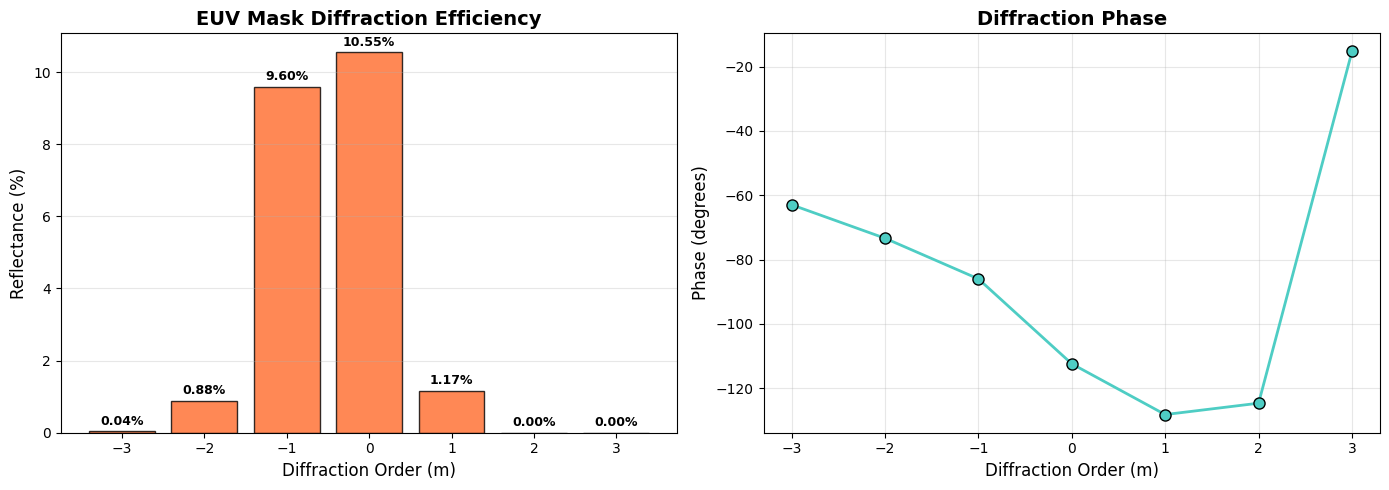


加總反射率 (m=-3~+3): 22.2378%

正在提取穿透光 (Transmission) 資訊...
Order (m)  |  Transmittance (%)   |  Amplitude |t|  |   Phase (deg)  
    -3     |       0.014654       |    0.012105     |      69.58     
    -2     |       0.115642       |    0.034006     |     -37.39     
    -1     |       0.217401       |    0.046626     |     -15.17     
    0      |       0.833163       |    0.091278     |     -55.32     
    1      |       2.468904       |    0.157127     |     -78.00     
    2      |       0.051548       |    0.022704     |      60.13     
    3      |       0.000859       |    0.002930     |     -102.74    


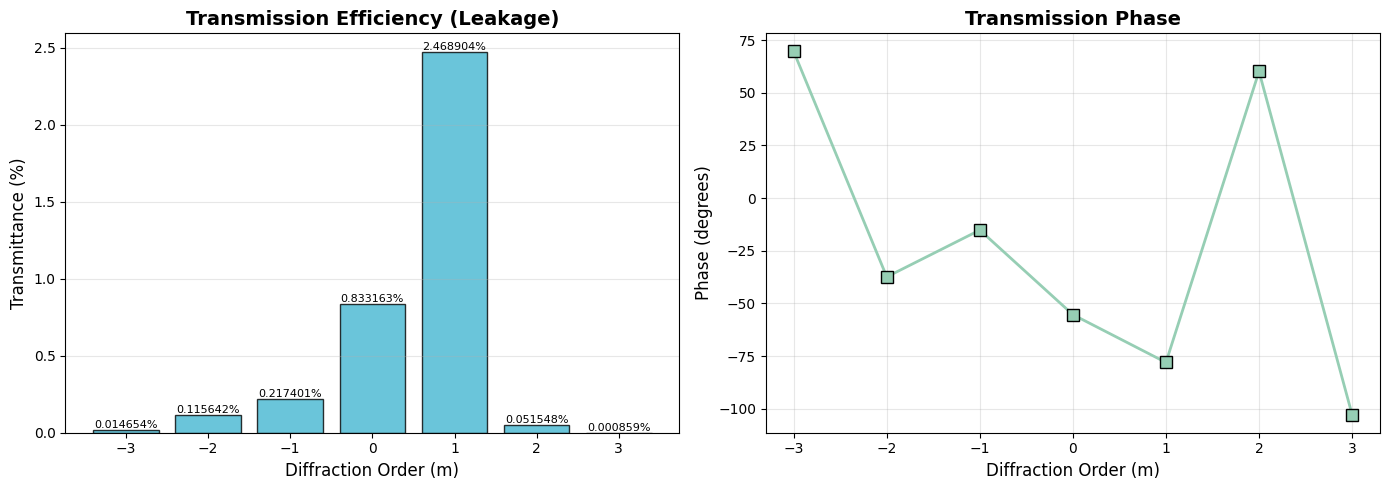


===== 能量分布總結 =====
總反射率 (R): 22.2378%
總穿透率 (T): 3.702171%
總吸收率 (A): 74.0600%


In [91]:
import torch
import torcwa
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sim_dtype = torch.complex128
geo_dtype = torch.float64

# 基本參數
wavelength = 13.5 # nm
lattice_constant = 60  # nm
theta = 6  # 入射角度
phi = 0  # 方位角
inc_ang = theta * np.pi / 180
azi_ang = phi * np.pi / 180

# 40層 Mo/Si 多層膜數據
multilayer_data = [
    {'n': 0.99932, 'k': 0.00183, 'thickness': 1.986416, 'delta': -0.00068},
    {'n': 0.9693, 'k': 0.004333, 'thickness': 2.5815, 'delta': -0.0307},
    {'n': 0.92108, 'k': 0.00644, 'thickness': 2.006752, 'delta': -0.07892},
    {'n': 0.9693, 'k': 0.00433, 'thickness': 0.473704, 'delta': -0.0307},
]


# 頂層結構數據
mask_stack = {
    'substrate': {'n': 0.97646, 'k': 0.00906, 'thickness': 0.01},
    'Si_top': {'n': 0.99932, 'k': 0.00183, 'thickness': 4.17},
    'Ru_cap': {'n': 0.886358, 'k': 0.0170689, 'thickness': 2.5},
    'Ta_bulk': {'n': 0.951, 'k': 0.0321, 'thickness': 58},
    'Ta_ARC': {'n': 0.952, 'k': 0.0267, 'thickness': 2.0},
}



L = [lattice_constant, lattice_constant]
freq = 1 / wavelength

# ==================== 1. 設定一維光柵模擬 ====================

torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800 
torcwa.rcwa_geo.ny = 50 
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.

order_1D = [10, 0] 

sim_grating = torcwa.rcwa(freq=freq, order=order_1D, L=L, dtype=sim_dtype, device=device)
# 1. 添加 Output Layer (基板)
n_sub = mask_stack['substrate']['n'] + 1j * mask_stack['substrate']['k']
eps_substrate = n_sub ** 2
sim_grating.add_output_layer(eps=eps_substrate)
sim_grating.set_incident_angle(inc_ang=inc_ang, azi_ang=azi_ang)

# 2. 定義光柵圖形 (Absorber Pattern)
# Duty Cycle = 0.5 (Line:Space = 1:1)
absorber_pattern = torcwa.rcwa_geo.rectangle(
    Wx=L[0]/2,      # 線寬 30nm
    Wy=L[1],        # Y方向全滿
    Cx=L[0]/2,      # 中心
    Cy=L[1]/2
)
print(f"光柵平均填充率 (應為 0.5): {torch.mean(absorber_pattern).item():.3f}")

# 3. 堆疊圖案化的吸收層 (Ta ARC + Ta Bulk)
# --- Ta ARC 層 (Patterned) ---
n_ARC = mask_stack['Ta_ARC']['n'] + 1j * mask_stack['Ta_ARC']['k']
eps_Ta_ARC = n_ARC ** 2
eps_Air = 1.0 + 0j 
# 混合介電常數: 1=Ta_ARC, 0=Air
eps_layer_Ta_ARC = absorber_pattern * eps_Ta_ARC + (1 - absorber_pattern) * eps_Air
sim_grating.add_layer(thickness=mask_stack['Ta_ARC']['thickness'], eps=eps_layer_Ta_ARC)

# --- Ta Bulk 層 (Patterned) ---
n_bulk = mask_stack['Ta_bulk']['n'] + 1j * mask_stack['Ta_bulk']['k']
eps_Ta_bulk = n_bulk ** 2
# 混合介電常數: 1=Ta_bulk, 0=Air
eps_layer_Ta_bulk = absorber_pattern * eps_Ta_bulk + (1 - absorber_pattern) * eps_Air
sim_grating.add_layer(thickness=mask_stack['Ta_bulk']['thickness'], eps=eps_layer_Ta_bulk)


# 4. 堆疊均勻層 (Ru Cap, Si Top, Multilayer)

# Ru Cap
n_Ru = mask_stack['Ru_cap']['n'] + 1j * mask_stack['Ru_cap']['k']
eps_Ru = n_Ru ** 2
sim_grating.add_layer(thickness=mask_stack['Ru_cap']['thickness'], eps=eps_Ru)

# Si Top
n_Si_top = mask_stack['Si_top']['n'] + 1j * mask_stack['Si_top']['k']
eps_Si_top = n_Si_top ** 2
sim_grating.add_layer(thickness=mask_stack['Si_top']['thickness'], eps=eps_Si_top)

# Mo/Si 多層膜 (40 週期)
for cycle in range(40):
    # [修正 2026/09] 老師提供的參數為 deposit 格式（由基板往上定義），
    # 而 torcwa 的 add_layer() 是由入射面往下加層，因此多層膜單一週期內的子層順序需反轉。
    for layer_data in multilayer_data[::-1]:  # 週期內反轉
        n_complex = layer_data['n'] + 1j * layer_data['k']
        eps = n_complex ** 2
        thickness = layer_data['thickness']
        sim_grating.add_layer(thickness=thickness, eps=eps)


# 5. 執行計算
print("結構建立完成，開始求解 S 矩陣...")
sim_grating.solve_global_smatrix()

# 6. 提取反射光資訊 (+3 到 -3 階)
orders_to_extract = range(-3, 4) # -3, -2, -1, 0, 1, 2, 3

print("\n" + "="*80)
print(f"{'Order (m)':^10} | {'Reflectance (%)':^18} | {'Amplitude |r|':^15} | {'Phase (deg)':^15}")
print("="*80)

reflection_amplitudes = []
reflection_phases = []
orders_list = []
reflectance_values = []

for m in orders_to_extract:
    # y階數固定為 0
    s_param = sim_grating.S_parameters(
        orders=[m, 0], 
        direction='forward', 
        port='reflection', 
        polarization='xx',  
        ref_order=[0, 0]
    )
    
    amp = torch.abs(s_param).item()
    phase_rad = torch.angle(s_param).item()
    phase_deg = np.degrees(phase_rad)
    reflectance = (amp ** 2) * 100 
    
    reflection_amplitudes.append(amp)
    reflection_phases.append(phase_deg)
    reflectance_values.append(reflectance)
    orders_list.append(m)
    
    print(f"{m:^10d} | {reflectance:^18.4f} | {amp:^15.4f} | {phase_deg:^15.2f}")

print("="*80)

# 7. 視覺化結果
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 反射率 (效率) 分布
bars = ax1.bar(orders_list, reflectance_values, color='#FF6B2B', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Diffraction Order (m)', fontsize=12)
ax1.set_ylabel('Reflectance (%)', fontsize=12)
ax1.set_title('EUV Mask Diffraction Efficiency', fontsize=14, fontweight='bold')
ax1.set_xticks(orders_list)
ax1.grid(axis='y', alpha=0.3)

# 標註數值
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 相位分布
ax2.plot(orders_list, reflection_phases, 'o-', color='#4ECDC4', linewidth=2, markersize=8, markeredgecolor='black')
ax2.set_xlabel('Diffraction Order (m)', fontsize=12)
ax2.set_ylabel('Phase (degrees)', fontsize=12)
ax2.set_title('Diffraction Phase', fontsize=14, fontweight='bold')
ax2.set_xticks(orders_list)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 簡單的物理檢查
total_R = sum(reflectance_values)
print(f"\n加總反射率 (m=-3~+3): {total_R:.4f}%")

# ==============================================================================
# [新增功能] 穿透率 (Transmission) 分析模組
# ==============================================================================

print("\n" + "="*80)
print("正在提取穿透光 (Transmission) 資訊...")
print(f"{'Order (m)':^10} | {'Transmittance (%)':^20} | {'Amplitude |t|':^15} | {'Phase (deg)':^15}")
print("="*80)

transmission_amplitudes = []
transmission_phases = []
transmittance_values = []

for m in orders_to_extract:
    s_param_trans = sim_grating.S_parameters(
        orders=[m, 0], 
        direction='forward', 
        port='transmission', 
        polarization='xx',  
        ref_order=[0, 0]
    )
    
    # 計算物理量
    amp_t = torch.abs(s_param_trans).item()
    phase_rad_t = torch.angle(s_param_trans).item()
    phase_deg_t = np.degrees(phase_rad_t)
    
    # 轉換為百分比效率 T = |t|^2 * 100%
    transmittance = (amp_t ** 2) * 100 
    
    # 儲存數據
    transmission_amplitudes.append(amp_t)
    transmission_phases.append(phase_deg_t)
    transmittance_values.append(transmittance)
    
    print(f"{m:^10d} | {transmittance:^20.6f} | {amp_t:^15.6f} | {phase_deg_t:^15.2f}")

print("="*80)

# ==================== 視覺化穿透結果 ====================
fig_t, (ax_t1, ax_t2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. 穿透率 (效率) 分布
bars_t = ax_t1.bar(orders_list, transmittance_values, color='#45B7D1', edgecolor='black', alpha=0.8)
ax_t1.set_xlabel('Diffraction Order (m)', fontsize=12)
ax_t1.set_ylabel('Transmittance (%)', fontsize=12)
ax_t1.set_title('Transmission Efficiency (Leakage)', fontsize=14, fontweight='bold')
ax_t1.set_xticks(orders_list)
ax_t1.grid(axis='y', alpha=0.3)

# 標註數值 
for bar in bars_t:
    height = bar.get_height()
    ax_t1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.6f}%', ha='center', va='bottom', fontsize=8)

# 2. 穿透相位分布
ax_t2.plot(orders_list, transmission_phases, 's-', color='#96CEB4', linewidth=2, markersize=8, markeredgecolor='black')
ax_t2.set_xlabel('Diffraction Order (m)', fontsize=12)
ax_t2.set_ylabel('Phase (degrees)', fontsize=12)
ax_t2.set_title('Transmission Phase', fontsize=14, fontweight='bold')
ax_t2.set_xticks(orders_list)
ax_t2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== 總能量守恆檢查 (Energy Balance) ====================
total_T = sum(transmittance_values)
# 假設入射能量為 100% (total_R 來自您原本的程式變數)
total_Loss = 100.0 - (total_R + total_T) 

print(f"\n===== 能量分布總結 =====")
print(f"總反射率 (R): {total_R:.4f}%")
print(f"總穿透率 (T): {total_T:.6f}%") 
print(f"總吸收率 (A): {total_Loss:.4f}%")
print("========================")

正在掃描反射光譜...


找到峰值波長: 13.57 nm (反射率 61.9%)
目前 13.5 nm 的反射率: 61.2%


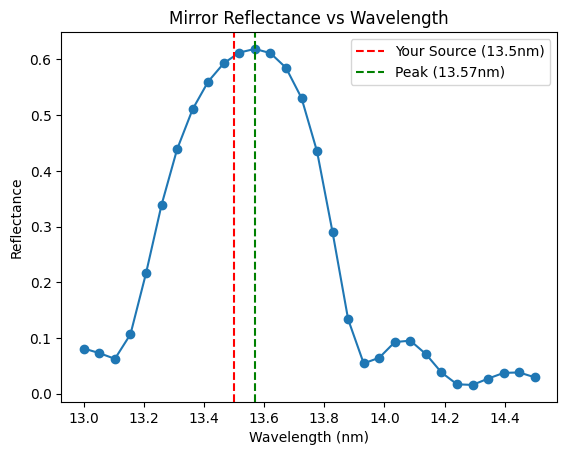

In [101]:
import torch
import torcwa
import numpy as np
import matplotlib.pyplot as plt

# ==================== 快速驗證波長峰值 ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.complex128

# 您的原始厚度數據
multilayer_data = [
    {'n': 0.99932, 'k': 0.00183, 'thickness': 1.986416}, 
    {'n': 0.9693,  'k': 0.004333, 'thickness': 2.5815},  
    {'n': 0.92108, 'k': 0.00644,  'thickness': 2.006752}, 
    {'n': 0.9693,  'k': 0.00433,  'thickness': 0.473704}, 
]

# 掃描 13.0 nm 到 14.5 nm
wavelengths = np.linspace(13.0, 14.5, 30)
reflectances = []

print("正在掃描反射光譜...")

for wl in wavelengths:
    # 建立最簡單的 1x1 模擬 (只測鏡面)
    L = [100, 100]
    freq = 1/wl
    
    # 這裡只用 order=[0,0] 因為是平面鏡
    sim = torcwa.rcwa(freq=freq, order=[0,0], L=L, dtype=dtype, device=device)
    
    # Input
    sim.add_input_layer(eps=1.0)
    sim.add_output_layer(eps=torch.tensor((0.976+1j*0.009)**2, dtype=dtype, device=device))
    sim.set_incident_angle(inc_ang=6.0*np.pi/180, azi_ang=0.0)
    
    # 堆疊 40 層
    for cycle in range(40):
        # [修正 2026/09] 老師提供的參數為 deposit 格式（由基板往上定義），
        # 而 torcwa 的 add_layer() 是由入射面往下加層，因此多層膜單一週期內的子層順序需反轉。
        for layer in multilayer_data[::-1]:  # 週期內反轉
            eps = torch.tensor((layer['n'] + 1j*layer['k'])**2, dtype=dtype, device=device)  # [修正] e^{-iωt} 慣例 → ε = (n + ik)^2
            sim.add_layer(thickness=layer['thickness'], eps=eps)
            
    # Output
    
    
    sim.solve_global_smatrix()
    r = sim.S_parameters(orders=[0,0], direction='forward', port='reflection', polarization='xx')
    reflectances.append(torch.abs(r).item()**2)

# 繪圖
peak_idx = np.argmax(reflectances)
print(f"找到峰值波長: {wavelengths[peak_idx]:.2f} nm (反射率 {reflectances[peak_idx]*100:.1f}%)")
print(f"目前 13.5 nm 的反射率: {reflectances[np.argmin(np.abs(wavelengths-13.5))]*100:.1f}%")

plt.plot(wavelengths, reflectances, 'o-')
plt.axvline(13.5, color='r', linestyle='--', label='Your Source (13.5nm)')
plt.axvline(wavelengths[peak_idx], color='g', linestyle='--', label=f'Peak ({wavelengths[peak_idx]:.2f}nm)')
plt.legend()
plt.title("Mirror Reflectance vs Wavelength")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.show()

正在建立 EUV 光罩模擬 (L=60.0nm, Theta=6.0deg)...


開始求解 Maxwell 方程 (S-Matrix)...



提取反射光資訊 (Orders: [0, 1, -1])
Order +0: Reflectance= 10.55%, Amp=0.3247, Phase=-112.42°
Order +1: Reflectance=  1.17%, Amp=0.1081, Phase=-128.19°
Order -1: Reflectance=  9.60%, Amp=0.3098, Phase= -86.00°

計算空間干涉圖形 (Spatial Interference Patterns)
Pair +0 & +1: Contrast=0.5992
Pair +0 & -1: Contrast=0.9989
Pair +1 & -1: Contrast=0.6220


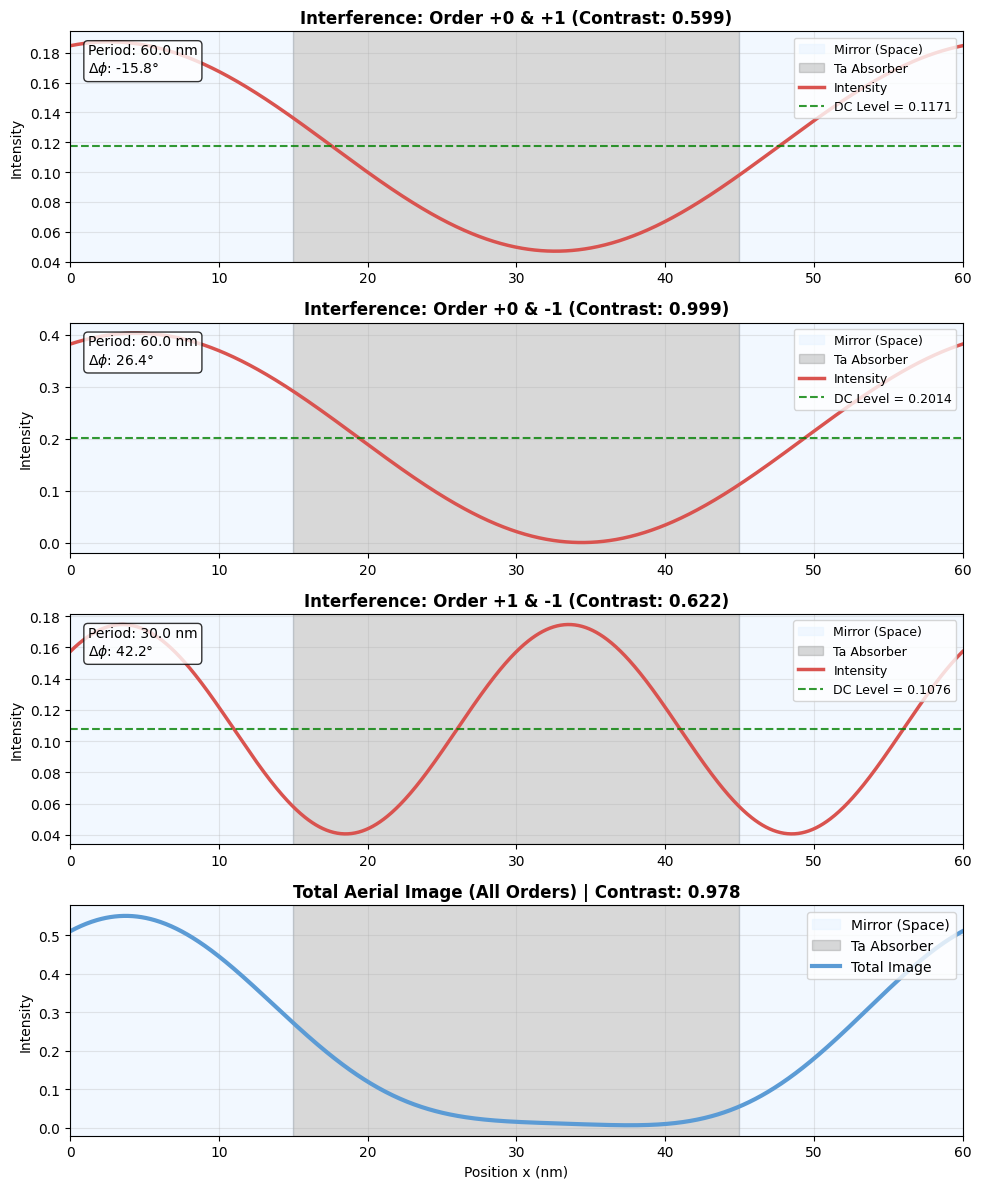


總結: EUV 光罩模擬 (Total Reflectance)
總光強最大值: 0.5504
總光強最小值: 0.0061
成像對比度 (NILS proxy): 0.9781

Generating 2D Visualization for Total & Pairwise Intensities


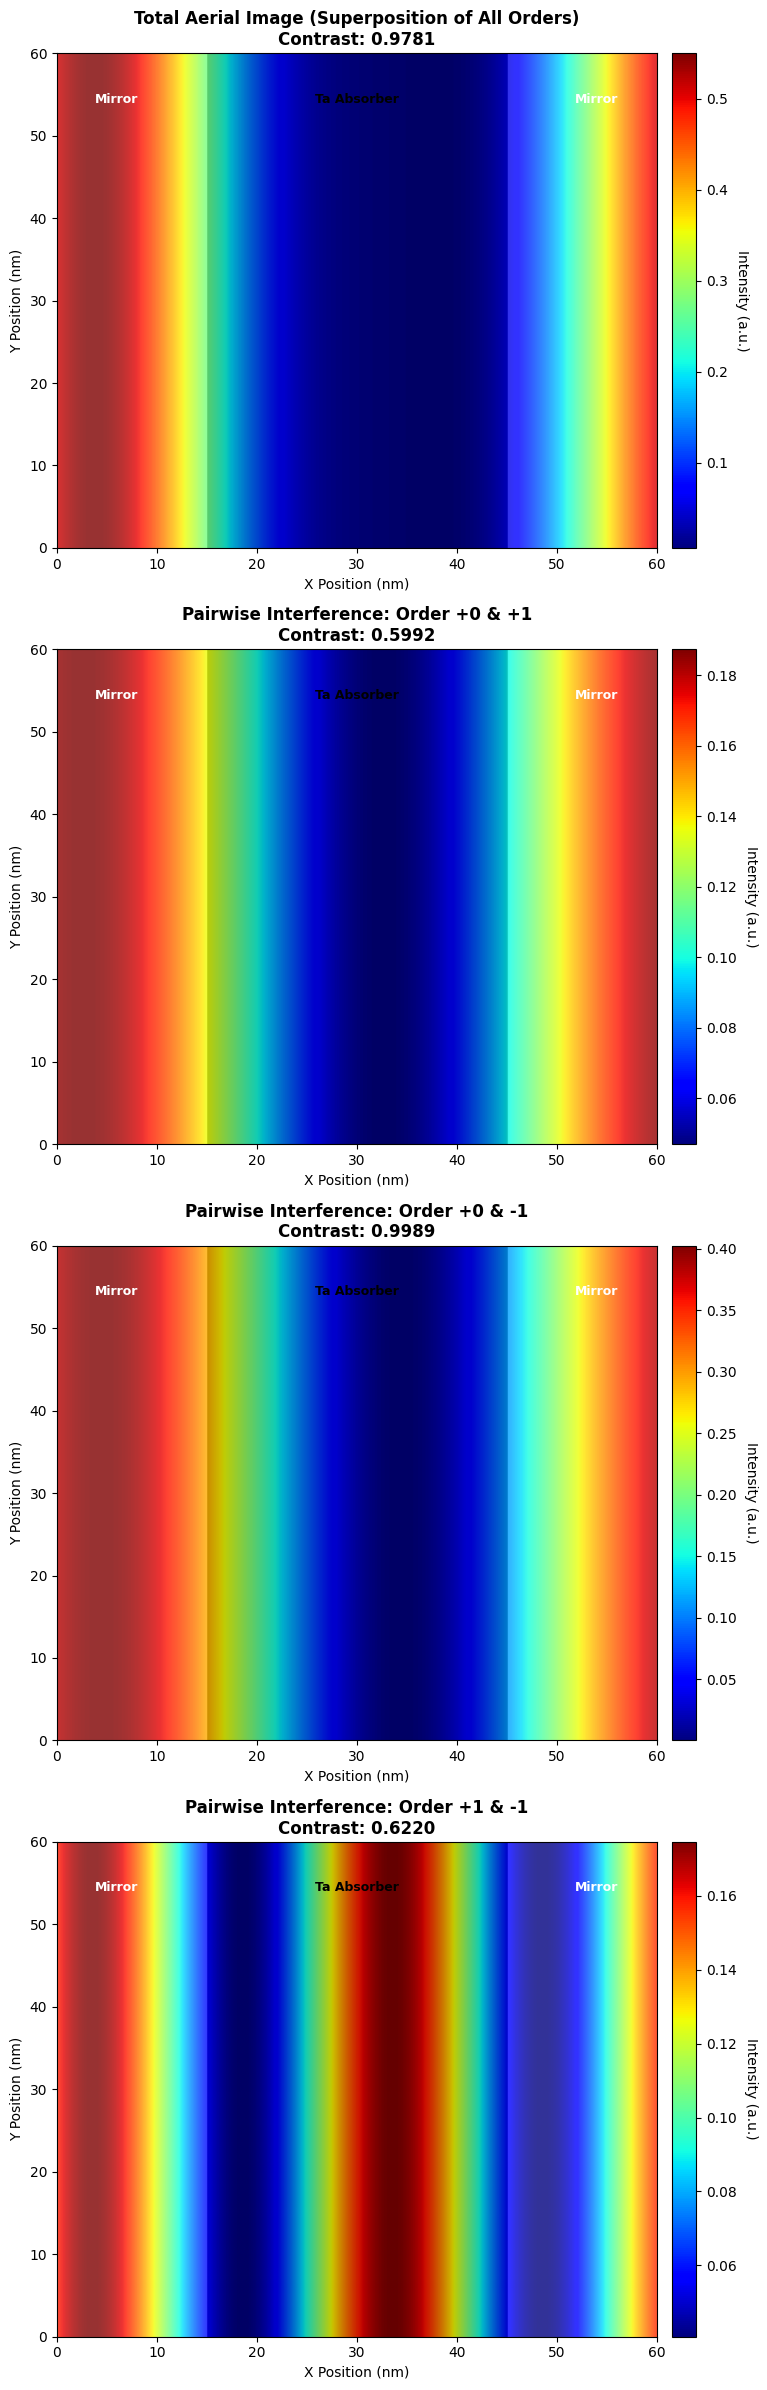


執行 NILS 分析 (全域分布 + 材質交界處定點偵測)
目標線寬 (CD): 30.0 nm
----------------------------------------
觀測位置 (nm)       | NILS 數值        
----------------------------------------
x = 15.02        | 3.9048
x = 44.98        | 9.0424
----------------------------------------
邊緣平均 NILS : 6.4736


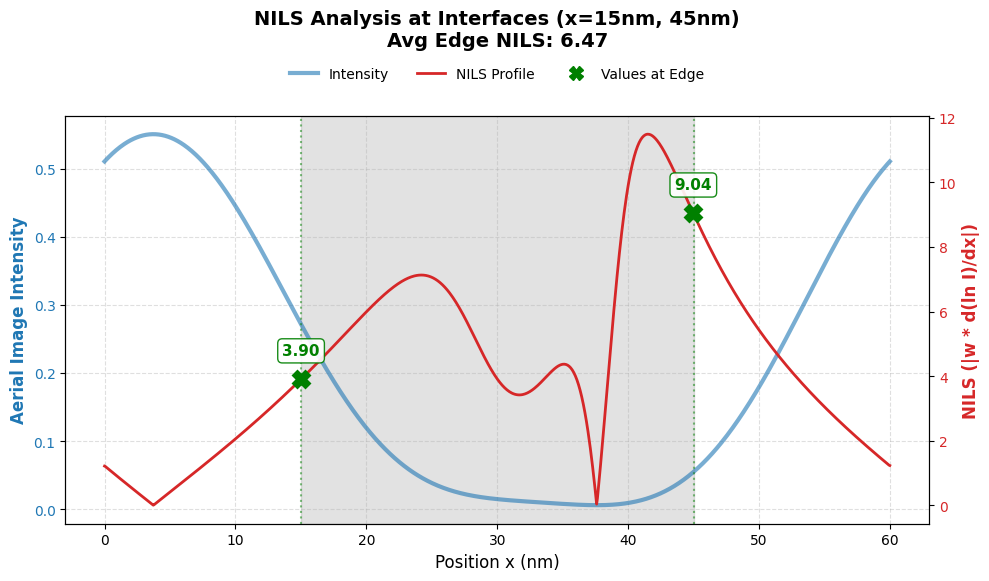

In [1]:
'''
EUV 光罩干涉計算器 (EUV Mask Interference Calculator)
整合 torcwa 模擬與雙光束干涉分析
波長: 13.5nm | 入射角: 6度 | 週期: 60nm
結構: Ta Absorber on Mo/Si Multilayer Mirror
'''

# ==================== 0. 匯入與基礎設定 ====================
import numpy as np
import torch
import matplotlib.pyplot as plt
import torcwa
from itertools import combinations

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype_c = torch.complex128
dtype_r = torch.float64

# ==================== 1. 使用者輸入 (User Input) ====================
ORDER_LIST = [0, 1, -1] 

# ==================== 2. EUV 環境參數設定 ====================
wavelength = 13.5   # nm
lattice_constant = 60.0  # nm
theta = 6.0    # 入射角度 (deg)
phi = 0.0      # 方位角 (deg)

inc_ang = theta * np.pi / 180
azi_ang = phi * np.pi / 180
freq = 1 / wavelength
L = [lattice_constant, lattice_constant]


multilayer_data = [
    {'n': 0.99932, 'k': 0.00183, 'thickness': 1.986416, 'delta': -0.00068},
    {'n': 0.9693, 'k': 0.004333, 'thickness': 2.5815, 'delta': -0.0307},
    {'n': 0.92108, 'k': 0.00644, 'thickness': 2.006752, 'delta': -0.07892},
    {'n': 0.9693, 'k': 0.00433, 'thickness': 0.473704, 'delta': -0.0307},
]

# 頂層結構與材料數據
mask_stack = {
    'substrate': {'n': 0.97646, 'k': 0.00906},
    'Si_top':    {'n': 0.99932, 'k': 0.00183, 'thickness': 4.17},
    'Ru_cap':    {'n': 0.88636, 'k': 0.01707, 'thickness': 2.50},
    'Ta_bulk':   {'n': 0.95100, 'k': 0.03210, 'thickness': 58.0},
    'Ta_ARC':    {'n': 0.95200, 'k': 0.02670, 'thickness': 2.00},
}

# ==================== 3. 建立 RCWA 模擬環境 ====================
print(f"正在建立 EUV 光罩模擬 (L={lattice_constant}nm, Theta={theta}deg)...")

torcwa.rcwa_geo.dtype = dtype_r
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800 
torcwa.rcwa_geo.ny = 50 
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.

# 模擬階數設定 (為了精度設高一點，例如 10，但只提取 ORDER_LIST 分析)
order_1D = [10, 0] 

sim = torcwa.rcwa(freq=freq, order=order_1D, L=L, dtype=dtype_c, device=device)

# --- A. 添加 Input/Output ---
sim.add_input_layer(eps=1.0) # 真空入射
n_sub = mask_stack['substrate']['n'] + 1j * mask_stack['substrate']['k']
sim.add_output_layer(eps=n_sub**2) # 基板
sim.set_incident_angle(inc_ang=inc_ang, azi_ang=azi_ang)

# --- B. 定義圖形 (Absorber Pattern) ---
absorber_pattern = torcwa.rcwa_geo.rectangle(
    Wx=L[0]/2, Wy=L[1], Cx=L[0]/2, Cy=L[1]/2
)

# --- C. 堆疊 Patterned Layers (Ta) ---
# Ta ARC
n_arc = mask_stack['Ta_ARC']['n'] + 1j * mask_stack['Ta_ARC']['k']
eps_Ta_ARC = absorber_pattern * (n_arc**2) + (1-absorber_pattern) * (1.0)
sim.add_layer(thickness=mask_stack['Ta_ARC']['thickness'], eps=eps_Ta_ARC)

# Ta Bulk
n_bulk = mask_stack['Ta_bulk']['n'] + 1j * mask_stack['Ta_bulk']['k']
eps_Ta_Bulk = absorber_pattern * (n_bulk**2) + (1-absorber_pattern) * (1.0)
sim.add_layer(thickness=mask_stack['Ta_bulk']['thickness'], eps=eps_Ta_Bulk)

# --- D. 堆疊 Uniform Layers (Mirror) ---
# Ru Cap
n_ru = mask_stack['Ru_cap']['n'] + 1j * mask_stack['Ru_cap']['k']
sim.add_layer(thickness=mask_stack['Ru_cap']['thickness'], eps=torch.tensor(n_ru**2, dtype=dtype_c, device=device))

# Si Top
n_si_top = mask_stack['Si_top']['n'] + 1j * mask_stack['Si_top']['k']
sim.add_layer(thickness=mask_stack['Si_top']['thickness'], eps=torch.tensor(n_si_top**2, dtype=dtype_c, device=device))

# Mo/Si Multilayer (40 pairs)
for cycle in range(40):
    # [修正 2026/09] 老師提供的參數為 deposit 格式（由基板往上定義），
    # 而 torcwa 的 add_layer() 是由入射面往下加層，因此多層膜單一週期內的子層順序需反轉。
    for layer in multilayer_data[::-1]:  # 週期內反轉
        n_val = layer['n'] + 1j * layer['k']
        sim.add_layer(thickness=layer['thickness'], eps=torch.tensor(n_val**2, dtype=dtype_c, device=device))

# ==================== 4. 執行計算 (RCWA Solving) ====================
print("開始求解 Maxwell 方程 (S-Matrix)...")
sim.solve_global_smatrix()

# ==================== 5. 提取 S 參數與干涉分析 ====================
print("\n" + "="*80)
print(f"提取反射光資訊 (Orders: {ORDER_LIST})")
print("="*80)
order_params = {}

for order in ORDER_LIST:
    S_param = sim.S_parameters(
        orders=[order, 0], 
        direction='forward', 
        port='reflection',      # EUV 是反射式光罩
        polarization='xx', 
        ref_order=[0,0]
    ).cpu().item()
    
    A = abs(S_param)
    phi = np.angle(S_param)
    R_eff = (A**2) * 100 # 反射率 %
    
    order_params[order] = {'S': S_param, 'A': A, 'phi': phi, 'R': R_eff}
    
    print(f"Order {order:+2d}: Reflectance={R_eff:6.2f}%, Amp={A:.4f}, Phase={np.degrees(phi):+7.2f}°")

# ==================== 6. 計算兩兩干涉圖形 ====================
print("\n" + "="*80)
print("計算空間干涉圖形 (Spatial Interference Patterns)")
print("="*80)

x = np.linspace(0, lattice_constant, 1000) #在一個光柵週期內，切出 1000 個取樣點
interference_patterns = {}
pair_list = list(combinations(ORDER_LIST, 2)) #使用 itertools.combinations 從ORDER_LIST中取出所有可能的「兩兩配對」

for n, m in pair_list:
    A_n = order_params[n]['A']
    A_m = order_params[m]['A']
    phi_n = order_params[n]['phi']
    phi_m = order_params[m]['phi']
    
    # 公式: I_nm = |E_n + E_m|^2 = An^2 + Am^2 + 2AnAm*cos( (km-kn)x + (pm-pn) )
    DC_term = A_n**2 + A_m**2
    AC_coeff = 2 * A_n * A_m
    # 空間頻率 k = m * 2pi / Period
    spatial_freq = (m - n) * 2 * np.pi / lattice_constant
    phase_diff = phi_m - phi_n
    
    I_nm = DC_term + AC_coeff * np.cos(spatial_freq * x + phase_diff)
    
    contrast = (np.max(I_nm) - np.min(I_nm)) / (np.max(I_nm) + np.min(I_nm) + 1e-10) # 避免除以零
    
    interference_patterns[(n, m)] = {
        'intensity': I_nm,
        'DC': DC_term,
        'AC_coeff': AC_coeff,
        'phase_diff': phase_diff,
        'contrast': contrast
    }
    print(f"Pair {n:+d} & {m:+d}: Contrast={contrast:.4f}")

# ==================== 7. 計算總疊加強度 (Total Intensity) ====================
E_total = np.zeros_like(x, dtype=complex)
for order in ORDER_LIST:
    A = order_params[order]['A']
    phi = order_params[order]['phi']
    k = order * 2 * np.pi / lattice_constant
    # 注意: 這裡 x 是空間位置
    E_total += A * np.exp(1j * (k * x + phi))

I_total = np.abs(E_total)**2
total_contrast = (np.max(I_total) - np.min(I_total)) / (np.max(I_total) + np.min(I_total))

# ==================== 8. 視覺化繪圖 (Visualization) ====================
num_pairs = len(pair_list)
fig, axes = plt.subplots(num_pairs + 1, 1, figsize=(10, 3*(num_pairs+1)))

if num_pairs == 0: axes = [axes]
else: axes = axes.flatten()

# 定義 Absorber 區域 (用於繪製背景)
abs_start = lattice_constant * 0.25
abs_end = lattice_constant * 0.75

def draw_mask_background(ax):
    """繪製光罩結構背景: 灰色=吸收體, 藍色=反射鏡"""
    ax.axvspan(0, abs_start, color='#E6F3FF', alpha=0.5, label='Mirror (Space)')
    ax.axvspan(abs_end, lattice_constant, color='#E6F3FF', alpha=0.5)
    ax.axvspan(abs_start, abs_end, color='#404040', alpha=0.2, label='Ta Absorber')

# 繪製每一對干涉
for idx, (n, m) in enumerate(pair_list):
    ax = axes[idx]
    pattern = interference_patterns[(n, m)]
    
    draw_mask_background(ax)
    
    ax.plot(x, pattern['intensity'], color='#D9534F', linewidth=2.5, label='Intensity')
    
    # [新增功能] 繪製 DC Level (平均強度) 
    ax.axhline(y=pattern['DC'], color='green', linestyle='--', alpha=0.8, 
               label=f'DC Level = {pattern["DC"]:.4f}')
    
    ax.set_title(f'Interference: Order {n:+d} & {m:+d} (Contrast: {pattern["contrast"]:.3f})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Intensity', fontsize=10)
    ax.set_xlim(0, lattice_constant)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # 標示公式參數
    info_text = f"Period: {lattice_constant/(abs(m-n)):.1f} nm\n$\Delta\phi$: {np.degrees(pattern['phase_diff']):.1f}°"
    ax.text(0.02, 0.95, info_text, transform=ax.transAxes, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 繪製總疊加
ax_total = axes[-1]
draw_mask_background(ax_total)
ax_total.plot(x, I_total, color='#5B9BD5', linewidth=3, label='Total Image')
ax_total.set_title(f'Total Aerial Image (All Orders) | Contrast: {total_contrast:.3f}', fontsize=12, fontweight='bold')
ax_total.set_xlabel('Position x (nm)', fontsize=10)
ax_total.set_ylabel('Intensity', fontsize=10)
ax_total.set_xlim(0, lattice_constant)
ax_total.legend(loc='upper right', frameon=True)
ax_total.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== 9. 統計輸出 ====================
print("\n" + "="*80)
print(f"總結: EUV 光罩模擬 (Total Reflectance)")
print("="*80)
print(f"總光強最大值: {np.max(I_total):.4f}")
print(f"總光強最小值: {np.min(I_total):.4f}")
print(f"成像對比度 (NILS proxy): {total_contrast:.4f}")
print("="*80)

# ==================== 10. [新增功能] 完整 2D 強度分佈視覺化 (總和 + 分項) ====================
print("\n" + "="*80)
print("Generating 2D Visualization for Total & Pairwise Intensities")
print("="*80)

# 1. 視覺化設定
cmap_choice = 'jet' 

# 準備 Y 軸數據 (用於 meshgrid，這裡直接用 tile 處理)
# 假設 Y 方向長度與 X 方向相同 (為了繪圖比例 1:1)
y_vals = np.linspace(0, lattice_constant, 1000)

# 定義 Absorber 遮罩 (用於標示結構位置)
# 建立一個全零矩陣
mask_overlay_base = np.zeros((1000, 1000))
# 找出 X 軸上屬於 Ta Absorber 的索引範圍
x_indices = np.where((x >= abs_start) & (x <= abs_end))[0]
# 將 Absorber 區域設為 1
mask_overlay_base[:, x_indices] = 1.0

# 2. 建立畫布
# 我們需要畫 (配對數量 + 1張總圖)
num_plots = len(pair_list) + 1
fig_2d, axes_2d = plt.subplots(num_plots, 1, figsize=(8, 6 * num_plots))

if num_plots == 1:
    axes_2d = [axes_2d]

# 定義一個通用的繪圖函數，避免重複寫程式碼
def plot_2d_heatmap(ax, intensity_1d, title_text, contrast_val):
    # A. 數據 2D 化: 將 1D 數據沿 Y 軸複製拉伸
    I_2D = np.tile(intensity_1d, (1000, 1))
    
    # B. 繪製熱圖
    im = ax.imshow(I_2D, 
                   extent=[0, lattice_constant, 0, lattice_constant], 
                   origin='lower', 
                   cmap=cmap_choice, 
                   aspect='auto')
    
    # C. 疊加結構遮罩 (半透明灰色)
    ax.imshow(mask_overlay_base, 
              extent=[0, lattice_constant, 0, lattice_constant], 
              origin='lower', 
              cmap='binary', 
              alpha=0.2, # 透明度
              aspect='auto')
    
    # D. 標示與美化
    ax.set_title(f'{title_text}\nContrast: {contrast_val:.4f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y Position (nm)', fontsize=10)
    ax.set_xlabel('X Position (nm)', fontsize=10)
    
    # 標示結構文字
    text_y_pos = lattice_constant * 0.9
    ax.text(lattice_constant*0.1, text_y_pos, "Mirror", color='white', ha='center', fontsize=9, fontweight='bold')
    ax.text(lattice_constant*0.5, text_y_pos, "Ta Absorber", color='black', ha='center', fontsize=9, fontweight='bold')
    ax.text(lattice_constant*0.9, text_y_pos, "Mirror", color='white', ha='center', fontsize=9, fontweight='bold')

    # 加入色條
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label('Intensity (a.u.)', rotation=270, labelpad=15)

# 3. 繪製 [總疊加強度] (放在第一張)
ax_total = axes_2d[0]
plot_2d_heatmap(ax_total, I_total, "Total Aerial Image (Superposition of All Orders)", total_contrast)

# 4. 繪製 [每一對干涉]
for idx, (n, m) in enumerate(pair_list):
    # 因為總圖佔了第 0 個位置，所以配對圖從 idx + 1 開始
    ax = axes_2d[idx + 1]
    pattern = interference_patterns[(n, m)]
    
    title = f"Pairwise Interference: Order {n:+d} & {m:+d}"
    plot_2d_heatmap(ax, pattern['intensity'], title, pattern['contrast'])

plt.tight_layout()
plt.show()

# ==================== 11. [功能升級] NILS 全域分布與交界處定點分析 ====================
print("\n" + "="*80)
print("執行 NILS 分析 (全域分布 + 材質交界處定點偵測)")
print("="*80)

def calculate_nils_integrated(position, intensity, nominal_width):
    """
    計算 NILS: Normalized Image Log-Slope
    Formula: NILS = w * (1/I) * (dI/dx)
    """
    # 1. 計算光強度的微分 (dI/dx)
    dI_dx = np.gradient(intensity, position)
    
    # 2. 計算 NILS (避免除以 0)
    with np.errstate(divide='ignore', invalid='ignore'):
        log_slope = dI_dx / intensity
        nils_profile = nominal_width * log_slope
        
    # 處理數值異常 (Inf/NaN) - 將無效值補 0
    nils_profile = np.nan_to_num(nils_profile, nan=0.0, posinf=0.0, neginf=0.0)
    return nils_profile

# --- A. 參數設定 ---
# 根據題目設定: Period=60nm, Absorber 佔一半 => CD = 30nm
target_cd = 30.0 

# 設定您要觀測的材質交界處 (Edge Locations)
edge_locs = [15.0, 45.0]  # nm

# --- B. 執行全域計算 ---
# 利用上文生成的 x 和 I_total
nils_values = calculate_nils_integrated(x, I_total, target_cd)
abs_nils = np.abs(nils_values) # 取絕對值方便觀察陡峭度

# --- C. 定點提取 (Extraction at Edges) ---
# 找出 x 陣列中最接近 15nm 和 45nm 的索引位置
edge_indices = []
edge_nils_vals = []

print(f"目標線寬 (CD): {target_cd} nm")
print("-" * 40)
print(f"{'觀測位置 (nm)':<15} | {'NILS 數值':<15}")
print("-" * 40)

for loc in edge_locs:
    # 尋找最接近 loc 的索引值
    idx = (np.abs(x - loc)).argmin()
    val = abs_nils[idx]
    
    edge_indices.append(idx)
    edge_nils_vals.append(val)
    print(f"x = {x[idx]:.2f}        | {val:.4f}")

# 計算這兩個邊緣的平均 NILS 作為該圖形的品質指標
avg_edge_nils = np.mean(edge_nils_vals)
print("-" * 40)
print(f"邊緣平均 NILS : {avg_edge_nils:.4f}")

# --- D. 雙軸視覺化 (Intensity + NILS with Edge Markers) ---
fig_nils, ax1 = plt.subplots(figsize=(10, 6))

# 1. 繪製光強度 (左軸 - 藍色)
color_i = '#1f77b4' 
ax1.set_xlabel('Position x (nm)', fontsize=12)
ax1.set_ylabel('Aerial Image Intensity', color=color_i, fontsize=12, fontweight='bold')
line1 = ax1.plot(x, I_total, color=color_i, linewidth=3, label='Intensity', alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color_i)
ax1.grid(True, linestyle='--', alpha=0.4)

# 繪製 Absorber 區域背景 (15nm ~ 45nm)
ax1.axvspan(15, 45, color='#404040', alpha=0.15, label='Ta Absorber Region')

# 2. 繪製 NILS 全域分布 (右軸 - 紅色)
ax2 = ax1.twinx()
color_n = '#d62728'
ax2.set_ylabel('NILS (|w * d(ln I)/dx|)', color=color_n, fontsize=12, fontweight='bold')
line2 = ax2.plot(x, abs_nils, color=color_n, linewidth=2, linestyle='-', label='NILS Profile')
ax2.tick_params(axis='y', labelcolor=color_n)

# 3. 標示材質交界處的數值 (重點功能)
for i, loc in enumerate(edge_locs):
    val = edge_nils_vals[i]
    real_x = x[edge_indices[i]]
    
    # 畫 "X" 標記
    ax2.plot(real_x, val, 'X', color='green', markersize=12, markeredgewidth=2, zorder=10, label='Edge NILS' if i==0 else "")
    
    # 加上文字標籤
    ax2.annotate(f'{val:.2f}', 
                 xy=(real_x, val), 
                 xytext=(0, 15), textcoords='offset points',
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='green',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.9))

# 繪製虛線指示位置
ax2.axvline(x=15, color='green', linestyle=':', alpha=0.5)
ax2.axvline(x=45, color='green', linestyle=':', alpha=0.5)

# 4. 合併圖例
lines = line1 + line2 + [plt.Line2D([0], [0], color='green', marker='X', linestyle='None', markersize=10, label='Values at Edge')]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False)

plt.title(f'NILS Analysis at Interfaces (x=15nm, 45nm)\nAvg Edge NILS: {avg_edge_nils:.2f}', y=1.15, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

正在計算 NILS，目標線寬 (w) = 200...


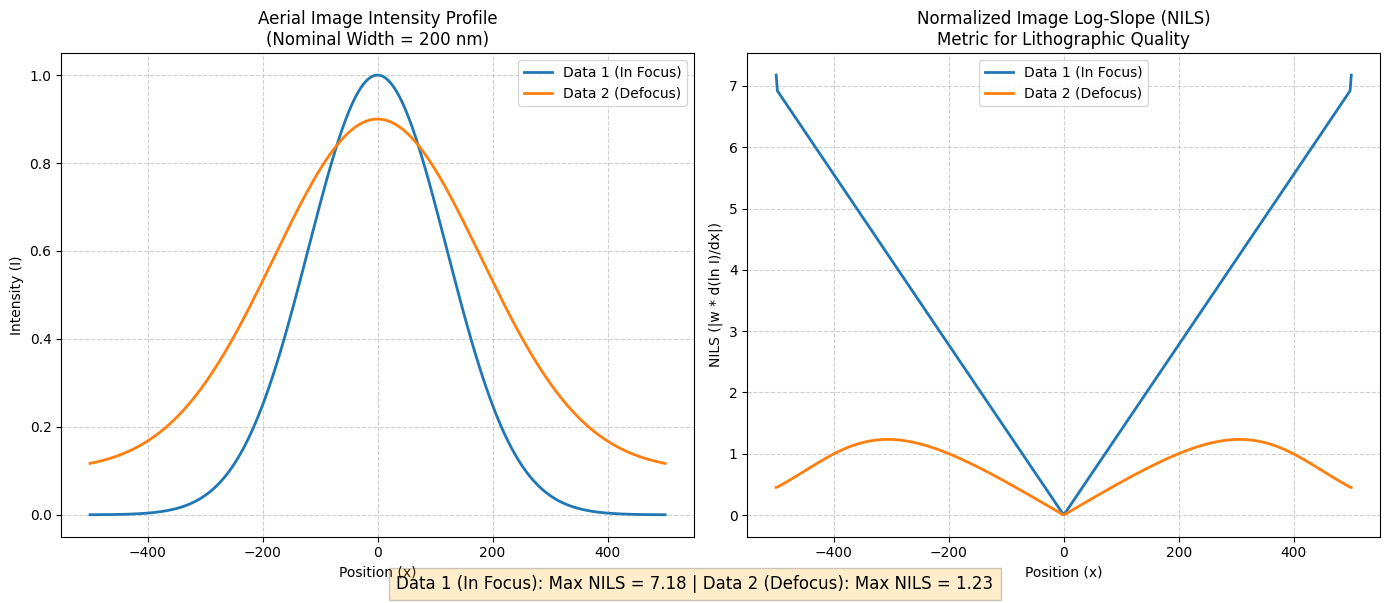

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_nils(position, intensity, nominal_width):
    """
    
    
    公式: NILS = w * (1/I) * (dI/dx)
   
    參數:
    position (array): 空間位置座標 (x)
    intensity (array): 對應的光強度分佈 (I)
    nominal_width (float): 標稱線寬 (w, feature size)
    
    回傳:
    nils_profile (array): 每個位置對應的 NILS 值
    """
    # 1. 計算光強度的微分 (dI/dx)
    # 使用 numpy.gradient 計算中心差分，適用於非均勻或均勻間距
    dI_dx = np.gradient(intensity, position)
    
    # 2. 計算 NILS
    # 為了避免除以 0 的錯誤，我們使用 np.errstate 忽略極小值的警告
    with np.errstate(divide='ignore', invalid='ignore'):
        # Log-Slope = (1/I) * (dI/dx)
        log_slope = dI_dx / intensity
        
        # NILS = w * Log-Slope
        nils_profile = nominal_width * log_slope
        
    # 處理可能產生的 inf 或 nan (當強度極低時)
    nils_profile = np.nan_to_num(nils_profile, nan=0.0, posinf=0.0, neginf=0.0)
    
    return nils_profile

def analyze_and_plot(data_sets, nominal_width):
    """
    分析並疊加繪製多組數據的強度與 NILS 分佈。
    
    參數:
    data_sets (list of dict): 包含數據的列表，格式為 [{'label': 'Name', 'x': array, 'I': array}, ...]
    nominal_width (float): 用於歸一化的線寬
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 用於紀錄最大 NILS 以便後續分析
    summary_text = []

    for data in data_sets:
        x = data['x']
        I = data['I']
        label = data['label']
        
        # 計算 NILS
        nils = calculate_nils(x, I, nominal_width)
        
        # 找出邊緣處的最大 NILS 值 (代表該條件下的成像品質)
        # 通常我們關心的是邊緣處(斜率最陡處)的絕對值峰值
        max_nils_idx = np.argmax(np.abs(nils))
        max_nils_val = np.abs(nils[max_nils_idx])
        summary_text.append(f"{label}: Max NILS = {max_nils_val:.2f}")

        # --- 繪圖區 ---
        
        # 1. 光強度分佈 (Aerial Image Intensity)
        ax1.plot(x, I, label=label, linewidth=2)
        
        # 2. NILS 分佈
        # 取絕對值是為了方便比較斜率陡峭程度，不論上升或下降緣
        ax2.plot(x, np.abs(nils), label=label, linewidth=2)

    # 設定圖表 1: 光強度
    ax1.set_title(f'Aerial Image Intensity Profile\n(Nominal Width = {nominal_width} nm)')
    ax1.set_xlabel('Position (x)')
    ax1.set_ylabel('Intensity (I)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 設定圖表 2: NILS
    ax2.set_title('Normalized Image Log-Slope (NILS)\nMetric for Lithographic Quality')
    ax2.set_xlabel('Position (x)')
    ax2.set_ylabel('NILS (|w * d(ln I)/dx|)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    # 在圖上標示 NILS 峰值比較
    plt.figtext(0.5, 0.01, " | ".join(summary_text), ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

    plt.tight_layout()
    plt.show()

# ==========================================
# 模擬數據生成 (使用者若有真實數據，請替換此處)
# ==========================================

# 模擬參數 (假設線寬 200nm)
w_target = 200 
x = np.linspace(-500, 500, 500)

# 產生模擬的光強度分佈 (使用高斯函數模擬 Figure 3 的效果)
# 數據 1: In Focus (較陡峭，標準差小)
sigma1 = 120
I_focus = np.exp(-0.5 * (x / sigma1)**2)

# 數據 2: Defocus (較模糊，標準差大，峰值較低)
sigma2 = 180
I_defocus = 0.8 * np.exp(-0.5 * (x / sigma2)**2) + 0.1 # 加上底噪模擬真實情況

# 準備傳入分析模組的數據結構
data_input = [
    {'label': 'Data 1 (In Focus)', 'x': x, 'I': I_focus},
    {'label': 'Data 2 (Defocus)', 'x': x, 'I': I_defocus}
]

# 執行分析
print(f"正在計算 NILS，目標線寬 (w) = {w_target}...")
analyze_and_plot(data_input, w_target)

正在建立 EUV 光罩模擬 (L=60.0nm, Theta=6.0deg)...



開始執行雙極照明 (Dipole Illumination) 模擬

正在計算: Pole 1 (+10.9 deg)
 - 設定入射角: 10.9 度
 - 收集階數: [0, -1, -2]


   Order +0: Amp=0.2049, Phase=+146.45°
   Order -1: Amp=0.2222, Phase=-105.72°
   Order -2: Amp=0.1078, Phase= -61.39°

正在計算: Pole 2 (-10.9 deg)
 - 設定入射角: -10.9 度
 - 收集階數: [0, 1, 2]


   Order +0: Amp=0.2049, Phase=+146.45°
   Order +1: Amp=0.2222, Phase=-105.27°
   Order +2: Amp=0.1078, Phase= -60.49°

執行影像疊加 (Superposition)
Pole 1 Max Intensity: 0.2663
Pole 2 Max Intensity: 0.2663
疊加後 Max Intensity: 0.2847
疊加後成像對比度  : 0.4220

執行 NILS 分析 (Target: Superposed Image)
觀測位置 (nm)       | NILS 數值        
----------------------------------------
x = 15.02        | 0.1496
x = 44.98        | 0.1224
----------------------------------------
邊緣平均 NILS : 0.1360


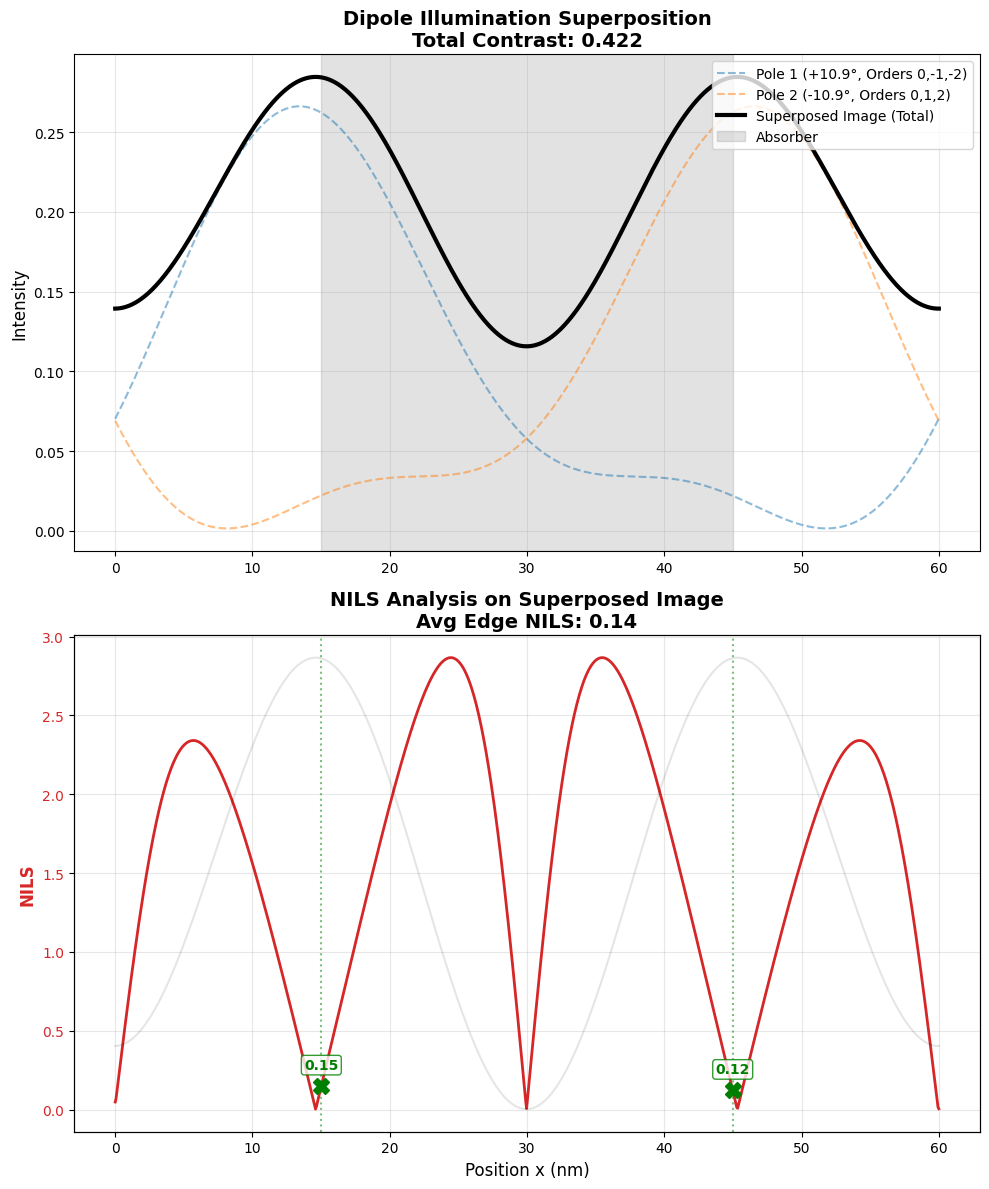

In [ ]:
'''
EUV 光罩干涉計算器 (EUV Mask Interference Calculator)
波長: 13.5nm | 週期: 60nm
結構: Ta Absorber on Mo/Si Multilayer Mirror
'''

# ==================== 0. 匯入與基礎設定 ====================
import numpy as np
import torch
import matplotlib.pyplot as plt
import torcwa
from itertools import combinations

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype_c = torch.complex128
dtype_r = torch.float64

# ==================== 1. 使用者輸入 (User Input) ====================
ORDER_LIST = [0, 1, -1] 

# ==================== 2. EUV 環境參數設定 ====================
wavelength = 13.5   # nm
lattice_constant = 60.0  # nm
theta = 6.0    # 入射角度 (deg)
phi = 0.0      # 方位角 (deg)

inc_ang = theta * np.pi / 180
azi_ang = phi * np.pi / 180
freq = 1 / wavelength
L = [lattice_constant, lattice_constant]


multilayer_data = [
    {'n': 0.99932, 'k': 0.00183, 'thickness': 1.986416, 'delta': -0.00068},
    {'n': 0.9693, 'k': 0.004333, 'thickness': 2.5815, 'delta': -0.0307},
    {'n': 0.92108, 'k': 0.00644, 'thickness': 2.006752, 'delta': -0.07892},
    {'n': 0.9693, 'k': 0.00433, 'thickness': 0.473704, 'delta': -0.0307},
]

# 頂層結構與材料數據
mask_stack = {
    'substrate': {'n': 0.97646, 'k': 0.00906},
    'Si_top':    {'n': 0.99932, 'k': 0.00183, 'thickness': 4.17},
    'Ru_cap':    {'n': 0.88636, 'k': 0.01707, 'thickness': 2.50},
    'Ta_bulk':   {'n': 0.95100, 'k': 0.03210, 'thickness': 58.0},
    'Ta_ARC':    {'n': 0.95200, 'k': 0.02670, 'thickness': 2.00},
}

# ==================== 3. 建立 RCWA 模擬環境 ====================
print(f"正在建立 EUV 光罩模擬 (L={lattice_constant}nm, Theta={theta}deg)...")

torcwa.rcwa_geo.dtype = dtype_r
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 800 
torcwa.rcwa_geo.ny = 50 
torcwa.rcwa_geo.grid()
torcwa.rcwa_geo.edge_sharpness = 1000.

# 模擬階數設定 
order_1D = [10, 0] 

# [修正 2026/09] torcwa 在 add_layer() 當下即以當時的入射角求解各層，
# 因此改變入射角時必須重新建立整個模擬物件（原寫法在建層後才重設角度，會沿用 6° 的解）。
def build_mask_sim(theta_deg):
    sim = torcwa.rcwa(freq=freq, order=order_1D, L=L, dtype=dtype_c, device=device)

    # --- A. 添加 Input/Output ---
    sim.add_input_layer(eps=1.0) # 真空入射
    n_sub = mask_stack['substrate']['n'] + 1j * mask_stack['substrate']['k']
    sim.add_output_layer(eps=n_sub**2) # 基板
    sim.set_incident_angle(inc_ang=theta_deg * np.pi / 180, azi_ang=azi_ang)  # 入射角必須在 add_layer() 之前設定

    # --- B. 定義圖形 (Absorber Pattern) ---
    absorber_pattern = torcwa.rcwa_geo.rectangle(
        Wx=L[0]/2, Wy=L[1], Cx=L[0]/2, Cy=L[1]/2
    )

    # --- C. 堆疊 Patterned Layers (Ta) ---
    # Ta ARC
    n_arc = mask_stack['Ta_ARC']['n'] + 1j * mask_stack['Ta_ARC']['k']
    eps_Ta_ARC = absorber_pattern * (n_arc**2) + (1-absorber_pattern) * (1.0)
    sim.add_layer(thickness=mask_stack['Ta_ARC']['thickness'], eps=eps_Ta_ARC)

    # Ta Bulk
    n_bulk = mask_stack['Ta_bulk']['n'] + 1j * mask_stack['Ta_bulk']['k']
    eps_Ta_Bulk = absorber_pattern * (n_bulk**2) + (1-absorber_pattern) * (1.0)
    sim.add_layer(thickness=mask_stack['Ta_bulk']['thickness'], eps=eps_Ta_Bulk)

    # --- D. 堆疊 Uniform Layers (Mirror) ---
    # Ru Cap
    n_ru = mask_stack['Ru_cap']['n'] + 1j * mask_stack['Ru_cap']['k']
    sim.add_layer(thickness=mask_stack['Ru_cap']['thickness'], eps=torch.tensor(n_ru**2, dtype=dtype_c, device=device))

    # Si Top
    n_si_top = mask_stack['Si_top']['n'] + 1j * mask_stack['Si_top']['k']
    sim.add_layer(thickness=mask_stack['Si_top']['thickness'], eps=torch.tensor(n_si_top**2, dtype=dtype_c, device=device))

    # Mo/Si Multilayer (40 pairs)
    for cycle in range(40):
        for layer in multilayer_data[::-1]:  # 週期內反轉（deposit 由下往上 → torcwa 由上往下）
            n_val = layer['n'] + 1j * layer['k']
            sim.add_layer(thickness=layer['thickness'], eps=torch.tensor(n_val**2, dtype=dtype_c, device=device))
    return sim

sim = build_mask_sim(theta)

# ==================== 4. 雙極照明模擬與數據採集 ====================
print("\n" + "="*80)
print("開始執行雙極照明 (Dipole Illumination) 模擬")
print("="*80)

# 定義兩組模擬條件
# 格式: {'theta': 入射角, 'orders': [要收集的繞射階數]}
simulation_cases = [
    {'label': 'Pole 1 (+10.9 deg)', 'theta': 10.9,  'orders': [0, -1, -2]},
    {'label': 'Pole 2 (-10.9 deg)', 'theta': -10.9, 'orders': [0, 1, 2]}
]

# 準備空間座標 x 
x = np.linspace(0, lattice_constant, 1000)
intensities = {} # 儲存個別 case 的強度分布

for case in simulation_cases:
    print(f"\n正在計算: {case['label']}")
    print(f" - 設定入射角: {case['theta']} 度")
    print(f" - 收集階數: {case['orders']}")
    
    # A. 更新入射角並重新求解 Maxwell 方程
    current_inc_ang = case['theta'] * np.pi / 180
    sim = build_mask_sim(case['theta'])  # [修正] 每個照明極重新建模
    sim.solve_global_smatrix()
    
    # B. 重建該角度下的空間電場 (Electric Field Reconstruction)
    E_case = np.zeros_like(x, dtype=complex)
    
    # 針對指定的階數進行合成
    for order in case['orders']:
        # 提取 S 參數 (反射)
        S_param = sim.S_parameters(
            orders=[order, 0], 
            direction='forward', 
            port='reflection', 
            polarization='xx', 
            ref_order=[0,0]
        ).cpu().item()
        
        A = abs(S_param)
        phi = np.angle(S_param)
        
        # 空間頻率 k = order * 2pi / Period
        k_grating = order * 2 * np.pi / lattice_constant
        E_case += A * np.exp(1j * (k_grating * x + phi))
        
        print(f"   Order {order:+2d}: Amp={A:.4f}, Phase={np.degrees(phi):+7.2f}°")
        
    # C. 計算該 Case 的強度 (Intensity = |E|^2)
    intensities[case['label']] = np.abs(E_case)**2

# ==================== 5. 影像疊加 (Superposition) ====================
print("\n" + "="*80)
print("執行影像疊加 (Superposition)")
print("="*80)

# 將兩組強度相加 (非相干疊加)
I_pole1 = intensities['Pole 1 (+10.9 deg)']
I_pole2 = intensities['Pole 2 (-10.9 deg)']
I_total = I_pole1 + I_pole2

# 歸一化處理 (Optional，為了讓強度數值易讀，通常將最大值 Normalize 到 1)
# 但為了觀察絕對能量損耗，這裡我們保留原始數值，或是僅計算對比度
total_contrast = (np.max(I_total) - np.min(I_total)) / (np.max(I_total) + np.min(I_total))

print(f"Pole 1 Max Intensity: {np.max(I_pole1):.4f}")
print(f"Pole 2 Max Intensity: {np.max(I_pole2):.4f}")
print(f"疊加後 Max Intensity: {np.max(I_total):.4f}")
print(f"疊加後成像對比度  : {total_contrast:.4f}")

# ==================== 6. NILS 分析 (針對疊加後的影像) ====================
print("\n" + "="*80)
print("執行 NILS 分析 (Target: Superposed Image)")
print("="*80)

def calculate_nils_integrated(position, intensity, nominal_width):
    """ Formula: NILS = w * (1/I) * (dI/dx) """
    dI_dx = np.gradient(intensity, position)
    with np.errstate(divide='ignore', invalid='ignore'):
        log_slope = dI_dx / intensity
        nils_profile = nominal_width * log_slope
    return np.nan_to_num(nils_profile, nan=0.0, posinf=0.0, neginf=0.0)

# --- A. 參數設定 ---
target_cd = 30.0 
edge_locs = [15.0, 45.0] # 觀測位置: 材質交界處

# --- B. 計算 NILS ---
nils_values = calculate_nils_integrated(x, I_total, target_cd)
abs_nils = np.abs(nils_values)

# --- C. 提取交界處數值 ---
edge_indices = []
edge_nils_vals = []

print(f"{'觀測位置 (nm)':<15} | {'NILS 數值':<15}")
print("-" * 40)

for loc in edge_locs:
    idx = (np.abs(x - loc)).argmin() # 找最接近的索引
    val = abs_nils[idx]
    edge_indices.append(idx)
    edge_nils_vals.append(val)
    print(f"x = {x[idx]:.2f}        | {val:.4f}")

avg_edge_nils = np.mean(edge_nils_vals)
print("-" * 40)
print(f"邊緣平均 NILS : {avg_edge_nils:.4f}")

# ==================== 7. 最終視覺化 (Visualization) ====================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# --- 上圖: 強度疊加分析 ---
ax1.set_title(f'Dipole Illumination Superposition\nTotal Contrast: {total_contrast:.3f}', fontsize=14, fontweight='bold')
ax1.plot(x, I_pole1, '--', label='Pole 1 (+10.9°, Orders 0,-1,-2)', alpha=0.5, linewidth=1.5)
ax1.plot(x, I_pole2, '--', label='Pole 2 (-10.9°, Orders 0,1,2)', alpha=0.5, linewidth=1.5)
ax1.plot(x, I_total, 'k-', label='Superposed Image (Total)', linewidth=3) # 黑色粗線為總和

# 繪製結構背景
ax1.axvspan(15, 45, color='#404040', alpha=0.15, label='Absorber')
ax1.set_ylabel('Intensity', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- 下圖: NILS 分析 ---
color_nils = '#d62728'
ax2.set_title(f'NILS Analysis on Superposed Image\nAvg Edge NILS: {avg_edge_nils:.2f}', fontsize=14, fontweight='bold')
ax2.plot(x, abs_nils, color=color_nils, linewidth=2, label='NILS Profile')
ax2.set_ylabel('NILS', color=color_nils, fontsize=12, fontweight='bold')
ax2.set_xlabel('Position x (nm)', fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_nils)
ax2.grid(True, alpha=0.3)

# 標示交界處 NILS
for i, loc in enumerate(edge_locs):
    val = edge_nils_vals[i]
    real_x = x[edge_indices[i]]
    ax2.plot(real_x, val, 'X', color='green', markersize=12, zorder=10)
    ax2.annotate(f'{val:.2f}', xy=(real_x, val), xytext=(0, 10), textcoords='offset points',
                 ha='center', va='bottom', color='green', fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="green", alpha=0.8))

ax2.axvline(x=15, color='green', linestyle=':', alpha=0.5)
ax2.axvline(x=45, color='green', linestyle=':', alpha=0.5)

# 雙軸: 為了對照，在 NILS 圖上也淡淡地畫出強度
ax2_twin = ax2.twinx()
ax2_twin.plot(x, I_total, 'k-', alpha=0.1) # 極淡的黑色
ax2_twin.set_yticks([]) # 不顯示刻度，僅供參考位置

plt.tight_layout()
plt.show()